# NEURAL NETWORKS AND DEEP LEARNING

---
A.A. 2021/22 (6 CFU) - Dr. Alberto Testolin, Dr. Umberto Michieli
---


# Homework 1 - Supervised Deep Learning

## General overview
In this homework you will learn how to implement and test simple neural network models for solving supervised problems. It is divided in two tasks.

* **Regression task**: 
the regression model will consist in a simple function approximation problem, similar to the one discussed during the Lab practices. 

* **Classification task**: 
the classification model will consist in a simple image recognition problem, where the goal is to correctly classify images of Zalando's article images (Fashion MNIST). 

In both cases, but especially for the classification problem, you should explore the use of advanced optimizers and regularization methods (e.g., initialization scheme, momentum, ADAM, early stopping, L2, L1 / sparsity, dropout…) to improve convergence of stochastic gradient descent and promote generalization. Learning hyperparameters should be tuned using appropriate search procedures, and final accuracy should be evaluated using a cross-validation setup. For the image classification task, you can also implement more advanced convolutional architectures and explore feature visualization techniques to better understand how the deep network is encoding information at different processing layers.



## Technical notes
The homework should be implemented in Python using the PyTorch framework. The student can explore additional libraries and tools to implement the models; however, please make sure you understand the code you are writing because during the exam you might receive specific questions related to your implementation. The entire source code required to run the homework must be uploaded as a compressed archive in a Moodle section dedicated to the homework.If your code will be entirely included in a single Python notebook, just upload the notebook file.




## Final report
Along with the source code, you must separately upload a PDF file containing a brief report of your homework. The report should include a brief Introduction on which you explain the homework goals and the main implementation strategies you choose, a brief Method section where you describe your model architectures and hyperparameters, and a Result section where you present the simulation results. Total length should not exceed 6 pages, though you can include additional tables and figures in a final Appendix (optional). The report must be self-contained, so please make sure that all relevant results are explicitly included in the report / notebook.




## Grade
The maximum grade for this homework will be **8 points**. Points will be assigned based on the correct implementation of the following items:
*	2 pt: implement basic regression and classification tasks
*	2 pt: explore advanced optimizers and regularization methods (both tasks)
*	1 pt: optimize hyperparameters using grid/random search and cross-validation (both tasks)
*	2 pt: implement CNN for classification task
*	1 pt: visualize weight histograms, activation profiles and receptive fields



## Deadline
The complete homework (notebook or source code + report) must be submitted through Moodle at least 10 days before the chosen exam date.


# Regression task

## Guidelines

* The goal is to train a neural network to approximate an unknown function:
$$ 
f:\mathbb{R}→\mathbb{R} \\
x↦y=f(x) \\
\text{network}(x) \approx f(x)
$$
* As training point, you only have noisy measures from the target function.
$$
\hat{y} = f(x) + noise
$$
* Consider to create a validation set from you training data, or use a k-fold cross-validation strategy. You may find useful these functions from the `scikit-learn` library:
    - [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
    - [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold) 

# Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

The following cell of code will download the dataset and make it available in the local folder `regression_dataset`. There are two files:

* `regression_dataset/train_data.csv`
* `regression_dataset/test_data.csv`

Use them to train and test your model. Each row contains two values, respactively the input and the target (label).

In [ ]:
!wget -P regression_dataset https://gitlab.dei.unipd.it/michieli/nnld-2021-22-lab-resources/-/raw/main/homework1/train_data.csv
!wget -P regression_dataset https://gitlab.dei.unipd.it/michieli/nnld-2021-22-lab-resources/-/raw/main/homework1/test_data.csv 

--2021-12-31 17:05:33--  https://gitlab.dei.unipd.it/michieli/nnld-2021-22-lab-resources/-/raw/main/homework1/train_data.csv
Resolving gitlab.dei.unipd.it (gitlab.dei.unipd.it)... 147.162.2.85
Connecting to gitlab.dei.unipd.it (gitlab.dei.unipd.it)|147.162.2.85|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3776 (3.7K) [text/plain]
Saving to: ‘regression_dataset/train_data.csv’

train_data.csv      100%[===================>]   3.69K  --.-KB/s    in 0s      

2021-12-31 17:05:35 (81.9 MB/s) - ‘regression_dataset/train_data.csv’ saved [3776/3776]

--2021-12-31 17:05:35--  https://gitlab.dei.unipd.it/michieli/nnld-2021-22-lab-resources/-/raw/main/homework1/test_data.csv
Resolving gitlab.dei.unipd.it (gitlab.dei.unipd.it)... 147.162.2.85
Connecting to gitlab.dei.unipd.it (gitlab.dei.unipd.it)|147.162.2.85|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3788 (3.7K) [text/plain]
Saving to: ‘regression_dataset/test_data.csv’

test_data.csv 

How to load the data:

In [ ]:
train_df = pd.read_csv('regression_dataset/train_data.csv')
test_df = pd.read_csv('regression_dataset/test_data.csv')

How to get a specific sample:

In [ ]:
sample_index = 0
input = train_df.iloc[sample_index]['input']
label = train_df.iloc[sample_index]['label']

print(f"SAMPLE AT INDEX {sample_index}")
print(f"INPUT: {input}")
print(f"LABEL: {label}")

SAMPLE AT INDEX 0
INPUT: -4.787870188090535
LABEL: -1.216803599957529


All training points:

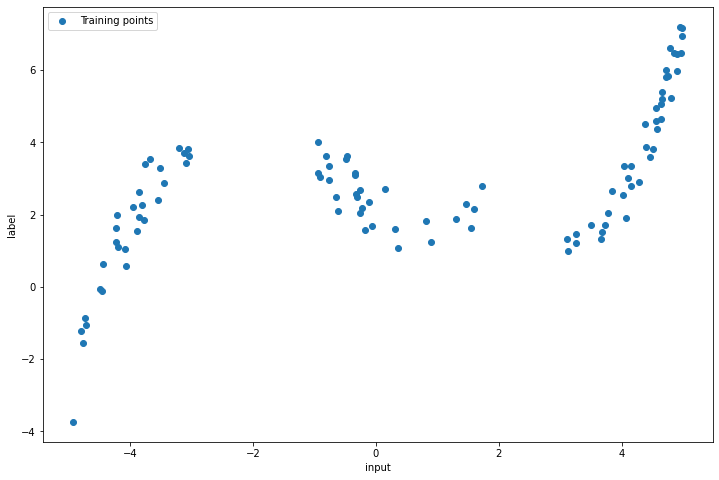

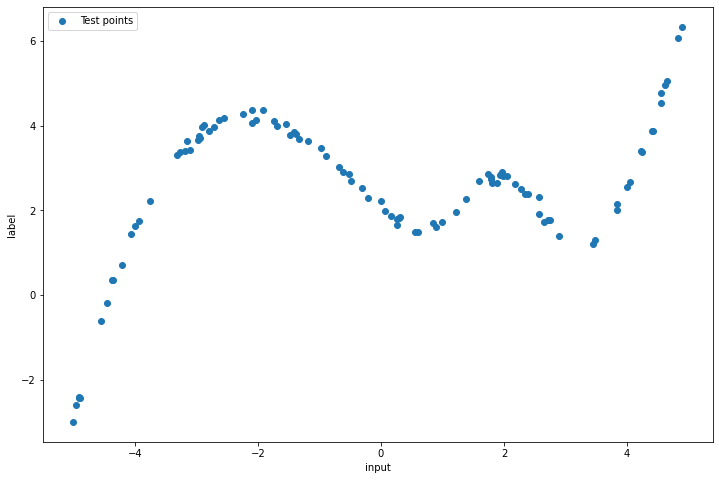

<class 'pandas.core.series.Series'>


In [ ]:
fig = plt.figure(figsize=(12,8))
plt.scatter(train_df.input, train_df.label, label='Training points')
plt.xlabel('input')
plt.ylabel('label')
plt.legend()
plt.show()

fig = plt.figure(figsize=(12,8))
plt.scatter(test_df.input, test_df.label, label='Test points')
plt.xlabel('input')
plt.ylabel('label')
plt.legend()
plt.show()

print(type(train_df.input))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

### Dataset and Dataloader

In [ ]:
class CsvDataset(Dataset):            #Datset class

    def __init__(self, csv_file, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.transform = transform
        # Read the file and split the lines in a list
        with open(csv_file, 'r') as f:
            lines = f.read().split('\n')
            lines = lines[1:]
        # Get x and y values from each line and append to self.data
        self.data = []
        for line in lines:
            if line != '' :
              sample = line.split(',')
              self.data.append((float(sample[0]), float(sample[1])))
        # Now self.data contains all our dataset.
        # Each element of the list self.data is a tuple: (input, output)

    def __len__(self):
        # The length of the dataset is simply the length of the self.data list
        return len(self.data)

    def __getitem__(self, idx):
        # Our sample is the element idx of the list self.data
        sample = self.data[idx]
        if self.transform:
            sample = self.transform(sample)
        return sample

In [ ]:
class ToTensor(object):
    """Convert sample to Tensors."""

    def __call__(self, sample):
        x, y = sample
        return (torch.tensor([x]).float(),
                torch.tensor([y]).float())

In [ ]:
composed_transform = transforms.Compose([ToTensor()])

train_dataset = CsvDataset('regression_dataset/train_data.csv', transform=composed_transform)
test_dataset = CsvDataset('regression_dataset/test_data.csv', transform=composed_transform)


In [ ]:
### Define train-val-test dataloader
train_dataloader = DataLoader(train_dataset, batch_size=int(len(train_dataset)/2), shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=int(len(test_dataset)/2), shuffle=False, num_workers=2)

print(f'Number of Train batches:{len(train_dataloader)}')
print(f'Number of Test batches:{len(test_dataloader)}')

Number of Train batches:2
Number of Test batches:2


In [ ]:
### Test if it works
# Train batch
image_batch, label_batch = next(iter(train_dataloader))  #we are asking the next sample to our iterator
print(f"\nTrain input batch shape: {image_batch.shape}")
print(f"Train label batch shape: {label_batch.shape}")

# Test batch
image_batch, label_batch = next(iter(test_dataloader))
print(f"\nTest input batch shape: {image_batch.shape}")
print(f"Test label batch shape: {label_batch.shape}")


Train input batch shape: torch.Size([50, 1])
Train label batch shape: torch.Size([50, 1])

Test input batch shape: torch.Size([50, 1])
Test label batch shape: torch.Size([50, 1])


# FF Network

In [ ]:
class Net(nn.Module):
    
    def __init__(self, Ni, Nh1, Nh2, No, dropout=0):   #2 hidden layer
        """
        Ni - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        No - Output size
        """
        super().__init__()                        # super() calls the parent class nn.Module
        
        self.ffnn = nn.Sequential(
                    # First linear layer
                    nn.Linear(in_features=Ni, out_features=Nh1),
                    nn.ReLU(True),
                    # Second linear layer
                    nn.Linear(in_features=Nh1, out_features=Nh2),
                    nn.ReLU(True),
                    nn.Dropout(dropout),
                    #Output layer
                    nn.Linear(in_features=Nh2, out_features=No)
        )

        
    def forward(self, x, additional_out=False):  # Forward pass of the network, from the input x to the output. 
                            
        x = self.ffnn(x)
        return x

In [ ]:
### Training function
def train_epoch(net, device, train_dataloader, loss_fn, optimizer):

    net.train()
    train_loss_batches = [] 
    for sample_batched in train_dataloader:     # Iterate the dataloader
      # Move data to device (ex. on the GPU)
        x_batch = sample_batched[0].to(device)    
        y_batch = sample_batched[1].to(device)
      # Encode data
        out = net(x_batch)
      # Compute loss
        loss = loss_fn(out, y_batch)
      # Backpropagation
        optimizer.zero_grad()
        loss.backward()
      # Update the weights
        optimizer.step()

      # Save train loss for this batch
        loss_batch = loss.detach().cpu().numpy()  #detach-->export to the cpu --> export in numpy
        train_loss_batches.append(loss_batch)
  
    return train_loss_batches
     

In [ ]:
### Validation-Testing function
def val_epoch(net, device, val_dataloader, loss_fn):

    net.eval() # Evaluation mode (e.g. disable dropout, batchnorm,...)--> the parameter are frozen since we are only making the Testing
    val_loss_batches = []
    with torch.no_grad(): # Disable gradient tracking since we don't want to update the net during Testing
        for sample_batched in val_dataloader:
          # Move data to device
            x_batch = sample_batched[0].to(device)
            y_batch = sample_batched[1].to(device)
          # Encode data
            out = net(x_batch)
          # Compute loss
            loss = loss_fn(out, y_batch)
          # Save val loss for this batch
            loss_batch = loss.detach().cpu().numpy()
            val_loss_batches.append(loss_batch)
            
    return val_loss_batches

In [ ]:
# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training device: {device}")

Training device: cpu


# Optimization with Grid Search

In [ ]:
! pip install optuna

[I 2022-01-10 18:31:39,803] A new study created in memory with name: Regression


FOLD 1
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 12.298259735107422
AVERAGE VAL LOSS: 14.644146919250488
# EPOCH 2
AVERAGE TRAIN LOSS: 9.065999031066895
AVERAGE VAL LOSS: 11.696379661560059
# EPOCH 3
AVERAGE TRAIN LOSS: 6.576424598693848
AVERAGE VAL LOSS: 9.523594856262207
# EPOCH 4
AVERAGE TRAIN LOSS: 4.941086769104004
AVERAGE VAL LOSS: 7.542752265930176
# EPOCH 5
AVERAGE TRAIN LOSS: 3.7996747493743896
AVERAGE VAL LOSS: 5.976852893829346
# EPOCH 6
AVERAGE TRAIN LOSS: 3.2913880348205566
AVERAGE VAL LOSS: 4.767204761505127
# EPOCH 7
AVERAGE TRAIN LOSS: 2.9994945526123047
AVERAGE VAL LOSS: 4.027623176574707
# EPOCH 8
AVERAGE TRAIN LOSS: 2.917576551437378
AVERAGE VAL LOSS: 3.5482475757598877
# EPOCH 9
AVERAGE TRAIN LOSS: 3.1761837005615234
AVERAGE VAL LOSS: 3.24503755569458
# EPOCH 10
AVERAGE TRAIN LOSS: 3.2051281929016113
AVERAGE VAL LOSS: 3.0750539302825928
# EPOCH 11
AVERAGE TRAIN LOSS: 3.0024774074554443
AVERAGE VAL LOSS: 3.0047683715820312
# EPOCH 12
AVERAGE TRAIN LOSS: 2.873345375061035
AVERAGE VAL LOSS: 3.0664

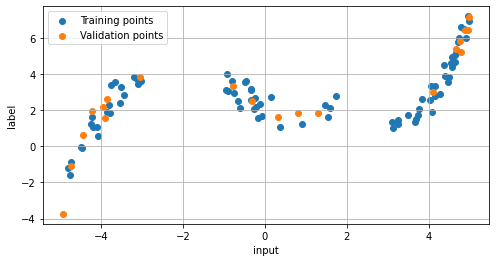

FOLD 2
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 9.207235336303711
AVERAGE VAL LOSS: 8.734143257141113
# EPOCH 2
AVERAGE TRAIN LOSS: 6.881389617919922
AVERAGE VAL LOSS: 5.71368932723999
# EPOCH 3
AVERAGE TRAIN LOSS: 4.652215003967285
AVERAGE VAL LOSS: 3.7953994274139404
# EPOCH 4
AVERAGE TRAIN LOSS: 3.8490653038024902
AVERAGE VAL LOSS: 2.709473133087158
# EPOCH 5
AVERAGE TRAIN LOSS: 3.290177822113037
AVERAGE VAL LOSS: 2.4013123512268066
# EPOCH 6
AVERAGE TRAIN LOSS: 3.185394048690796
AVERAGE VAL LOSS: 2.5933804512023926
# EPOCH 7
AVERAGE TRAIN LOSS: 3.2056806087493896
AVERAGE VAL LOSS: 2.907858371734619
# EPOCH 8
AVERAGE TRAIN LOSS: 3.259345531463623
AVERAGE VAL LOSS: 3.0764060020446777
# EPOCH 9
AVERAGE TRAIN LOSS: 3.24690580368042
AVERAGE VAL LOSS: 2.9572792053222656
# EPOCH 10
AVERAGE TRAIN LOSS: 3.094914436340332
AVERAGE VAL LOSS: 2.701772451400757
# EPOCH 11
AVERAGE TRAIN LOSS: 2.7627153396606445
AVERAGE VAL LOSS: 2.519981622695923
# 

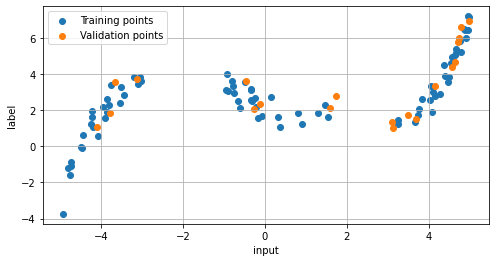

FOLD 3
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 9.67660140991211
AVERAGE VAL LOSS: 4.567466735839844
# EPOCH 2
AVERAGE TRAIN LOSS: 6.33612060546875
AVERAGE VAL LOSS: 4.331592559814453
# EPOCH 3
AVERAGE TRAIN LOSS: 4.30010986328125
AVERAGE VAL LOSS: 4.390237331390381
# EPOCH 4
AVERAGE TRAIN LOSS: 3.3208019733428955
AVERAGE VAL LOSS: 4.633987903594971
# EPOCH 5
AVERAGE TRAIN LOSS: 2.9826931953430176
AVERAGE VAL LOSS: 4.592367172241211
# EPOCH 6
AVERAGE TRAIN LOSS: 2.9789655208587646
AVERAGE VAL LOSS: 4.443573474884033
# EPOCH 7
AVERAGE TRAIN LOSS: 3.164069175720215
AVERAGE VAL LOSS: 4.231349468231201
# EPOCH 8
AVERAGE TRAIN LOSS: 3.2999682426452637
AVERAGE VAL LOSS: 3.9559128284454346
# EPOCH 9
AVERAGE TRAIN LOSS: 3.2848563194274902
AVERAGE VAL LOSS: 3.657705068588257
# EPOCH 10
AVERAGE TRAIN LOSS: 3.0366485118865967
AVERAGE VAL LOSS: 3.3957748413085938
# EPOCH 11
AVERAGE TRAIN LOSS: 2.8207335472106934
AVERAGE VAL LOSS: 3.199821949005127
# 

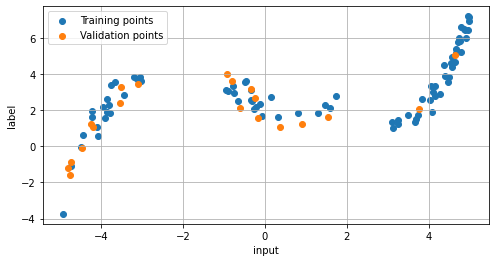

FOLD 4
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 12.3247709274292
AVERAGE VAL LOSS: 8.950019836425781
# EPOCH 2
AVERAGE TRAIN LOSS: 8.262290954589844
AVERAGE VAL LOSS: 5.404824733734131
# EPOCH 3
AVERAGE TRAIN LOSS: 5.713284492492676
AVERAGE VAL LOSS: 3.2459030151367188
# EPOCH 4
AVERAGE TRAIN LOSS: 4.366026878356934
AVERAGE VAL LOSS: 2.2997448444366455
# EPOCH 5
AVERAGE TRAIN LOSS: 3.462303638458252
AVERAGE VAL LOSS: 2.345590353012085
# EPOCH 6
AVERAGE TRAIN LOSS: 3.127519130706787
AVERAGE VAL LOSS: 3.042987823486328
# EPOCH 7
AVERAGE TRAIN LOSS: 3.214951753616333
AVERAGE VAL LOSS: 3.7701892852783203
# EPOCH 8
AVERAGE TRAIN LOSS: 3.1739253997802734
AVERAGE VAL LOSS: 4.223415374755859
# EPOCH 9
AVERAGE TRAIN LOSS: 3.275524616241455
AVERAGE VAL LOSS: 4.252858638763428
# EPOCH 10
AVERAGE TRAIN LOSS: 3.0581045150756836
AVERAGE VAL LOSS: 3.9650933742523193
# EPOCH 11
AVERAGE TRAIN LOSS: 2.8953354358673096
AVERAGE VAL LOSS: 3.5836198329925537
#

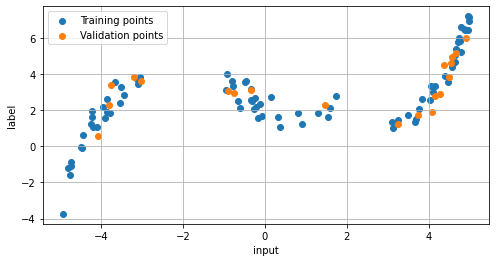

FOLD 5
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 10.839595794677734
AVERAGE VAL LOSS: 7.654693603515625
# EPOCH 2
AVERAGE TRAIN LOSS: 8.231703758239746
AVERAGE VAL LOSS: 5.906614780426025
# EPOCH 3
AVERAGE TRAIN LOSS: 6.622139930725098
AVERAGE VAL LOSS: 4.656507968902588
# EPOCH 4
AVERAGE TRAIN LOSS: 5.632949352264404
AVERAGE VAL LOSS: 3.7308292388916016
# EPOCH 5
AVERAGE TRAIN LOSS: 4.460452079772949
AVERAGE VAL LOSS: 3.0892791748046875
# EPOCH 6
AVERAGE TRAIN LOSS: 3.8529415130615234
AVERAGE VAL LOSS: 2.7098240852355957
# EPOCH 7
AVERAGE TRAIN LOSS: 3.4729185104370117
AVERAGE VAL LOSS: 2.5885655879974365
# EPOCH 8
AVERAGE TRAIN LOSS: 3.0697178840637207
AVERAGE VAL LOSS: 2.65442156791687
# EPOCH 9
AVERAGE TRAIN LOSS: 2.884856700897217
AVERAGE VAL LOSS: 2.8024213314056396
# EPOCH 10
AVERAGE TRAIN LOSS: 3.1154613494873047
AVERAGE VAL LOSS: 2.9576542377471924
# EPOCH 11
AVERAGE TRAIN LOSS: 3.2493207454681396
AVERAGE VAL LOSS: 2.9934775829315

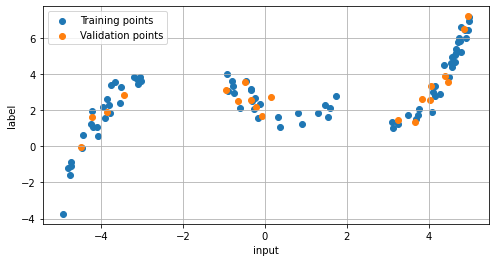

[I 2022-01-10 18:38:09,057] Trial 0 finished with value: 0.35290277004241943 and parameters: {'n_units_l0': 128, 'n_units_l1': 128, 'dropout': 0.1, 'weight_decay': 0.0001}. Best is trial 0 with value: 0.35290277004241943.


FOLD 1
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 8.216353416442871
AVERAGE VAL LOSS: 10.723872184753418
# EPOCH 2
AVERAGE TRAIN LOSS: 6.546169281005859
AVERAGE VAL LOSS: 9.481669425964355
# EPOCH 3
AVERAGE TRAIN LOSS: 5.80340051651001
AVERAGE VAL LOSS: 8.465524673461914
# EPOCH 4
AVERAGE TRAIN LOSS: 5.08243989944458
AVERAGE VAL LOSS: 7.656157970428467
# EPOCH 5
AVERAGE TRAIN LOSS: 4.179459571838379
AVERAGE VAL LOSS: 6.936246395111084
# EPOCH 6
AVERAGE TRAIN LOSS: 4.173844337463379
AVERAGE VAL LOSS: 6.325954437255859
# EPOCH 7
AVERAGE TRAIN LOSS: 3.58984112739563
AVERAGE VAL LOSS: 5.688814163208008
# EPOCH 8
AVERAGE TRAIN LOSS: 3.324071168899536
AVERAGE VAL LOSS: 5.088013648986816
# EPOCH 9
AVERAGE TRAIN LOSS: 3.3923637866973877
AVERAGE VAL LOSS: 4.5097737312316895
# EPOCH 10
AVERAGE TRAIN LOSS: 3.2247934341430664
AVERAGE VAL LOSS: 4.019928455352783
# EPOCH 11
AVERAGE TRAIN LOSS: 3.224470615386963
AVERAGE VAL LOSS: 3.6755683422088623
# EPOCH 12
AVERAGE TRAIN LOSS: 2.980454206466675
AVERAGE VAL LOSS: 3.4752748012542

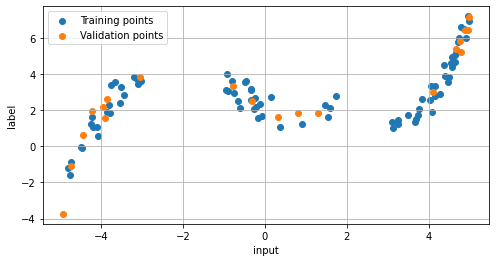

FOLD 2
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 12.536073684692383
AVERAGE VAL LOSS: 13.628878593444824
# EPOCH 2
AVERAGE TRAIN LOSS: 10.552375793457031
AVERAGE VAL LOSS: 10.935969352722168
# EPOCH 3
AVERAGE TRAIN LOSS: 8.249571800231934
AVERAGE VAL LOSS: 8.686949729919434
# EPOCH 4
AVERAGE TRAIN LOSS: 7.0825347900390625
AVERAGE VAL LOSS: 6.793604373931885
# EPOCH 5
AVERAGE TRAIN LOSS: 5.510534763336182
AVERAGE VAL LOSS: 5.275500774383545
# EPOCH 6
AVERAGE TRAIN LOSS: 5.465727806091309
AVERAGE VAL LOSS: 4.119865417480469
# EPOCH 7
AVERAGE TRAIN LOSS: 4.164406776428223
AVERAGE VAL LOSS: 3.325153112411499
# EPOCH 8
AVERAGE TRAIN LOSS: 4.030426502227783
AVERAGE VAL LOSS: 2.827198028564453
# EPOCH 9
AVERAGE TRAIN LOSS: 3.8351502418518066
AVERAGE VAL LOSS: 2.567095994949341
# EPOCH 10
AVERAGE TRAIN LOSS: 3.790743827819824
AVERAGE VAL LOSS: 2.5329384803771973
# EPOCH 11
AVERAGE TRAIN LOSS: 3.5981898307800293
AVERAGE VAL LOSS: 2.6065540313720703

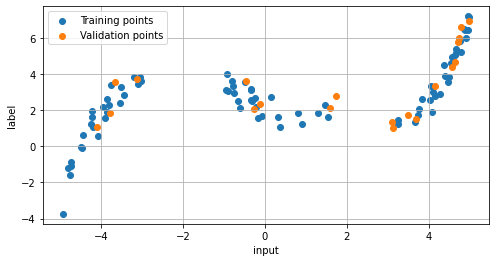

FOLD 3
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 15.92434310913086
AVERAGE VAL LOSS: 6.47433614730835
# EPOCH 2
AVERAGE TRAIN LOSS: 12.959545135498047
AVERAGE VAL LOSS: 5.760778903961182
# EPOCH 3
AVERAGE TRAIN LOSS: 10.428905487060547
AVERAGE VAL LOSS: 5.258514881134033
# EPOCH 4
AVERAGE TRAIN LOSS: 9.586645126342773
AVERAGE VAL LOSS: 4.904412269592285
# EPOCH 5
AVERAGE TRAIN LOSS: 8.11556625366211
AVERAGE VAL LOSS: 4.6905131340026855
# EPOCH 6
AVERAGE TRAIN LOSS: 7.297728061676025
AVERAGE VAL LOSS: 4.603152751922607
# EPOCH 7
AVERAGE TRAIN LOSS: 6.042964935302734
AVERAGE VAL LOSS: 4.588890075683594
# EPOCH 8
AVERAGE TRAIN LOSS: 5.919406414031982
AVERAGE VAL LOSS: 4.628781795501709
# EPOCH 9
AVERAGE TRAIN LOSS: 4.849506378173828
AVERAGE VAL LOSS: 4.689675807952881
# EPOCH 10
AVERAGE TRAIN LOSS: 4.303447723388672
AVERAGE VAL LOSS: 4.713709831237793
# EPOCH 11
AVERAGE TRAIN LOSS: 3.957792282104492
AVERAGE VAL LOSS: 4.697812080383301
# EPOCH

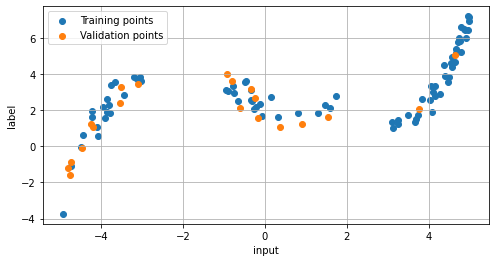

FOLD 4
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 12.641010284423828
AVERAGE VAL LOSS: 11.391786575317383
# EPOCH 2
AVERAGE TRAIN LOSS: 11.510080337524414
AVERAGE VAL LOSS: 9.377768516540527
# EPOCH 3
AVERAGE TRAIN LOSS: 9.141209602355957
AVERAGE VAL LOSS: 7.641885280609131
# EPOCH 4
AVERAGE TRAIN LOSS: 8.893372535705566
AVERAGE VAL LOSS: 6.119491100311279
# EPOCH 5
AVERAGE TRAIN LOSS: 7.318321228027344
AVERAGE VAL LOSS: 4.885621547698975
# EPOCH 6
AVERAGE TRAIN LOSS: 6.113739490509033
AVERAGE VAL LOSS: 3.852670669555664
# EPOCH 7
AVERAGE TRAIN LOSS: 5.500481605529785
AVERAGE VAL LOSS: 3.1079463958740234
# EPOCH 8
AVERAGE TRAIN LOSS: 4.18817663192749
AVERAGE VAL LOSS: 2.6231982707977295
# EPOCH 9
AVERAGE TRAIN LOSS: 3.5687499046325684
AVERAGE VAL LOSS: 2.3193719387054443
# EPOCH 10
AVERAGE TRAIN LOSS: 3.326519012451172
AVERAGE VAL LOSS: 2.234766721725464
# EPOCH 11
AVERAGE TRAIN LOSS: 3.116452693939209
AVERAGE VAL LOSS: 2.342740535736084
# 

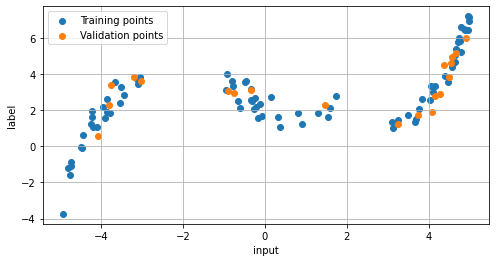

FOLD 5
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 10.466531753540039
AVERAGE VAL LOSS: 7.253795623779297
# EPOCH 2
AVERAGE TRAIN LOSS: 8.189019203186035
AVERAGE VAL LOSS: 5.616588115692139
# EPOCH 3
AVERAGE TRAIN LOSS: 6.6641926765441895
AVERAGE VAL LOSS: 4.358632564544678
# EPOCH 4
AVERAGE TRAIN LOSS: 5.611374855041504
AVERAGE VAL LOSS: 3.453253984451294
# EPOCH 5
AVERAGE TRAIN LOSS: 4.494067668914795
AVERAGE VAL LOSS: 2.8590362071990967
# EPOCH 6
AVERAGE TRAIN LOSS: 4.329896926879883
AVERAGE VAL LOSS: 2.5379066467285156
# EPOCH 7
AVERAGE TRAIN LOSS: 3.2650411128997803
AVERAGE VAL LOSS: 2.440716505050659
# EPOCH 8
AVERAGE TRAIN LOSS: 3.4372692108154297
AVERAGE VAL LOSS: 2.484652042388916
# EPOCH 9
AVERAGE TRAIN LOSS: 3.7497658729553223
AVERAGE VAL LOSS: 2.5935401916503906
# EPOCH 10
AVERAGE TRAIN LOSS: 3.4819703102111816
AVERAGE VAL LOSS: 2.69299054145813
# EPOCH 11
AVERAGE TRAIN LOSS: 3.5925612449645996
AVERAGE VAL LOSS: 2.736124753952026

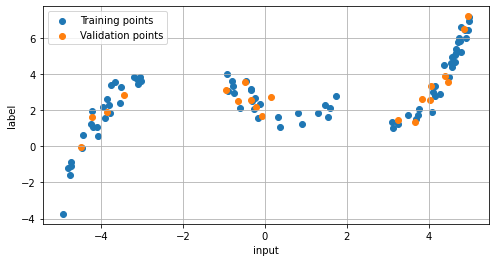

[I 2022-01-10 18:44:58,854] Trial 1 finished with value: 0.42244940996170044 and parameters: {'n_units_l0': 64, 'n_units_l1': 128, 'dropout': 0.5, 'weight_decay': 0.0001}. Best is trial 0 with value: 0.35290277004241943.


FOLD 1
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 9.564335823059082
AVERAGE VAL LOSS: 12.163787841796875
# EPOCH 2
AVERAGE TRAIN LOSS: 7.524135112762451
AVERAGE VAL LOSS: 10.354934692382812
# EPOCH 3
AVERAGE TRAIN LOSS: 6.185759544372559
AVERAGE VAL LOSS: 8.848174095153809
# EPOCH 4
AVERAGE TRAIN LOSS: 5.021626949310303
AVERAGE VAL LOSS: 7.51971960067749
# EPOCH 5
AVERAGE TRAIN LOSS: 3.9600038528442383
AVERAGE VAL LOSS: 6.404745578765869
# EPOCH 6
AVERAGE TRAIN LOSS: 3.327180862426758
AVERAGE VAL LOSS: 5.471155643463135
# EPOCH 7
AVERAGE TRAIN LOSS: 3.0064170360565186
AVERAGE VAL LOSS: 4.7892656326293945
# EPOCH 8
AVERAGE TRAIN LOSS: 2.7964417934417725
AVERAGE VAL LOSS: 4.2350897789001465
# EPOCH 9
AVERAGE TRAIN LOSS: 2.665177822113037
AVERAGE VAL LOSS: 3.893719434738159
# EPOCH 10
AVERAGE TRAIN LOSS: 2.8401572704315186
AVERAGE VAL LOSS: 3.618168592453003
# EPOCH 11
AVERAGE TRAIN LOSS: 2.773969888687134
AVERAGE VAL LOSS: 3.3965671062469482
# EPOCH 12
AVERAGE TRAIN LOSS: 2.8764052391052246
AVERAGE VAL LOSS: 3.281019

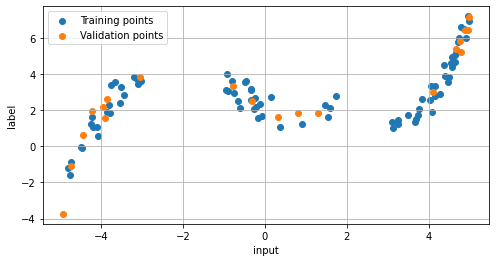

FOLD 2
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 12.599806785583496
AVERAGE VAL LOSS: 14.186904907226562
# EPOCH 2
AVERAGE TRAIN LOSS: 10.662981033325195
AVERAGE VAL LOSS: 11.930084228515625
# EPOCH 3
AVERAGE TRAIN LOSS: 9.099762916564941
AVERAGE VAL LOSS: 10.006535530090332
# EPOCH 4
AVERAGE TRAIN LOSS: 7.588785648345947
AVERAGE VAL LOSS: 8.366159439086914
# EPOCH 5
AVERAGE TRAIN LOSS: 6.883355140686035
AVERAGE VAL LOSS: 6.9759840965271
# EPOCH 6
AVERAGE TRAIN LOSS: 5.929504871368408
AVERAGE VAL LOSS: 5.799352169036865
# EPOCH 7
AVERAGE TRAIN LOSS: 5.244029998779297
AVERAGE VAL LOSS: 4.8004631996154785
# EPOCH 8
AVERAGE TRAIN LOSS: 4.832980155944824
AVERAGE VAL LOSS: 3.978823184967041
# EPOCH 9
AVERAGE TRAIN LOSS: 4.127471923828125
AVERAGE VAL LOSS: 3.369277238845825
# EPOCH 10
AVERAGE TRAIN LOSS: 3.6109728813171387
AVERAGE VAL LOSS: 2.9190673828125
# EPOCH 11
AVERAGE TRAIN LOSS: 3.438142776489258
AVERAGE VAL LOSS: 2.6267738342285156
# EP

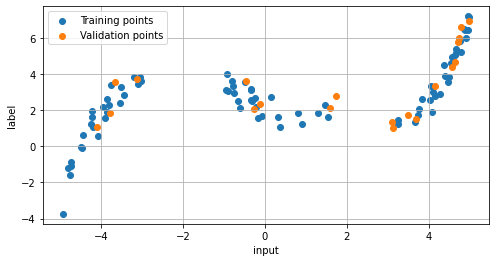

FOLD 3
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 13.638810157775879
AVERAGE VAL LOSS: 5.782761573791504
# EPOCH 2
AVERAGE TRAIN LOSS: 11.125926971435547
AVERAGE VAL LOSS: 5.140467166900635
# EPOCH 3
AVERAGE TRAIN LOSS: 9.1112642288208
AVERAGE VAL LOSS: 4.7149176597595215
# EPOCH 4
AVERAGE TRAIN LOSS: 7.424424171447754
AVERAGE VAL LOSS: 4.456765651702881
# EPOCH 5
AVERAGE TRAIN LOSS: 5.892950057983398
AVERAGE VAL LOSS: 4.347494602203369
# EPOCH 6
AVERAGE TRAIN LOSS: 5.009607315063477
AVERAGE VAL LOSS: 4.364485263824463
# EPOCH 7
AVERAGE TRAIN LOSS: 3.9971389770507812
AVERAGE VAL LOSS: 4.4768877029418945
# EPOCH 8
AVERAGE TRAIN LOSS: 3.4535722732543945
AVERAGE VAL LOSS: 4.622260570526123
# EPOCH 9
AVERAGE TRAIN LOSS: 3.0145974159240723
AVERAGE VAL LOSS: 4.723847389221191
# EPOCH 10
AVERAGE TRAIN LOSS: 2.9776864051818848
AVERAGE VAL LOSS: 4.8090739250183105
# EPOCH 11
AVERAGE TRAIN LOSS: 3.080772876739502
AVERAGE VAL LOSS: 4.807669162750244
#

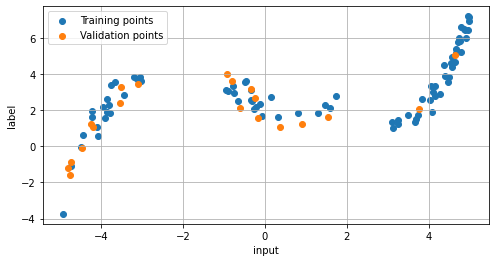

FOLD 4
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 11.480113983154297
AVERAGE VAL LOSS: 10.027854919433594
# EPOCH 2
AVERAGE TRAIN LOSS: 9.523147583007812
AVERAGE VAL LOSS: 8.057685852050781
# EPOCH 3
AVERAGE TRAIN LOSS: 8.286579132080078
AVERAGE VAL LOSS: 6.348050594329834
# EPOCH 4
AVERAGE TRAIN LOSS: 7.123319625854492
AVERAGE VAL LOSS: 5.0005388259887695
# EPOCH 5
AVERAGE TRAIN LOSS: 5.848228454589844
AVERAGE VAL LOSS: 3.947002410888672
# EPOCH 6
AVERAGE TRAIN LOSS: 5.23861837387085
AVERAGE VAL LOSS: 3.15311598777771
# EPOCH 7
AVERAGE TRAIN LOSS: 4.432716369628906
AVERAGE VAL LOSS: 2.6129910945892334
# EPOCH 8
AVERAGE TRAIN LOSS: 4.00942325592041
AVERAGE VAL LOSS: 2.3112781047821045
# EPOCH 9
AVERAGE TRAIN LOSS: 3.4775547981262207
AVERAGE VAL LOSS: 2.2793004512786865
# EPOCH 10
AVERAGE TRAIN LOSS: 3.030722141265869
AVERAGE VAL LOSS: 2.4428703784942627
# EPOCH 11
AVERAGE TRAIN LOSS: 2.891366481781006
AVERAGE VAL LOSS: 2.7689876556396484
# 

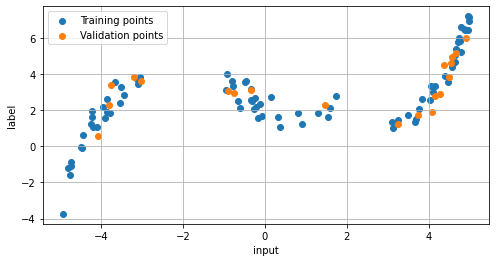

FOLD 5
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 16.08361053466797
AVERAGE VAL LOSS: 12.506416320800781
# EPOCH 2
AVERAGE TRAIN LOSS: 13.372249603271484
AVERAGE VAL LOSS: 10.365135192871094
# EPOCH 3
AVERAGE TRAIN LOSS: 11.19257640838623
AVERAGE VAL LOSS: 8.547901153564453
# EPOCH 4
AVERAGE TRAIN LOSS: 9.1951322555542
AVERAGE VAL LOSS: 7.049175262451172
# EPOCH 5
AVERAGE TRAIN LOSS: 7.821160316467285
AVERAGE VAL LOSS: 5.767030239105225
# EPOCH 6
AVERAGE TRAIN LOSS: 6.447565078735352
AVERAGE VAL LOSS: 4.704719066619873
# EPOCH 7
AVERAGE TRAIN LOSS: 5.407580852508545
AVERAGE VAL LOSS: 3.871633291244507
# EPOCH 8
AVERAGE TRAIN LOSS: 4.591592311859131
AVERAGE VAL LOSS: 3.2763702869415283
# EPOCH 9
AVERAGE TRAIN LOSS: 4.175418853759766
AVERAGE VAL LOSS: 2.9139530658721924
# EPOCH 10
AVERAGE TRAIN LOSS: 3.8170056343078613
AVERAGE VAL LOSS: 2.749811887741089
# EPOCH 11
AVERAGE TRAIN LOSS: 3.389394760131836
AVERAGE VAL LOSS: 2.742288589477539
# EP

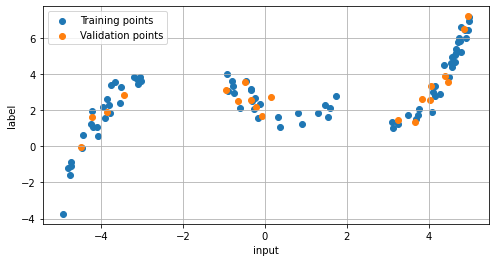

[I 2022-01-10 18:52:05,495] Trial 2 finished with value: 0.27152448892593384 and parameters: {'n_units_l0': 64, 'n_units_l1': 128, 'dropout': 0.1, 'weight_decay': 0.0001}. Best is trial 2 with value: 0.27152448892593384.


FOLD 1
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 11.935174942016602
AVERAGE VAL LOSS: 14.796167373657227
# EPOCH 2
AVERAGE TRAIN LOSS: 10.009359359741211
AVERAGE VAL LOSS: 12.892081260681152
# EPOCH 3
AVERAGE TRAIN LOSS: 8.070817947387695
AVERAGE VAL LOSS: 11.352532386779785
# EPOCH 4
AVERAGE TRAIN LOSS: 6.806029319763184
AVERAGE VAL LOSS: 10.175536155700684
# EPOCH 5
AVERAGE TRAIN LOSS: 5.867663383483887
AVERAGE VAL LOSS: 9.234831809997559
# EPOCH 6
AVERAGE TRAIN LOSS: 5.047521591186523
AVERAGE VAL LOSS: 8.44207763671875
# EPOCH 7
AVERAGE TRAIN LOSS: 4.372415542602539
AVERAGE VAL LOSS: 7.612126350402832
# EPOCH 8
AVERAGE TRAIN LOSS: 3.74908447265625
AVERAGE VAL LOSS: 6.75171422958374
# EPOCH 9
AVERAGE TRAIN LOSS: 3.2997448444366455
AVERAGE VAL LOSS: 5.935336112976074
# EPOCH 10
AVERAGE TRAIN LOSS: 2.998811960220337
AVERAGE VAL LOSS: 5.2021918296813965
# EPOCH 11
AVERAGE TRAIN LOSS: 2.8868393898010254
AVERAGE VAL LOSS: 4.554805278778076
# EPOCH 12
AVERAGE TRAIN LOSS: 2.8109617233276367
AVERAGE VAL LOSS: 4.04092025

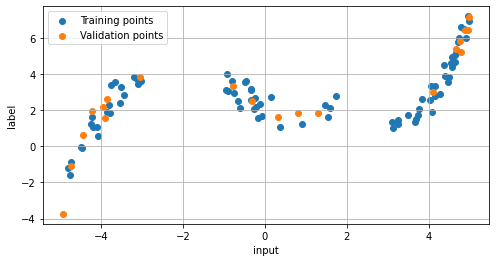

FOLD 2
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 6.709315299987793
AVERAGE VAL LOSS: 5.635235786437988
# EPOCH 2
AVERAGE TRAIN LOSS: 4.946802139282227
AVERAGE VAL LOSS: 3.8781204223632812
# EPOCH 3
AVERAGE TRAIN LOSS: 3.976623058319092
AVERAGE VAL LOSS: 2.870166540145874
# EPOCH 4
AVERAGE TRAIN LOSS: 3.2723207473754883
AVERAGE VAL LOSS: 2.5895698070526123
# EPOCH 5
AVERAGE TRAIN LOSS: 3.2909536361694336
AVERAGE VAL LOSS: 2.722654342651367
# EPOCH 6
AVERAGE TRAIN LOSS: 3.310823440551758
AVERAGE VAL LOSS: 2.938169240951538
# EPOCH 7
AVERAGE TRAIN LOSS: 3.535130023956299
AVERAGE VAL LOSS: 2.9858779907226562
# EPOCH 8
AVERAGE TRAIN LOSS: 3.5078978538513184
AVERAGE VAL LOSS: 2.886709451675415
# EPOCH 9
AVERAGE TRAIN LOSS: 3.1200480461120605
AVERAGE VAL LOSS: 2.7275261878967285
# EPOCH 10
AVERAGE TRAIN LOSS: 3.0993733406066895
AVERAGE VAL LOSS: 2.5764129161834717
# EPOCH 11
AVERAGE TRAIN LOSS: 2.9325180053710938
AVERAGE VAL LOSS: 2.53454184532165

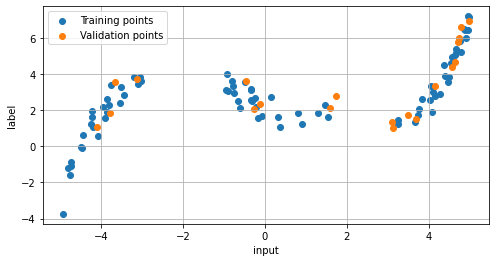

FOLD 3
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 11.809610366821289
AVERAGE VAL LOSS: 5.124509334564209
# EPOCH 2
AVERAGE TRAIN LOSS: 10.085444450378418
AVERAGE VAL LOSS: 4.8360819816589355
# EPOCH 3
AVERAGE TRAIN LOSS: 8.059237480163574
AVERAGE VAL LOSS: 4.8074822425842285
# EPOCH 4
AVERAGE TRAIN LOSS: 6.769188404083252
AVERAGE VAL LOSS: 4.908236980438232
# EPOCH 5
AVERAGE TRAIN LOSS: 5.464679718017578
AVERAGE VAL LOSS: 4.987027645111084
# EPOCH 6
AVERAGE TRAIN LOSS: 4.633345603942871
AVERAGE VAL LOSS: 4.88756799697876
# EPOCH 7
AVERAGE TRAIN LOSS: 3.7743372917175293
AVERAGE VAL LOSS: 4.72628116607666
# EPOCH 8
AVERAGE TRAIN LOSS: 3.3895890712738037
AVERAGE VAL LOSS: 4.512567043304443
# EPOCH 9
AVERAGE TRAIN LOSS: 2.9891674518585205
AVERAGE VAL LOSS: 4.302092552185059
# EPOCH 10
AVERAGE TRAIN LOSS: 2.9432151317596436
AVERAGE VAL LOSS: 4.087165355682373
# EPOCH 11
AVERAGE TRAIN LOSS: 2.906628131866455
AVERAGE VAL LOSS: 3.9362289905548096
# 

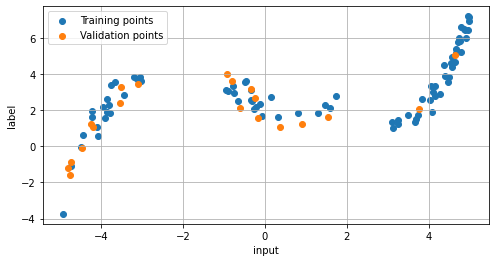

FOLD 4
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.394783020019531
AVERAGE VAL LOSS: 8.415249824523926
# EPOCH 2
AVERAGE TRAIN LOSS: 8.4225435256958
AVERAGE VAL LOSS: 6.241340637207031
# EPOCH 3
AVERAGE TRAIN LOSS: 6.85218620300293
AVERAGE VAL LOSS: 4.567098140716553
# EPOCH 4
AVERAGE TRAIN LOSS: 5.616070747375488
AVERAGE VAL LOSS: 3.426743268966675
# EPOCH 5
AVERAGE TRAIN LOSS: 4.577947616577148
AVERAGE VAL LOSS: 2.7117717266082764
# EPOCH 6
AVERAGE TRAIN LOSS: 4.1116719245910645
AVERAGE VAL LOSS: 2.3438560962677
# EPOCH 7
AVERAGE TRAIN LOSS: 3.4918088912963867
AVERAGE VAL LOSS: 2.3018136024475098
# EPOCH 8
AVERAGE TRAIN LOSS: 3.087646961212158
AVERAGE VAL LOSS: 2.542496919631958
# EPOCH 9
AVERAGE TRAIN LOSS: 3.0167076587677
AVERAGE VAL LOSS: 2.9594695568084717
# EPOCH 10
AVERAGE TRAIN LOSS: 2.9223880767822266
AVERAGE VAL LOSS: 3.3806800842285156
# EPOCH 11
AVERAGE TRAIN LOSS: 3.081489086151123
AVERAGE VAL LOSS: 3.716169834136963
# EPOCH 

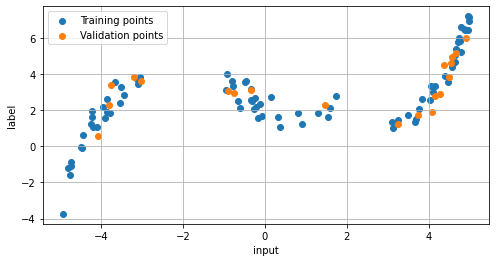

FOLD 5
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 12.794029235839844
AVERAGE VAL LOSS: 9.646269798278809
# EPOCH 2
AVERAGE TRAIN LOSS: 10.185566902160645
AVERAGE VAL LOSS: 7.481468200683594
# EPOCH 3
AVERAGE TRAIN LOSS: 8.217779159545898
AVERAGE VAL LOSS: 5.757016181945801
# EPOCH 4
AVERAGE TRAIN LOSS: 6.5739946365356445
AVERAGE VAL LOSS: 4.504397869110107
# EPOCH 5
AVERAGE TRAIN LOSS: 5.187598705291748
AVERAGE VAL LOSS: 3.6498711109161377
# EPOCH 6
AVERAGE TRAIN LOSS: 4.302972793579102
AVERAGE VAL LOSS: 3.128988265991211
# EPOCH 7
AVERAGE TRAIN LOSS: 3.7382891178131104
AVERAGE VAL LOSS: 2.866901397705078
# EPOCH 8
AVERAGE TRAIN LOSS: 3.469672679901123
AVERAGE VAL LOSS: 2.8152577877044678
# EPOCH 9
AVERAGE TRAIN LOSS: 3.395418643951416
AVERAGE VAL LOSS: 2.8988399505615234
# EPOCH 10
AVERAGE TRAIN LOSS: 3.479348659515381
AVERAGE VAL LOSS: 3.0384490489959717
# EPOCH 11
AVERAGE TRAIN LOSS: 3.564302444458008
AVERAGE VAL LOSS: 3.144170045852661
#

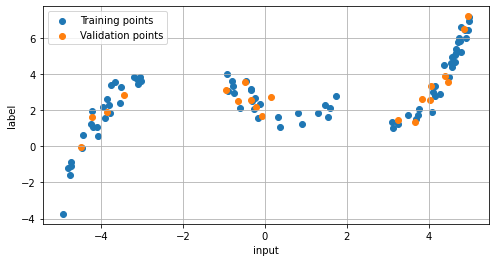

[I 2022-01-10 18:59:40,354] Trial 3 finished with value: 0.3094708323478699 and parameters: {'n_units_l0': 64, 'n_units_l1': 128, 'dropout': 0.1, 'weight_decay': 1e-05}. Best is trial 2 with value: 0.27152448892593384.


FOLD 1
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 9.556124687194824
AVERAGE VAL LOSS: 10.048583030700684
# EPOCH 2
AVERAGE TRAIN LOSS: 6.47844934463501
AVERAGE VAL LOSS: 7.526210308074951
# EPOCH 3
AVERAGE TRAIN LOSS: 4.0210371017456055
AVERAGE VAL LOSS: 6.2467122077941895
# EPOCH 4
AVERAGE TRAIN LOSS: 3.3198249340057373
AVERAGE VAL LOSS: 5.064093112945557
# EPOCH 5
AVERAGE TRAIN LOSS: 3.451687812805176
AVERAGE VAL LOSS: 4.228811740875244
# EPOCH 6
AVERAGE TRAIN LOSS: 3.17335844039917
AVERAGE VAL LOSS: 3.6539065837860107
# EPOCH 7
AVERAGE TRAIN LOSS: 3.2005207538604736
AVERAGE VAL LOSS: 3.2433953285217285
# EPOCH 8
AVERAGE TRAIN LOSS: 3.2931482791900635
AVERAGE VAL LOSS: 3.0665175914764404
# EPOCH 9
AVERAGE TRAIN LOSS: 3.1399993896484375
AVERAGE VAL LOSS: 3.0267791748046875
# EPOCH 10
AVERAGE TRAIN LOSS: 2.6111438274383545
AVERAGE VAL LOSS: 3.1552555561065674
# EPOCH 11
AVERAGE TRAIN LOSS: 2.442533493041992
AVERAGE VAL LOSS: 3.3962128162384033
# EPOCH 12
AVERAGE TRAIN LOSS: 2.6863932609558105
AVERAGE VAL LOSS: 3.64

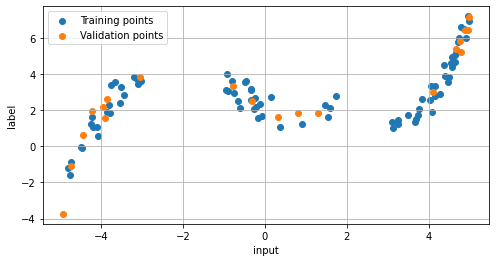

FOLD 2
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 11.376359939575195
AVERAGE VAL LOSS: 9.882492065429688
# EPOCH 2
AVERAGE TRAIN LOSS: 7.567559242248535
AVERAGE VAL LOSS: 5.439510345458984
# EPOCH 3
AVERAGE TRAIN LOSS: 5.008418083190918
AVERAGE VAL LOSS: 3.1294329166412354
# EPOCH 4
AVERAGE TRAIN LOSS: 4.103725433349609
AVERAGE VAL LOSS: 2.2642765045166016
# EPOCH 5
AVERAGE TRAIN LOSS: 3.6728811264038086
AVERAGE VAL LOSS: 2.46226167678833
# EPOCH 6
AVERAGE TRAIN LOSS: 3.3066418170928955
AVERAGE VAL LOSS: 2.9533519744873047
# EPOCH 7
AVERAGE TRAIN LOSS: 3.8217039108276367
AVERAGE VAL LOSS: 3.172410249710083
# EPOCH 8
AVERAGE TRAIN LOSS: 3.53967547416687
AVERAGE VAL LOSS: 3.1070005893707275
# EPOCH 9
AVERAGE TRAIN LOSS: 3.2790980339050293
AVERAGE VAL LOSS: 2.882594108581543
# EPOCH 10
AVERAGE TRAIN LOSS: 2.97009015083313
AVERAGE VAL LOSS: 2.6250808238983154
# EPOCH 11
AVERAGE TRAIN LOSS: 2.75358510017395
AVERAGE VAL LOSS: 2.4641432762145996
# 

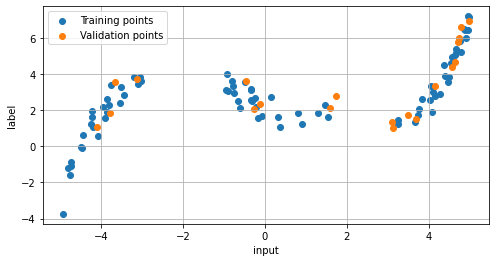

FOLD 3
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.477184295654297
AVERAGE VAL LOSS: 4.6786394119262695
# EPOCH 2
AVERAGE TRAIN LOSS: 6.1486496925354
AVERAGE VAL LOSS: 4.9182915687561035
# EPOCH 3
AVERAGE TRAIN LOSS: 4.105497360229492
AVERAGE VAL LOSS: 4.838094234466553
# EPOCH 4
AVERAGE TRAIN LOSS: 3.5100479125976562
AVERAGE VAL LOSS: 4.676916599273682
# EPOCH 5
AVERAGE TRAIN LOSS: 3.078827381134033
AVERAGE VAL LOSS: 4.3274359703063965
# EPOCH 6
AVERAGE TRAIN LOSS: 3.9905893802642822
AVERAGE VAL LOSS: 3.896881580352783
# EPOCH 7
AVERAGE TRAIN LOSS: 3.287654399871826
AVERAGE VAL LOSS: 3.5794854164123535
# EPOCH 8
AVERAGE TRAIN LOSS: 3.172745704650879
AVERAGE VAL LOSS: 3.2557930946350098
# EPOCH 9
AVERAGE TRAIN LOSS: 2.647608757019043
AVERAGE VAL LOSS: 3.0353081226348877
# EPOCH 10
AVERAGE TRAIN LOSS: 2.7985289096832275
AVERAGE VAL LOSS: 2.9070611000061035
# EPOCH 11
AVERAGE TRAIN LOSS: 2.683831214904785
AVERAGE VAL LOSS: 2.8732309341430664

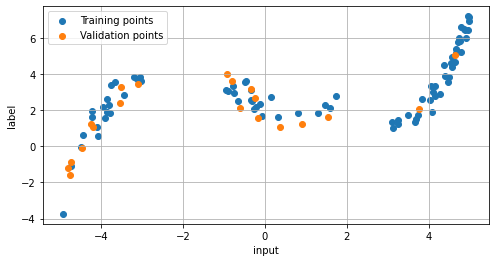

FOLD 4
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.443735122680664
AVERAGE VAL LOSS: 7.068962097167969
# EPOCH 2
AVERAGE TRAIN LOSS: 7.592406272888184
AVERAGE VAL LOSS: 4.200242519378662
# EPOCH 3
AVERAGE TRAIN LOSS: 5.161013603210449
AVERAGE VAL LOSS: 2.5974512100219727
# EPOCH 4
AVERAGE TRAIN LOSS: 4.247381687164307
AVERAGE VAL LOSS: 2.1858417987823486
# EPOCH 5
AVERAGE TRAIN LOSS: 3.4872887134552
AVERAGE VAL LOSS: 2.504654884338379
# EPOCH 6
AVERAGE TRAIN LOSS: 3.495145797729492
AVERAGE VAL LOSS: 3.2901628017425537
# EPOCH 7
AVERAGE TRAIN LOSS: 3.187427282333374
AVERAGE VAL LOSS: 3.9268205165863037
# EPOCH 8
AVERAGE TRAIN LOSS: 3.393770694732666
AVERAGE VAL LOSS: 3.977273941040039
# EPOCH 9
AVERAGE TRAIN LOSS: 3.3385109901428223
AVERAGE VAL LOSS: 3.7516536712646484
# EPOCH 10
AVERAGE TRAIN LOSS: 3.000562906265259
AVERAGE VAL LOSS: 3.2827541828155518
# EPOCH 11
AVERAGE TRAIN LOSS: 3.076395034790039
AVERAGE VAL LOSS: 2.767582654953003
# E

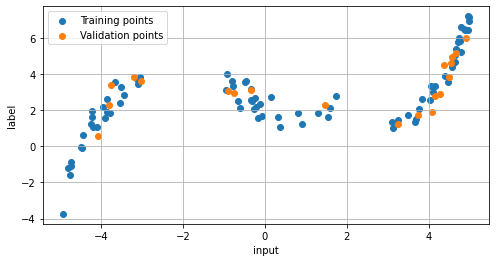

FOLD 5
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 11.071798324584961
AVERAGE VAL LOSS: 6.3330817222595215
# EPOCH 2
AVERAGE TRAIN LOSS: 6.858049392700195
AVERAGE VAL LOSS: 3.741032361984253
# EPOCH 3
AVERAGE TRAIN LOSS: 4.089336395263672
AVERAGE VAL LOSS: 2.5902481079101562
# EPOCH 4
AVERAGE TRAIN LOSS: 3.7658419609069824
AVERAGE VAL LOSS: 2.558879852294922
# EPOCH 5
AVERAGE TRAIN LOSS: 3.2953925132751465
AVERAGE VAL LOSS: 3.0940499305725098
# EPOCH 6
AVERAGE TRAIN LOSS: 3.741873025894165
AVERAGE VAL LOSS: 3.465961217880249
# EPOCH 7
AVERAGE TRAIN LOSS: 3.706007480621338
AVERAGE VAL LOSS: 3.333059787750244
# EPOCH 8
AVERAGE TRAIN LOSS: 3.8955283164978027
AVERAGE VAL LOSS: 2.965122699737549
# EPOCH 9
AVERAGE TRAIN LOSS: 2.8934569358825684
AVERAGE VAL LOSS: 2.5537235736846924
# EPOCH 10
AVERAGE TRAIN LOSS: 3.0310239791870117
AVERAGE VAL LOSS: 2.2172892093658447
# EPOCH 11
AVERAGE TRAIN LOSS: 2.6358461380004883
AVERAGE VAL LOSS: 1.9995472431182

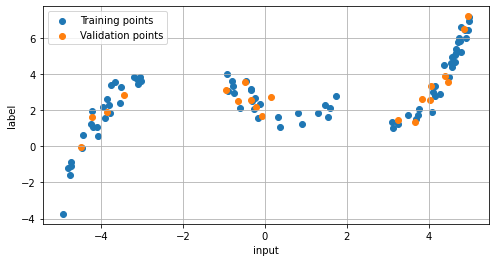

[I 2022-01-10 19:07:39,642] Trial 4 finished with value: 0.2103552371263504 and parameters: {'n_units_l0': 128, 'n_units_l1': 256, 'dropout': 0.5, 'weight_decay': 1e-05}. Best is trial 4 with value: 0.2103552371263504.


FOLD 1
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 9.241032600402832
AVERAGE VAL LOSS: 10.85758113861084
# EPOCH 2
AVERAGE TRAIN LOSS: 6.492369651794434
AVERAGE VAL LOSS: 8.664278984069824
# EPOCH 3
AVERAGE TRAIN LOSS: 4.9476728439331055
AVERAGE VAL LOSS: 6.9296698570251465
# EPOCH 4
AVERAGE TRAIN LOSS: 3.9060864448547363
AVERAGE VAL LOSS: 5.628118991851807
# EPOCH 5
AVERAGE TRAIN LOSS: 3.1750612258911133
AVERAGE VAL LOSS: 4.5682573318481445
# EPOCH 6
AVERAGE TRAIN LOSS: 3.134965181350708
AVERAGE VAL LOSS: 3.8559250831604004
# EPOCH 7
AVERAGE TRAIN LOSS: 2.9959495067596436
AVERAGE VAL LOSS: 3.484039306640625
# EPOCH 8
AVERAGE TRAIN LOSS: 3.4684524536132812
AVERAGE VAL LOSS: 3.213343858718872
# EPOCH 9
AVERAGE TRAIN LOSS: 2.9775021076202393
AVERAGE VAL LOSS: 3.0889060497283936
# EPOCH 10
AVERAGE TRAIN LOSS: 2.9273881912231445
AVERAGE VAL LOSS: 3.0502071380615234
# EPOCH 11
AVERAGE TRAIN LOSS: 2.9340295791625977
AVERAGE VAL LOSS: 3.130350112915039
# EPOCH 12
AVERAGE TRAIN LOSS: 2.8214199542999268
AVERAGE VAL LOSS: 3.2

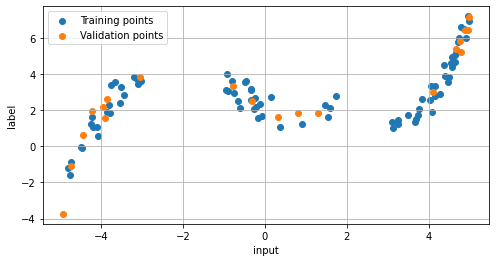

FOLD 2
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.798664093017578
AVERAGE VAL LOSS: 8.91187572479248
# EPOCH 2
AVERAGE TRAIN LOSS: 6.643834114074707
AVERAGE VAL LOSS: 5.425764560699463
# EPOCH 3
AVERAGE TRAIN LOSS: 4.931445598602295
AVERAGE VAL LOSS: 3.4011898040771484
# EPOCH 4
AVERAGE TRAIN LOSS: 4.207523345947266
AVERAGE VAL LOSS: 2.567298650741577
# EPOCH 5
AVERAGE TRAIN LOSS: 3.799586296081543
AVERAGE VAL LOSS: 2.5486600399017334
# EPOCH 6
AVERAGE TRAIN LOSS: 3.8479256629943848
AVERAGE VAL LOSS: 2.8029980659484863
# EPOCH 7
AVERAGE TRAIN LOSS: 3.438521385192871
AVERAGE VAL LOSS: 2.949064016342163
# EPOCH 8
AVERAGE TRAIN LOSS: 4.104158878326416
AVERAGE VAL LOSS: 2.919402837753296
# EPOCH 9
AVERAGE TRAIN LOSS: 3.412451982498169
AVERAGE VAL LOSS: 2.82905650138855
# EPOCH 10
AVERAGE TRAIN LOSS: 3.4709861278533936
AVERAGE VAL LOSS: 2.7363510131835938
# EPOCH 11
AVERAGE TRAIN LOSS: 3.463609218597412
AVERAGE VAL LOSS: 2.637878656387329
# EPO

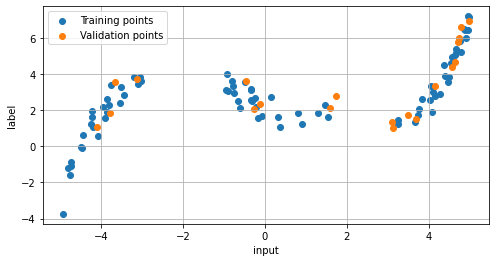

FOLD 3
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 13.342475891113281
AVERAGE VAL LOSS: 5.226125240325928
# EPOCH 2
AVERAGE TRAIN LOSS: 9.132410049438477
AVERAGE VAL LOSS: 4.615653991699219
# EPOCH 3
AVERAGE TRAIN LOSS: 6.412815093994141
AVERAGE VAL LOSS: 4.6630377769470215
# EPOCH 4
AVERAGE TRAIN LOSS: 5.369306564331055
AVERAGE VAL LOSS: 5.070767879486084
# EPOCH 5
AVERAGE TRAIN LOSS: 4.083154201507568
AVERAGE VAL LOSS: 5.4489665031433105
# EPOCH 6
AVERAGE TRAIN LOSS: 3.507880926132202
AVERAGE VAL LOSS: 5.382437229156494
# EPOCH 7
AVERAGE TRAIN LOSS: 3.407248020172119
AVERAGE VAL LOSS: 5.130388259887695
# EPOCH 8
AVERAGE TRAIN LOSS: 3.590087413787842
AVERAGE VAL LOSS: 4.761282920837402
# EPOCH 9
AVERAGE TRAIN LOSS: 3.6238770484924316
AVERAGE VAL LOSS: 4.401191711425781
# EPOCH 10
AVERAGE TRAIN LOSS: 4.080710411071777
AVERAGE VAL LOSS: 4.004486083984375
# EPOCH 11
AVERAGE TRAIN LOSS: 3.4135355949401855
AVERAGE VAL LOSS: 3.71555757522583
# EPO

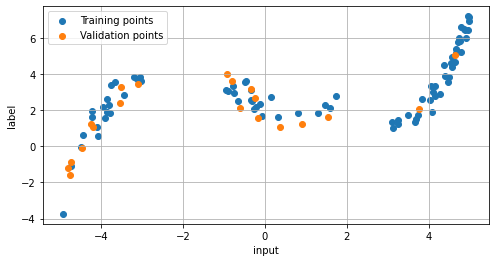

FOLD 4
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.026296615600586
AVERAGE VAL LOSS: 6.023301601409912
# EPOCH 2
AVERAGE TRAIN LOSS: 6.374399185180664
AVERAGE VAL LOSS: 3.9968128204345703
# EPOCH 3
AVERAGE TRAIN LOSS: 4.668343544006348
AVERAGE VAL LOSS: 2.838616132736206
# EPOCH 4
AVERAGE TRAIN LOSS: 4.008738994598389
AVERAGE VAL LOSS: 2.369018793106079
# EPOCH 5
AVERAGE TRAIN LOSS: 3.1354281902313232
AVERAGE VAL LOSS: 2.435817241668701
# EPOCH 6
AVERAGE TRAIN LOSS: 3.2849721908569336
AVERAGE VAL LOSS: 2.896822452545166
# EPOCH 7
AVERAGE TRAIN LOSS: 3.3588430881500244
AVERAGE VAL LOSS: 3.3970799446105957
# EPOCH 8
AVERAGE TRAIN LOSS: 3.560925006866455
AVERAGE VAL LOSS: 3.61814284324646
# EPOCH 9
AVERAGE TRAIN LOSS: 3.491851806640625
AVERAGE VAL LOSS: 3.5946507453918457
# EPOCH 10
AVERAGE TRAIN LOSS: 3.361967086791992
AVERAGE VAL LOSS: 3.4157371520996094
# EPOCH 11
AVERAGE TRAIN LOSS: 3.1412134170532227
AVERAGE VAL LOSS: 3.081087827682495
# 

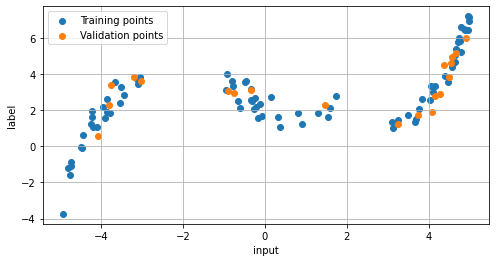

FOLD 5
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 12.330305099487305
AVERAGE VAL LOSS: 7.8375396728515625
# EPOCH 2
AVERAGE TRAIN LOSS: 7.546308517456055
AVERAGE VAL LOSS: 5.335380554199219
# EPOCH 3
AVERAGE TRAIN LOSS: 5.9431304931640625
AVERAGE VAL LOSS: 3.754812240600586
# EPOCH 4
AVERAGE TRAIN LOSS: 4.69495153427124
AVERAGE VAL LOSS: 2.8822054862976074
# EPOCH 5
AVERAGE TRAIN LOSS: 3.4044198989868164
AVERAGE VAL LOSS: 2.593127965927124
# EPOCH 6
AVERAGE TRAIN LOSS: 4.077951431274414
AVERAGE VAL LOSS: 2.716789960861206
# EPOCH 7
AVERAGE TRAIN LOSS: 3.501518726348877
AVERAGE VAL LOSS: 2.9647436141967773
# EPOCH 8
AVERAGE TRAIN LOSS: 4.189101219177246
AVERAGE VAL LOSS: 3.1782124042510986
# EPOCH 9
AVERAGE TRAIN LOSS: 4.048321723937988
AVERAGE VAL LOSS: 3.1586763858795166
# EPOCH 10
AVERAGE TRAIN LOSS: 3.581188678741455
AVERAGE VAL LOSS: 3.0104339122772217
# EPOCH 11
AVERAGE TRAIN LOSS: 3.4124066829681396
AVERAGE VAL LOSS: 2.843266725540161


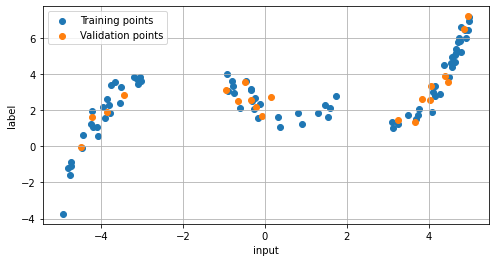

[I 2022-01-10 19:15:56,514] Trial 5 pruned. 


FOLD 1
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 10.602415084838867
AVERAGE VAL LOSS: 12.57725715637207
# EPOCH 2
AVERAGE TRAIN LOSS: 7.866352081298828
AVERAGE VAL LOSS: 9.600789070129395
# EPOCH 3
AVERAGE TRAIN LOSS: 5.492044925689697
AVERAGE VAL LOSS: 7.496387481689453
# EPOCH 4
AVERAGE TRAIN LOSS: 4.077749252319336
AVERAGE VAL LOSS: 6.1375226974487305
# EPOCH 5
AVERAGE TRAIN LOSS: 3.2925848960876465
AVERAGE VAL LOSS: 5.236827373504639
# EPOCH 6
AVERAGE TRAIN LOSS: 3.001953125
AVERAGE VAL LOSS: 4.676133155822754
# EPOCH 7
AVERAGE TRAIN LOSS: 2.816030979156494
AVERAGE VAL LOSS: 4.284113883972168
# EPOCH 8
AVERAGE TRAIN LOSS: 2.9993739128112793
AVERAGE VAL LOSS: 3.9149162769317627
# EPOCH 9
AVERAGE TRAIN LOSS: 3.104729175567627
AVERAGE VAL LOSS: 3.6152024269104004
# EPOCH 10
AVERAGE TRAIN LOSS: 3.0312952995300293
AVERAGE VAL LOSS: 3.3696980476379395
# EPOCH 11
AVERAGE TRAIN LOSS: 2.8124852180480957
AVERAGE VAL LOSS: 3.223471164703369
# EPOCH 12
AVERAGE TRAIN LOSS: 2.7174243927001953
AVERAGE VAL LOSS: 3.16590952873

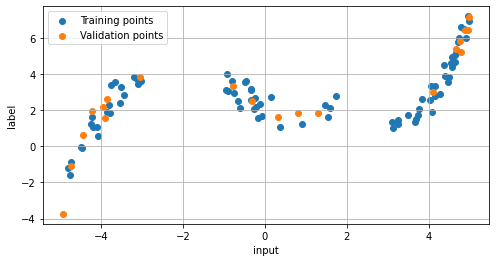

FOLD 2
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 7.8807525634765625
AVERAGE VAL LOSS: 7.636582374572754
# EPOCH 2
AVERAGE TRAIN LOSS: 6.219853401184082
AVERAGE VAL LOSS: 5.49949312210083
# EPOCH 3
AVERAGE TRAIN LOSS: 5.036606311798096
AVERAGE VAL LOSS: 3.9637818336486816
# EPOCH 4
AVERAGE TRAIN LOSS: 4.056497573852539
AVERAGE VAL LOSS: 3.0226612091064453
# EPOCH 5
AVERAGE TRAIN LOSS: 3.4893054962158203
AVERAGE VAL LOSS: 2.5654966831207275
# EPOCH 6
AVERAGE TRAIN LOSS: 3.1114320755004883
AVERAGE VAL LOSS: 2.513991355895996
# EPOCH 7
AVERAGE TRAIN LOSS: 2.955864906311035
AVERAGE VAL LOSS: 2.687544584274292
# EPOCH 8
AVERAGE TRAIN LOSS: 2.8893609046936035
AVERAGE VAL LOSS: 2.85152268409729
# EPOCH 9
AVERAGE TRAIN LOSS: 2.9848761558532715
AVERAGE VAL LOSS: 2.856053113937378
# EPOCH 10
AVERAGE TRAIN LOSS: 2.935755729675293
AVERAGE VAL LOSS: 2.725581407546997
# EPOCH 11
AVERAGE TRAIN LOSS: 2.780325412750244
AVERAGE VAL LOSS: 2.5679988861083984
# 

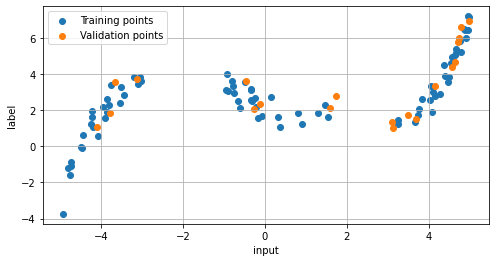

FOLD 3
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 15.249961853027344
AVERAGE VAL LOSS: 5.663365364074707
# EPOCH 2
AVERAGE TRAIN LOSS: 11.626270294189453
AVERAGE VAL LOSS: 5.118542671203613
# EPOCH 3
AVERAGE TRAIN LOSS: 8.822368621826172
AVERAGE VAL LOSS: 5.139091968536377
# EPOCH 4
AVERAGE TRAIN LOSS: 7.032892227172852
AVERAGE VAL LOSS: 5.305588245391846
# EPOCH 5
AVERAGE TRAIN LOSS: 5.562877655029297
AVERAGE VAL LOSS: 5.5174994468688965
# EPOCH 6
AVERAGE TRAIN LOSS: 4.524989604949951
AVERAGE VAL LOSS: 5.288421154022217
# EPOCH 7
AVERAGE TRAIN LOSS: 3.6152877807617188
AVERAGE VAL LOSS: 4.8468804359436035
# EPOCH 8
AVERAGE TRAIN LOSS: 2.989602565765381
AVERAGE VAL LOSS: 4.387610912322998
# EPOCH 9
AVERAGE TRAIN LOSS: 2.7747950553894043
AVERAGE VAL LOSS: 3.962902784347534
# EPOCH 10
AVERAGE TRAIN LOSS: 2.773754358291626
AVERAGE VAL LOSS: 3.599163055419922
# EPOCH 11
AVERAGE TRAIN LOSS: 2.7948756217956543
AVERAGE VAL LOSS: 3.3714516162872314
#

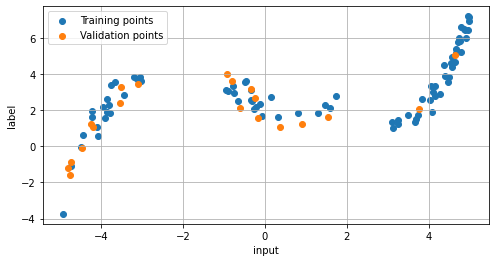

FOLD 4
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.851619720458984
AVERAGE VAL LOSS: 8.359232902526855
# EPOCH 2
AVERAGE TRAIN LOSS: 8.021585464477539
AVERAGE VAL LOSS: 5.471900463104248
# EPOCH 3
AVERAGE TRAIN LOSS: 6.288036823272705
AVERAGE VAL LOSS: 3.5245463848114014
# EPOCH 4
AVERAGE TRAIN LOSS: 5.0165863037109375
AVERAGE VAL LOSS: 2.446544647216797
# EPOCH 5
AVERAGE TRAIN LOSS: 3.788105010986328
AVERAGE VAL LOSS: 2.054516077041626
# EPOCH 6
AVERAGE TRAIN LOSS: 3.2556824684143066
AVERAGE VAL LOSS: 2.213085412979126
# EPOCH 7
AVERAGE TRAIN LOSS: 2.9563095569610596
AVERAGE VAL LOSS: 2.7217891216278076
# EPOCH 8
AVERAGE TRAIN LOSS: 2.976016044616699
AVERAGE VAL LOSS: 3.334878921508789
# EPOCH 9
AVERAGE TRAIN LOSS: 2.8510894775390625
AVERAGE VAL LOSS: 3.7988221645355225
# EPOCH 10
AVERAGE TRAIN LOSS: 3.0314459800720215
AVERAGE VAL LOSS: 3.9434967041015625
# EPOCH 11
AVERAGE TRAIN LOSS: 2.942492961883545
AVERAGE VAL LOSS: 3.847950696945190

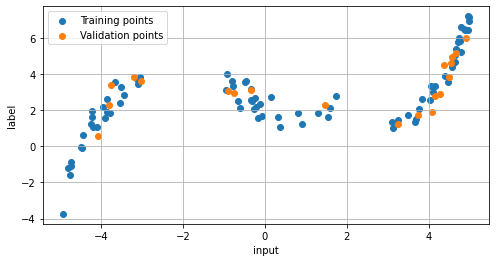

FOLD 5
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 14.847198486328125
AVERAGE VAL LOSS: 11.030740737915039
# EPOCH 2
AVERAGE TRAIN LOSS: 11.619457244873047
AVERAGE VAL LOSS: 8.366228103637695
# EPOCH 3
AVERAGE TRAIN LOSS: 9.082841873168945
AVERAGE VAL LOSS: 6.345655918121338
# EPOCH 4
AVERAGE TRAIN LOSS: 7.1719560623168945
AVERAGE VAL LOSS: 4.83624267578125
# EPOCH 5
AVERAGE TRAIN LOSS: 5.806242942810059
AVERAGE VAL LOSS: 3.7428977489471436
# EPOCH 6
AVERAGE TRAIN LOSS: 4.622659683227539
AVERAGE VAL LOSS: 3.0041921138763428
# EPOCH 7
AVERAGE TRAIN LOSS: 4.021280765533447
AVERAGE VAL LOSS: 2.5830681324005127
# EPOCH 8
AVERAGE TRAIN LOSS: 3.4583683013916016
AVERAGE VAL LOSS: 2.436964750289917
# EPOCH 9
AVERAGE TRAIN LOSS: 3.1950135231018066
AVERAGE VAL LOSS: 2.516786575317383
# EPOCH 10
AVERAGE TRAIN LOSS: 3.097733497619629
AVERAGE VAL LOSS: 2.7028298377990723
# EPOCH 11
AVERAGE TRAIN LOSS: 3.1049842834472656
AVERAGE VAL LOSS: 2.876728773117065

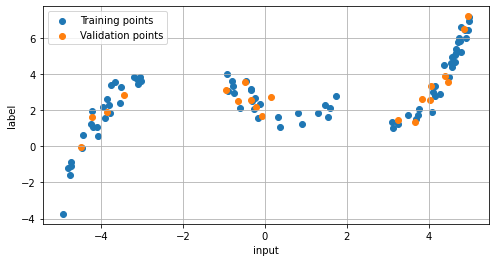

[I 2022-01-10 19:24:33,128] Trial 6 finished with value: 0.29530686140060425 and parameters: {'n_units_l0': 64, 'n_units_l1': 256, 'dropout': 0.1, 'weight_decay': 1e-05}. Best is trial 4 with value: 0.2103552371263504.


FOLD 1
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 8.744378089904785
AVERAGE VAL LOSS: 10.374200820922852
# EPOCH 2
AVERAGE TRAIN LOSS: 5.593958854675293
AVERAGE VAL LOSS: 7.580576419830322
# EPOCH 3
AVERAGE TRAIN LOSS: 3.8777008056640625
AVERAGE VAL LOSS: 5.234161376953125
# EPOCH 4
AVERAGE TRAIN LOSS: 2.8842568397521973
AVERAGE VAL LOSS: 3.777477741241455
# EPOCH 5
AVERAGE TRAIN LOSS: 2.774221658706665
AVERAGE VAL LOSS: 3.1518394947052
# EPOCH 6
AVERAGE TRAIN LOSS: 3.103224754333496
AVERAGE VAL LOSS: 2.907815933227539
# EPOCH 7
AVERAGE TRAIN LOSS: 3.1480846405029297
AVERAGE VAL LOSS: 2.7324652671813965
# EPOCH 8
AVERAGE TRAIN LOSS: 2.7366440296173096
AVERAGE VAL LOSS: 2.760887622833252
# EPOCH 9
AVERAGE TRAIN LOSS: 2.5318446159362793
AVERAGE VAL LOSS: 2.84324049949646
# EPOCH 10
AVERAGE TRAIN LOSS: 2.2486188411712646
AVERAGE VAL LOSS: 3.1223666667938232
# EPOCH 11
AVERAGE TRAIN LOSS: 2.0174527168273926
AVERAGE VAL LOSS: 3.4325668811798096
# EPOCH 12
AVERAGE TRAIN LOSS: 1.9559013843536377
AVERAGE VAL LOSS: 3.573971

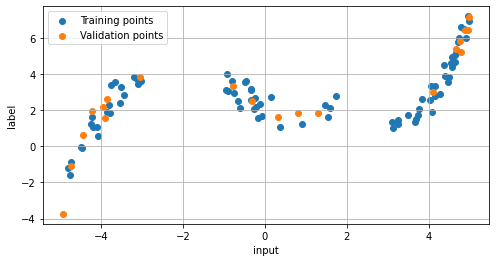

FOLD 2
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 9.449254035949707
AVERAGE VAL LOSS: 7.31386137008667
# EPOCH 2
AVERAGE TRAIN LOSS: 5.715053558349609
AVERAGE VAL LOSS: 3.6574974060058594
# EPOCH 3
AVERAGE TRAIN LOSS: 3.8286502361297607
AVERAGE VAL LOSS: 2.3267104625701904
# EPOCH 4
AVERAGE TRAIN LOSS: 3.484778881072998
AVERAGE VAL LOSS: 2.512439489364624
# EPOCH 5
AVERAGE TRAIN LOSS: 3.562592029571533
AVERAGE VAL LOSS: 3.010059356689453
# EPOCH 6
AVERAGE TRAIN LOSS: 3.746004104614258
AVERAGE VAL LOSS: 3.0818464756011963
# EPOCH 7
AVERAGE TRAIN LOSS: 3.5503334999084473
AVERAGE VAL LOSS: 2.901689052581787
# EPOCH 8
AVERAGE TRAIN LOSS: 3.014941930770874
AVERAGE VAL LOSS: 2.6757779121398926
# EPOCH 9
AVERAGE TRAIN LOSS: 2.765493392944336
AVERAGE VAL LOSS: 2.5117080211639404
# EPOCH 10
AVERAGE TRAIN LOSS: 2.6398167610168457
AVERAGE VAL LOSS: 2.433849811553955
# EPOCH 11
AVERAGE TRAIN LOSS: 2.572059154510498
AVERAGE VAL LOSS: 2.438304901123047
#

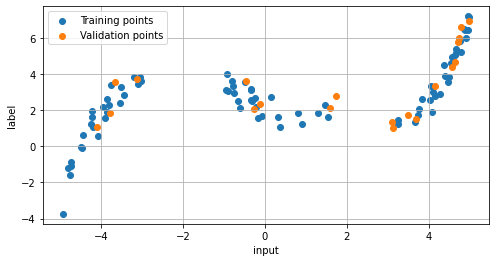

FOLD 3
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 10.995440483093262
AVERAGE VAL LOSS: 4.576371669769287
# EPOCH 2
AVERAGE TRAIN LOSS: 5.976226806640625
AVERAGE VAL LOSS: 4.912254333496094
# EPOCH 3
AVERAGE TRAIN LOSS: 3.680398941040039
AVERAGE VAL LOSS: 5.031672477722168
# EPOCH 4
AVERAGE TRAIN LOSS: 3.068960428237915
AVERAGE VAL LOSS: 4.809876918792725
# EPOCH 5
AVERAGE TRAIN LOSS: 3.4475290775299072
AVERAGE VAL LOSS: 4.393307685852051
# EPOCH 6
AVERAGE TRAIN LOSS: 3.7940611839294434
AVERAGE VAL LOSS: 3.8097381591796875
# EPOCH 7
AVERAGE TRAIN LOSS: 3.4062795639038086
AVERAGE VAL LOSS: 3.400827169418335
# EPOCH 8
AVERAGE TRAIN LOSS: 3.1646244525909424
AVERAGE VAL LOSS: 3.0824525356292725
# EPOCH 9
AVERAGE TRAIN LOSS: 2.8252296447753906
AVERAGE VAL LOSS: 2.9223053455352783
# EPOCH 10
AVERAGE TRAIN LOSS: 2.4662771224975586
AVERAGE VAL LOSS: 2.8898818492889404
# EPOCH 11
AVERAGE TRAIN LOSS: 2.484128475189209
AVERAGE VAL LOSS: 3.0450780391693

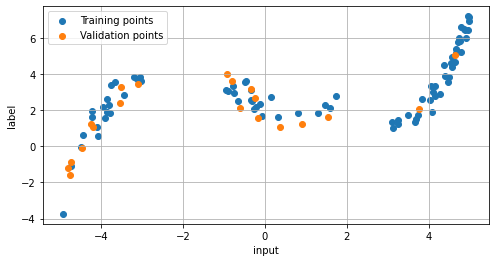

FOLD 4
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 10.908825874328613
AVERAGE VAL LOSS: 6.523221015930176
# EPOCH 2
AVERAGE TRAIN LOSS: 6.12498140335083
AVERAGE VAL LOSS: 3.2408084869384766
# EPOCH 3
AVERAGE TRAIN LOSS: 3.9973363876342773
AVERAGE VAL LOSS: 2.164600133895874
# EPOCH 4
AVERAGE TRAIN LOSS: 3.171191930770874
AVERAGE VAL LOSS: 2.775292158126831
# EPOCH 5
AVERAGE TRAIN LOSS: 3.2800145149230957
AVERAGE VAL LOSS: 3.916921377182007
# EPOCH 6
AVERAGE TRAIN LOSS: 3.228388547897339
AVERAGE VAL LOSS: 4.502429008483887
# EPOCH 7
AVERAGE TRAIN LOSS: 3.4070096015930176
AVERAGE VAL LOSS: 4.388254642486572
# EPOCH 8
AVERAGE TRAIN LOSS: 3.111926555633545
AVERAGE VAL LOSS: 3.9120171070098877
# EPOCH 9
AVERAGE TRAIN LOSS: 2.8232223987579346
AVERAGE VAL LOSS: 3.319089651107788
# EPOCH 10
AVERAGE TRAIN LOSS: 2.5692458152770996
AVERAGE VAL LOSS: 2.767507314682007
# EPOCH 11
AVERAGE TRAIN LOSS: 2.474782943725586
AVERAGE VAL LOSS: 2.3752102851867676


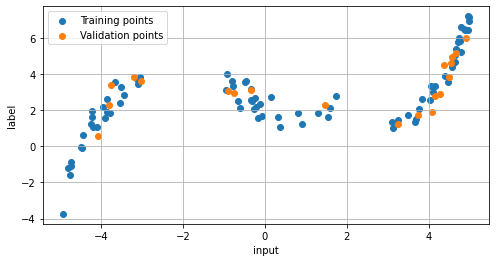

FOLD 5
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 8.586565017700195
AVERAGE VAL LOSS: 4.778689384460449
# EPOCH 2
AVERAGE TRAIN LOSS: 4.997159957885742
AVERAGE VAL LOSS: 3.1325340270996094
# EPOCH 3
AVERAGE TRAIN LOSS: 3.6737186908721924
AVERAGE VAL LOSS: 3.16108775138855
# EPOCH 4
AVERAGE TRAIN LOSS: 3.6071691513061523
AVERAGE VAL LOSS: 3.728410005569458
# EPOCH 5
AVERAGE TRAIN LOSS: 3.9277913570404053
AVERAGE VAL LOSS: 3.9756157398223877
# EPOCH 6
AVERAGE TRAIN LOSS: 3.939211368560791
AVERAGE VAL LOSS: 3.6489639282226562
# EPOCH 7
AVERAGE TRAIN LOSS: 3.649811029434204
AVERAGE VAL LOSS: 3.111948013305664
# EPOCH 8
AVERAGE TRAIN LOSS: 3.1598572731018066
AVERAGE VAL LOSS: 2.6602935791015625
# EPOCH 9
AVERAGE TRAIN LOSS: 3.0350003242492676
AVERAGE VAL LOSS: 2.3756701946258545
# EPOCH 10
AVERAGE TRAIN LOSS: 2.886382579803467
AVERAGE VAL LOSS: 2.2150681018829346
# EPOCH 11
AVERAGE TRAIN LOSS: 2.8203370571136475
AVERAGE VAL LOSS: 2.1103160381317

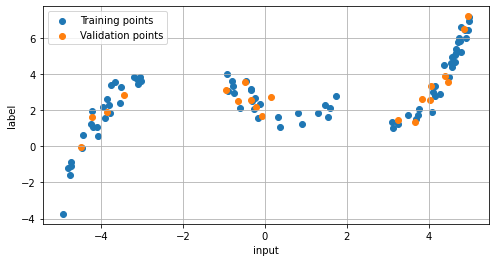

[I 2022-01-10 19:33:37,219] Trial 7 pruned. 


FOLD 1
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 10.722038269042969
AVERAGE VAL LOSS: 11.110075950622559
# EPOCH 2
AVERAGE TRAIN LOSS: 6.453543186187744
AVERAGE VAL LOSS: 8.02609920501709
# EPOCH 3
AVERAGE TRAIN LOSS: 4.476870536804199
AVERAGE VAL LOSS: 6.182971477508545
# EPOCH 4
AVERAGE TRAIN LOSS: 3.5475564002990723
AVERAGE VAL LOSS: 4.857390403747559
# EPOCH 5
AVERAGE TRAIN LOSS: 3.2923176288604736
AVERAGE VAL LOSS: 4.154033184051514
# EPOCH 6
AVERAGE TRAIN LOSS: 3.522451877593994
AVERAGE VAL LOSS: 3.680647373199463
# EPOCH 7
AVERAGE TRAIN LOSS: 3.611534833908081
AVERAGE VAL LOSS: 3.334975481033325
# EPOCH 8
AVERAGE TRAIN LOSS: 3.4685323238372803
AVERAGE VAL LOSS: 3.070732831954956
# EPOCH 9
AVERAGE TRAIN LOSS: 2.8458614349365234
AVERAGE VAL LOSS: 3.0672473907470703
# EPOCH 10
AVERAGE TRAIN LOSS: 2.676520586013794
AVERAGE VAL LOSS: 3.1830201148986816
# EPOCH 11
AVERAGE TRAIN LOSS: 2.694195508956909
AVERAGE VAL LOSS: 3.4026525020599365
# EPOCH 12
AVERAGE TRAIN LOSS: 2.497197151184082
AVERAGE VAL LOSS: 3.6479840

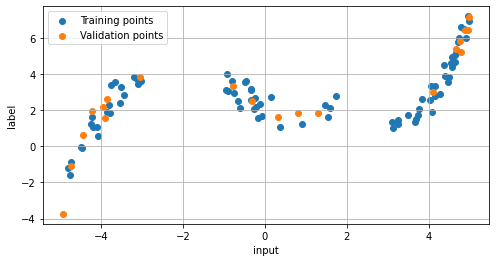

FOLD 2
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 10.16061782836914
AVERAGE VAL LOSS: 9.058253288269043
# EPOCH 2
AVERAGE TRAIN LOSS: 7.03836727142334
AVERAGE VAL LOSS: 5.717257976531982
# EPOCH 3
AVERAGE TRAIN LOSS: 5.586565017700195
AVERAGE VAL LOSS: 3.6677041053771973
# EPOCH 4
AVERAGE TRAIN LOSS: 4.003144264221191
AVERAGE VAL LOSS: 2.6099510192871094
# EPOCH 5
AVERAGE TRAIN LOSS: 3.2549757957458496
AVERAGE VAL LOSS: 2.3434605598449707
# EPOCH 6
AVERAGE TRAIN LOSS: 3.2000973224639893
AVERAGE VAL LOSS: 2.5684051513671875
# EPOCH 7
AVERAGE TRAIN LOSS: 3.2393503189086914
AVERAGE VAL LOSS: 2.964735746383667
# EPOCH 8
AVERAGE TRAIN LOSS: 3.448537588119507
AVERAGE VAL LOSS: 3.0697641372680664
# EPOCH 9
AVERAGE TRAIN LOSS: 3.4232521057128906
AVERAGE VAL LOSS: 2.9046828746795654
# EPOCH 10
AVERAGE TRAIN LOSS: 2.983745574951172
AVERAGE VAL LOSS: 2.592456579208374
# EPOCH 11
AVERAGE TRAIN LOSS: 3.0541415214538574
AVERAGE VAL LOSS: 2.31764388084411

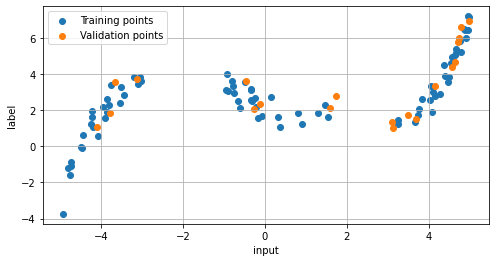

FOLD 3
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 11.950140953063965
AVERAGE VAL LOSS: 4.889448642730713
# EPOCH 2
AVERAGE TRAIN LOSS: 7.011305332183838
AVERAGE VAL LOSS: 4.525625228881836
# EPOCH 3
AVERAGE TRAIN LOSS: 4.202664375305176
AVERAGE VAL LOSS: 4.725404262542725
# EPOCH 4
AVERAGE TRAIN LOSS: 3.3479223251342773
AVERAGE VAL LOSS: 4.953737735748291
# EPOCH 5
AVERAGE TRAIN LOSS: 3.776043176651001
AVERAGE VAL LOSS: 4.9576640129089355
# EPOCH 6
AVERAGE TRAIN LOSS: 4.113901615142822
AVERAGE VAL LOSS: 4.605391025543213
# EPOCH 7
AVERAGE TRAIN LOSS: 3.67694091796875
AVERAGE VAL LOSS: 4.124917984008789
# EPOCH 8
AVERAGE TRAIN LOSS: 3.71224045753479
AVERAGE VAL LOSS: 3.6867196559906006
# EPOCH 9
AVERAGE TRAIN LOSS: 3.129490852355957
AVERAGE VAL LOSS: 3.352900266647339
# EPOCH 10
AVERAGE TRAIN LOSS: 3.0111305713653564
AVERAGE VAL LOSS: 3.1378026008605957
# EPOCH 11
AVERAGE TRAIN LOSS: 2.576897621154785
AVERAGE VAL LOSS: 3.058192014694214
# EP

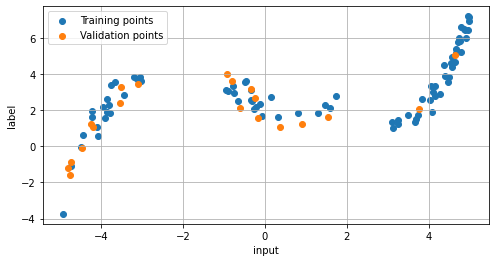

FOLD 4
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 9.233184814453125
AVERAGE VAL LOSS: 5.722909450531006
# EPOCH 2
AVERAGE TRAIN LOSS: 5.819735527038574
AVERAGE VAL LOSS: 2.925015687942505
# EPOCH 3
AVERAGE TRAIN LOSS: 4.423753261566162
AVERAGE VAL LOSS: 2.086824893951416
# EPOCH 4
AVERAGE TRAIN LOSS: 3.3368124961853027
AVERAGE VAL LOSS: 2.518612861633301
# EPOCH 5
AVERAGE TRAIN LOSS: 3.5710151195526123
AVERAGE VAL LOSS: 3.41548228263855
# EPOCH 6
AVERAGE TRAIN LOSS: 3.0511488914489746
AVERAGE VAL LOSS: 4.103801250457764
# EPOCH 7
AVERAGE TRAIN LOSS: 3.2361860275268555
AVERAGE VAL LOSS: 4.2525153160095215
# EPOCH 8
AVERAGE TRAIN LOSS: 3.1234755516052246
AVERAGE VAL LOSS: 3.9153385162353516
# EPOCH 9
AVERAGE TRAIN LOSS: 3.069669723510742
AVERAGE VAL LOSS: 3.3493027687072754
# EPOCH 10
AVERAGE TRAIN LOSS: 2.952300548553467
AVERAGE VAL LOSS: 2.7891592979431152
# EPOCH 11
AVERAGE TRAIN LOSS: 2.5249528884887695
AVERAGE VAL LOSS: 2.306779384613037

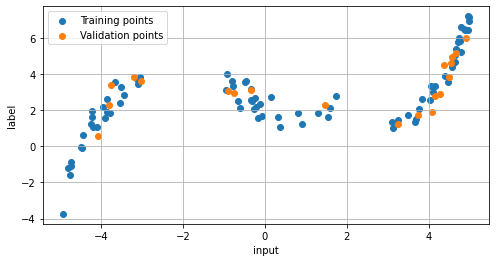

FOLD 5
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 10.281149864196777
AVERAGE VAL LOSS: 5.996558666229248
# EPOCH 2
AVERAGE TRAIN LOSS: 6.488116264343262
AVERAGE VAL LOSS: 3.568662405014038
# EPOCH 3
AVERAGE TRAIN LOSS: 4.350240707397461
AVERAGE VAL LOSS: 2.5216264724731445
# EPOCH 4
AVERAGE TRAIN LOSS: 3.304269313812256
AVERAGE VAL LOSS: 2.4681951999664307
# EPOCH 5
AVERAGE TRAIN LOSS: 3.301617383956909
AVERAGE VAL LOSS: 2.8819520473480225
# EPOCH 6
AVERAGE TRAIN LOSS: 3.5694451332092285
AVERAGE VAL LOSS: 3.1794660091400146
# EPOCH 7
AVERAGE TRAIN LOSS: 3.3470664024353027
AVERAGE VAL LOSS: 3.1238648891448975
# EPOCH 8
AVERAGE TRAIN LOSS: 3.6844663619995117
AVERAGE VAL LOSS: 2.817495107650757
# EPOCH 9
AVERAGE TRAIN LOSS: 2.860111713409424
AVERAGE VAL LOSS: 2.451742172241211
# EPOCH 10
AVERAGE TRAIN LOSS: 3.31723690032959
AVERAGE VAL LOSS: 2.1604418754577637
# EPOCH 11
AVERAGE TRAIN LOSS: 2.6864800453186035
AVERAGE VAL LOSS: 1.9505695104599


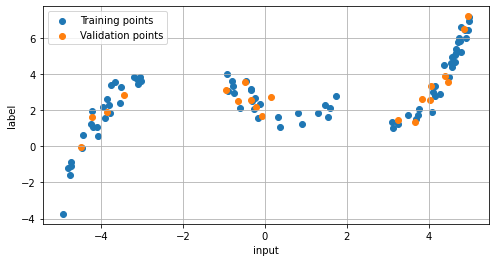

[I 2022-01-10 19:43:01,932] Trial 8 finished with value: 0.2582131028175354 and parameters: {'n_units_l0': 128, 'n_units_l1': 256, 'dropout': 0.5, 'weight_decay': 0.0001}. Best is trial 4 with value: 0.2103552371263504.


FOLD 1
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 9.114503860473633
AVERAGE VAL LOSS: 10.245960235595703
# EPOCH 2
AVERAGE TRAIN LOSS: 5.737229347229004
AVERAGE VAL LOSS: 8.00416088104248
# EPOCH 3
AVERAGE TRAIN LOSS: 4.051713466644287
AVERAGE VAL LOSS: 6.048277854919434
# EPOCH 4
AVERAGE TRAIN LOSS: 3.1947436332702637
AVERAGE VAL LOSS: 4.413156986236572
# EPOCH 5
AVERAGE TRAIN LOSS: 2.6556191444396973
AVERAGE VAL LOSS: 3.560582399368286
# EPOCH 6
AVERAGE TRAIN LOSS: 2.770771026611328
AVERAGE VAL LOSS: 3.1276400089263916
# EPOCH 7
AVERAGE TRAIN LOSS: 2.916215658187866
AVERAGE VAL LOSS: 2.8670530319213867
# EPOCH 8
AVERAGE TRAIN LOSS: 3.0606813430786133
AVERAGE VAL LOSS: 2.7582335472106934
# EPOCH 9
AVERAGE TRAIN LOSS: 2.610339641571045
AVERAGE VAL LOSS: 2.8919081687927246
# EPOCH 10
AVERAGE TRAIN LOSS: 2.3852860927581787
AVERAGE VAL LOSS: 3.118398427963257
# EPOCH 11
AVERAGE TRAIN LOSS: 2.244896650314331
AVERAGE VAL LOSS: 3.4970390796661377
# EPOCH 12
AVERAGE TRAIN LOSS: 2.162600517272949
AVERAGE VAL LOSS: 3.862232

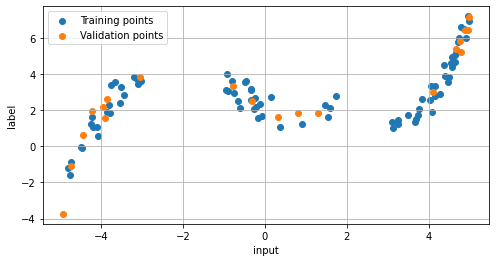

FOLD 2
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.890963554382324
AVERAGE VAL LOSS: 8.044074058532715
# EPOCH 2
AVERAGE TRAIN LOSS: 6.242294788360596
AVERAGE VAL LOSS: 4.516549587249756
# EPOCH 3
AVERAGE TRAIN LOSS: 4.067566394805908
AVERAGE VAL LOSS: 2.842089891433716
# EPOCH 4
AVERAGE TRAIN LOSS: 3.2186548709869385
AVERAGE VAL LOSS: 2.5465621948242188
# EPOCH 5
AVERAGE TRAIN LOSS: 3.107504367828369
AVERAGE VAL LOSS: 3.0064282417297363
# EPOCH 6
AVERAGE TRAIN LOSS: 3.2731821537017822
AVERAGE VAL LOSS: 3.2562763690948486
# EPOCH 7
AVERAGE TRAIN LOSS: 3.335191249847412
AVERAGE VAL LOSS: 3.142423391342163
# EPOCH 8
AVERAGE TRAIN LOSS: 3.0968856811523438
AVERAGE VAL LOSS: 2.7711668014526367
# EPOCH 9
AVERAGE TRAIN LOSS: 2.6180551052093506
AVERAGE VAL LOSS: 2.4052574634552
# EPOCH 10
AVERAGE TRAIN LOSS: 2.48725962638855
AVERAGE VAL LOSS: 2.1710124015808105
# EPOCH 11
AVERAGE TRAIN LOSS: 2.308760404586792
AVERAGE VAL LOSS: 2.1730904579162598
# 

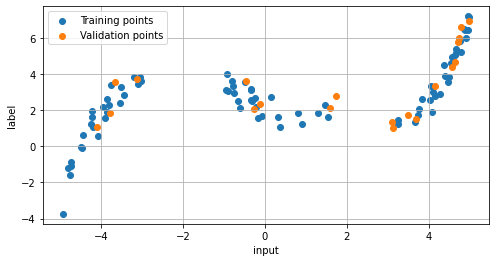

FOLD 3
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 12.643850326538086
AVERAGE VAL LOSS: 4.684554100036621
# EPOCH 2
AVERAGE TRAIN LOSS: 6.7498273849487305
AVERAGE VAL LOSS: 4.767197132110596
# EPOCH 3
AVERAGE TRAIN LOSS: 4.4337568283081055
AVERAGE VAL LOSS: 5.043456554412842
# EPOCH 4
AVERAGE TRAIN LOSS: 3.1383233070373535
AVERAGE VAL LOSS: 5.198360443115234
# EPOCH 5
AVERAGE TRAIN LOSS: 2.996420383453369
AVERAGE VAL LOSS: 4.610561847686768
# EPOCH 6
AVERAGE TRAIN LOSS: 3.193834066390991
AVERAGE VAL LOSS: 4.00942850112915
# EPOCH 7
AVERAGE TRAIN LOSS: 3.346536159515381
AVERAGE VAL LOSS: 3.5200860500335693
# EPOCH 8
AVERAGE TRAIN LOSS: 3.2984113693237305
AVERAGE VAL LOSS: 3.186105966567993
# EPOCH 9
AVERAGE TRAIN LOSS: 2.9714245796203613
AVERAGE VAL LOSS: 2.95741868019104
# EPOCH 10
AVERAGE TRAIN LOSS: 2.7812037467956543
AVERAGE VAL LOSS: 2.8532707691192627
# EPOCH 11
AVERAGE TRAIN LOSS: 2.4033303260803223
AVERAGE VAL LOSS: 2.8804333209991455


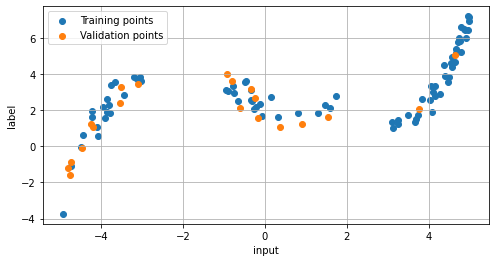

FOLD 4
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 11.592862129211426
AVERAGE VAL LOSS: 7.483947277069092
# EPOCH 2
AVERAGE TRAIN LOSS: 7.9406585693359375
AVERAGE VAL LOSS: 4.12039852142334
# EPOCH 3
AVERAGE TRAIN LOSS: 4.8932390213012695
AVERAGE VAL LOSS: 2.6357407569885254
# EPOCH 4
AVERAGE TRAIN LOSS: 3.4447996616363525
AVERAGE VAL LOSS: 2.700838327407837
# EPOCH 5
AVERAGE TRAIN LOSS: 2.8049192428588867
AVERAGE VAL LOSS: 3.6318325996398926
# EPOCH 6
AVERAGE TRAIN LOSS: 3.1732523441314697
AVERAGE VAL LOSS: 4.40510368347168
# EPOCH 7
AVERAGE TRAIN LOSS: 3.298556089401245
AVERAGE VAL LOSS: 4.658542156219482
# EPOCH 8
AVERAGE TRAIN LOSS: 3.1890926361083984
AVERAGE VAL LOSS: 4.2664794921875
# EPOCH 9
AVERAGE TRAIN LOSS: 2.9945836067199707
AVERAGE VAL LOSS: 3.5347869396209717
# EPOCH 10
AVERAGE TRAIN LOSS: 2.609936237335205
AVERAGE VAL LOSS: 2.8354909420013428
# EPOCH 11
AVERAGE TRAIN LOSS: 2.4618592262268066
AVERAGE VAL LOSS: 2.3638832569122314

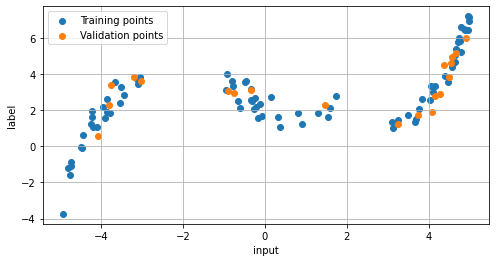

FOLD 5
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.25642204284668
AVERAGE VAL LOSS: 4.0290937423706055
# EPOCH 2
AVERAGE TRAIN LOSS: 4.571859836578369
AVERAGE VAL LOSS: 2.5625929832458496
# EPOCH 3
AVERAGE TRAIN LOSS: 3.347850799560547
AVERAGE VAL LOSS: 2.986344814300537
# EPOCH 4
AVERAGE TRAIN LOSS: 3.224607467651367
AVERAGE VAL LOSS: 3.6666061878204346
# EPOCH 5
AVERAGE TRAIN LOSS: 3.766667366027832
AVERAGE VAL LOSS: 3.6147868633270264
# EPOCH 6
AVERAGE TRAIN LOSS: 3.5173192024230957
AVERAGE VAL LOSS: 3.069157361984253
# EPOCH 7
AVERAGE TRAIN LOSS: 3.058896541595459
AVERAGE VAL LOSS: 2.4666202068328857
# EPOCH 8
AVERAGE TRAIN LOSS: 2.6749372482299805
AVERAGE VAL LOSS: 2.081329107284546
# EPOCH 9
AVERAGE TRAIN LOSS: 2.682819366455078
AVERAGE VAL LOSS: 1.9132953882217407
# EPOCH 10
AVERAGE TRAIN LOSS: 2.746211528778076
AVERAGE VAL LOSS: 1.8585232496261597
# EPOCH 11
AVERAGE TRAIN LOSS: 2.607191801071167
AVERAGE VAL LOSS: 1.8066437244415283


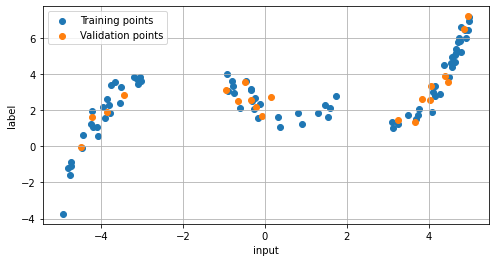

[I 2022-01-10 19:52:53,749] Trial 9 finished with value: 0.25260475277900696 and parameters: {'n_units_l0': 128, 'n_units_l1': 256, 'dropout': 0.1, 'weight_decay': 1e-05}. Best is trial 4 with value: 0.2103552371263504.


FOLD 1
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 9.531380653381348
AVERAGE VAL LOSS: 11.226434707641602
# EPOCH 2
AVERAGE TRAIN LOSS: 7.014432907104492
AVERAGE VAL LOSS: 8.763813018798828
# EPOCH 3
AVERAGE TRAIN LOSS: 5.47966194152832
AVERAGE VAL LOSS: 6.963382244110107
# EPOCH 4
AVERAGE TRAIN LOSS: 3.9937868118286133
AVERAGE VAL LOSS: 5.771613121032715
# EPOCH 5
AVERAGE TRAIN LOSS: 3.4583449363708496
AVERAGE VAL LOSS: 4.991044044494629
# EPOCH 6
AVERAGE TRAIN LOSS: 2.917698621749878
AVERAGE VAL LOSS: 4.486251354217529
# EPOCH 7
AVERAGE TRAIN LOSS: 2.9383585453033447
AVERAGE VAL LOSS: 4.102358341217041
# EPOCH 8
AVERAGE TRAIN LOSS: 3.5165233612060547
AVERAGE VAL LOSS: 3.8083736896514893
# EPOCH 9
AVERAGE TRAIN LOSS: 3.2937426567077637
AVERAGE VAL LOSS: 3.466695785522461
# EPOCH 10
AVERAGE TRAIN LOSS: 2.8834776878356934
AVERAGE VAL LOSS: 3.2173402309417725
# EPOCH 11
AVERAGE TRAIN LOSS: 3.244839668273926
AVERAGE VAL LOSS: 3.1003270149230957
# EPOCH 12
AVERAGE TRAIN LOSS: 2.7480854988098145
AVERAGE VAL LOSS: 3.09134

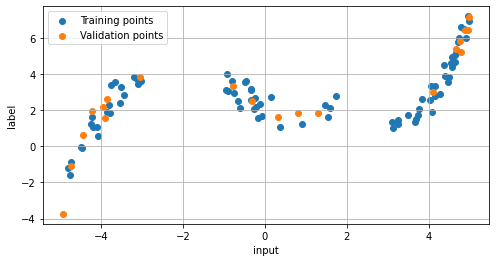

FOLD 2
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.625597953796387
AVERAGE VAL LOSS: 9.715539932250977
# EPOCH 2
AVERAGE TRAIN LOSS: 7.648474216461182
AVERAGE VAL LOSS: 7.064723491668701
# EPOCH 3
AVERAGE TRAIN LOSS: 6.1222124099731445
AVERAGE VAL LOSS: 5.0429816246032715
# EPOCH 4
AVERAGE TRAIN LOSS: 4.6698527336120605
AVERAGE VAL LOSS: 3.635234832763672
# EPOCH 5
AVERAGE TRAIN LOSS: 3.9482574462890625
AVERAGE VAL LOSS: 2.7636802196502686
# EPOCH 6
AVERAGE TRAIN LOSS: 3.252042770385742
AVERAGE VAL LOSS: 2.429950714111328
# EPOCH 7
AVERAGE TRAIN LOSS: 3.314622163772583
AVERAGE VAL LOSS: 2.492168426513672
# EPOCH 8
AVERAGE TRAIN LOSS: 3.2764248847961426
AVERAGE VAL LOSS: 2.726719379425049
# EPOCH 9
AVERAGE TRAIN LOSS: 3.1562461853027344
AVERAGE VAL LOSS: 2.8645894527435303
# EPOCH 10
AVERAGE TRAIN LOSS: 3.204926013946533
AVERAGE VAL LOSS: 2.865450620651245
# EPOCH 11
AVERAGE TRAIN LOSS: 3.1799392700195312
AVERAGE VAL LOSS: 2.7105143070220947

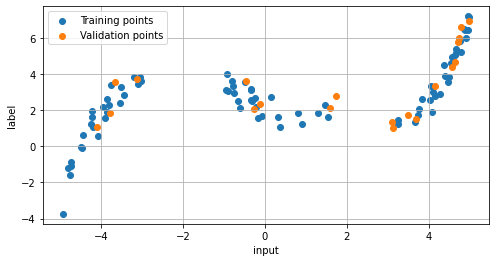

FOLD 3
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 13.776886940002441
AVERAGE VAL LOSS: 5.110832214355469
# EPOCH 2
AVERAGE TRAIN LOSS: 9.081786155700684
AVERAGE VAL LOSS: 4.420784950256348
# EPOCH 3
AVERAGE TRAIN LOSS: 6.303711891174316
AVERAGE VAL LOSS: 4.222082614898682
# EPOCH 4
AVERAGE TRAIN LOSS: 4.693868637084961
AVERAGE VAL LOSS: 4.256606578826904
# EPOCH 5
AVERAGE TRAIN LOSS: 3.51351261138916
AVERAGE VAL LOSS: 4.44636869430542
# EPOCH 6
AVERAGE TRAIN LOSS: 3.0048446655273438
AVERAGE VAL LOSS: 4.655168056488037
# EPOCH 7
AVERAGE TRAIN LOSS: 3.2445907592773438
AVERAGE VAL LOSS: 4.739974498748779
# EPOCH 8
AVERAGE TRAIN LOSS: 3.463611602783203
AVERAGE VAL LOSS: 4.679030895233154
# EPOCH 9
AVERAGE TRAIN LOSS: 3.5282697677612305
AVERAGE VAL LOSS: 4.443657875061035
# EPOCH 10
AVERAGE TRAIN LOSS: 4.056837558746338
AVERAGE VAL LOSS: 4.04735803604126
# EPOCH 11
AVERAGE TRAIN LOSS: 3.2796969413757324
AVERAGE VAL LOSS: 3.692700147628784
# EPOCH

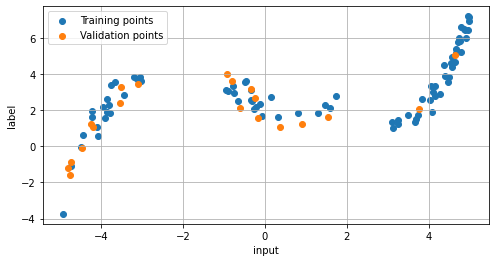

FOLD 4
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.05705738067627
AVERAGE VAL LOSS: 5.421144008636475
# EPOCH 2
AVERAGE TRAIN LOSS: 5.679049968719482
AVERAGE VAL LOSS: 3.364872455596924
# EPOCH 3
AVERAGE TRAIN LOSS: 4.295854568481445
AVERAGE VAL LOSS: 2.397798538208008
# EPOCH 4
AVERAGE TRAIN LOSS: 3.68825101852417
AVERAGE VAL LOSS: 2.3713178634643555
# EPOCH 5
AVERAGE TRAIN LOSS: 3.8401641845703125
AVERAGE VAL LOSS: 2.844308853149414
# EPOCH 6
AVERAGE TRAIN LOSS: 3.2655091285705566
AVERAGE VAL LOSS: 3.3509693145751953
# EPOCH 7
AVERAGE TRAIN LOSS: 3.4863219261169434
AVERAGE VAL LOSS: 3.563068151473999
# EPOCH 8
AVERAGE TRAIN LOSS: 3.174201011657715
AVERAGE VAL LOSS: 3.5827343463897705
# EPOCH 9
AVERAGE TRAIN LOSS: 3.344294548034668
AVERAGE VAL LOSS: 3.3623435497283936
# EPOCH 10
AVERAGE TRAIN LOSS: 2.9237489700317383
AVERAGE VAL LOSS: 3.059192657470703
# EPOCH 11
AVERAGE TRAIN LOSS: 2.555752754211426
AVERAGE VAL LOSS: 2.755948066711426
# E

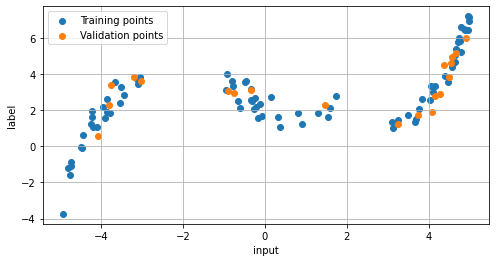

FOLD 5
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.926047325134277
AVERAGE VAL LOSS: 7.266429424285889
# EPOCH 2
AVERAGE TRAIN LOSS: 7.602214813232422
AVERAGE VAL LOSS: 5.470503330230713
# EPOCH 3
AVERAGE TRAIN LOSS: 6.506163597106934
AVERAGE VAL LOSS: 4.143556118011475
# EPOCH 4
AVERAGE TRAIN LOSS: 5.069689750671387
AVERAGE VAL LOSS: 3.224543809890747
# EPOCH 5
AVERAGE TRAIN LOSS: 4.047095775604248
AVERAGE VAL LOSS: 2.6686322689056396
# EPOCH 6
AVERAGE TRAIN LOSS: 3.828545093536377
AVERAGE VAL LOSS: 2.427271604537964
# EPOCH 7
AVERAGE TRAIN LOSS: 3.5140533447265625
AVERAGE VAL LOSS: 2.4485421180725098
# EPOCH 8
AVERAGE TRAIN LOSS: 2.9758973121643066
AVERAGE VAL LOSS: 2.621387004852295
# EPOCH 9
AVERAGE TRAIN LOSS: 3.3481550216674805
AVERAGE VAL LOSS: 2.804619550704956
# EPOCH 10
AVERAGE TRAIN LOSS: 3.6229372024536133
AVERAGE VAL LOSS: 2.8878889083862305
# EPOCH 11
AVERAGE TRAIN LOSS: 3.011051654815674
AVERAGE VAL LOSS: 2.8459784984588623


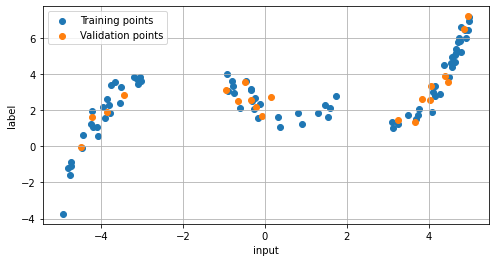

[I 2022-01-10 20:03:04,865] Trial 10 pruned. 


FOLD 1
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 10.775453567504883
AVERAGE VAL LOSS: 12.105565071105957
# EPOCH 2
AVERAGE TRAIN LOSS: 7.637428283691406
AVERAGE VAL LOSS: 9.576144218444824
# EPOCH 3
AVERAGE TRAIN LOSS: 5.501842021942139
AVERAGE VAL LOSS: 7.752875804901123
# EPOCH 4
AVERAGE TRAIN LOSS: 4.327232360839844
AVERAGE VAL LOSS: 6.453656196594238
# EPOCH 5
AVERAGE TRAIN LOSS: 3.4358932971954346
AVERAGE VAL LOSS: 5.507813930511475
# EPOCH 6
AVERAGE TRAIN LOSS: 3.1573586463928223
AVERAGE VAL LOSS: 4.7069525718688965
# EPOCH 7
AVERAGE TRAIN LOSS: 2.7038044929504395
AVERAGE VAL LOSS: 4.134897708892822
# EPOCH 8
AVERAGE TRAIN LOSS: 2.7037129402160645
AVERAGE VAL LOSS: 3.743579149246216
# EPOCH 9
AVERAGE TRAIN LOSS: 2.682149648666382
AVERAGE VAL LOSS: 3.427137851715088
# EPOCH 10
AVERAGE TRAIN LOSS: 2.8975701332092285
AVERAGE VAL LOSS: 3.1891591548919678
# EPOCH 11
AVERAGE TRAIN LOSS: 3.2722206115722656
AVERAGE VAL LOSS: 3.0414817333221436
# EPOCH 12
AVERAGE TRAIN LOSS: 3.0225963592529297
AVERAGE VAL LOSS: 2.913

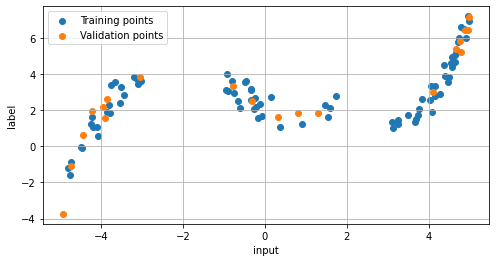

FOLD 2
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 11.519850730895996
AVERAGE VAL LOSS: 11.462286949157715
# EPOCH 2
AVERAGE TRAIN LOSS: 8.743309020996094
AVERAGE VAL LOSS: 8.451820373535156
# EPOCH 3
AVERAGE TRAIN LOSS: 7.226351737976074
AVERAGE VAL LOSS: 6.177204132080078
# EPOCH 4
AVERAGE TRAIN LOSS: 5.653353691101074
AVERAGE VAL LOSS: 4.540618896484375
# EPOCH 5
AVERAGE TRAIN LOSS: 4.706176280975342
AVERAGE VAL LOSS: 3.450491428375244
# EPOCH 6
AVERAGE TRAIN LOSS: 4.248610973358154
AVERAGE VAL LOSS: 2.787778615951538
# EPOCH 7
AVERAGE TRAIN LOSS: 4.0529890060424805
AVERAGE VAL LOSS: 2.5502123832702637
# EPOCH 8
AVERAGE TRAIN LOSS: 3.745948314666748
AVERAGE VAL LOSS: 2.6044137477874756
# EPOCH 9
AVERAGE TRAIN LOSS: 3.868475914001465
AVERAGE VAL LOSS: 2.7553486824035645
# EPOCH 10
AVERAGE TRAIN LOSS: 3.2296929359436035
AVERAGE VAL LOSS: 2.8680927753448486
# EPOCH 11
AVERAGE TRAIN LOSS: 3.7314980030059814
AVERAGE VAL LOSS: 2.922895193099975

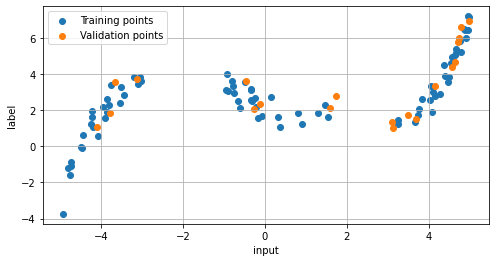

FOLD 3
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 12.223045349121094
AVERAGE VAL LOSS: 5.050573825836182
# EPOCH 2
AVERAGE TRAIN LOSS: 8.287830352783203
AVERAGE VAL LOSS: 4.412230968475342
# EPOCH 3
AVERAGE TRAIN LOSS: 5.749392509460449
AVERAGE VAL LOSS: 4.232266426086426
# EPOCH 4
AVERAGE TRAIN LOSS: 4.632137298583984
AVERAGE VAL LOSS: 4.381385803222656
# EPOCH 5
AVERAGE TRAIN LOSS: 3.5966200828552246
AVERAGE VAL LOSS: 4.62835693359375
# EPOCH 6
AVERAGE TRAIN LOSS: 3.586756706237793
AVERAGE VAL LOSS: 4.876786708831787
# EPOCH 7
AVERAGE TRAIN LOSS: 3.3273916244506836
AVERAGE VAL LOSS: 4.988023281097412
# EPOCH 8
AVERAGE TRAIN LOSS: 3.5332789421081543
AVERAGE VAL LOSS: 4.9275221824646
# EPOCH 9
AVERAGE TRAIN LOSS: 4.0766472816467285
AVERAGE VAL LOSS: 4.685031414031982
# EPOCH 10
AVERAGE TRAIN LOSS: 3.656102180480957
AVERAGE VAL LOSS: 4.4064412117004395
# EPOCH 11
AVERAGE TRAIN LOSS: 3.2210474014282227
AVERAGE VAL LOSS: 4.076179027557373
# EP

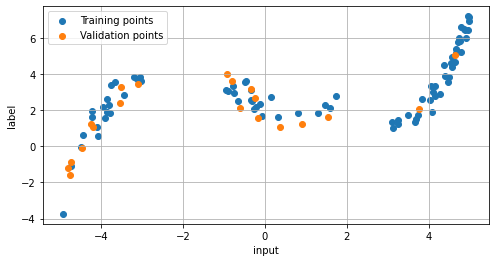

FOLD 4
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 13.988287925720215
AVERAGE VAL LOSS: 11.85197639465332
# EPOCH 2
AVERAGE TRAIN LOSS: 10.519478797912598
AVERAGE VAL LOSS: 8.605536460876465
# EPOCH 3
AVERAGE TRAIN LOSS: 8.409388542175293
AVERAGE VAL LOSS: 6.135199069976807
# EPOCH 4
AVERAGE TRAIN LOSS: 6.633803367614746
AVERAGE VAL LOSS: 4.333352565765381
# EPOCH 5
AVERAGE TRAIN LOSS: 5.325347423553467
AVERAGE VAL LOSS: 3.129758834838867
# EPOCH 6
AVERAGE TRAIN LOSS: 5.033019542694092
AVERAGE VAL LOSS: 2.4516513347625732
# EPOCH 7
AVERAGE TRAIN LOSS: 3.7180895805358887
AVERAGE VAL LOSS: 2.2462258338928223
# EPOCH 8
AVERAGE TRAIN LOSS: 3.606128215789795
AVERAGE VAL LOSS: 2.3689942359924316
# EPOCH 9
AVERAGE TRAIN LOSS: 3.351602554321289
AVERAGE VAL LOSS: 2.734497308731079
# EPOCH 10
AVERAGE TRAIN LOSS: 3.678316831588745
AVERAGE VAL LOSS: 3.17020320892334
# EPOCH 11
AVERAGE TRAIN LOSS: 3.522263765335083
AVERAGE VAL LOSS: 3.5105278491973877
# 

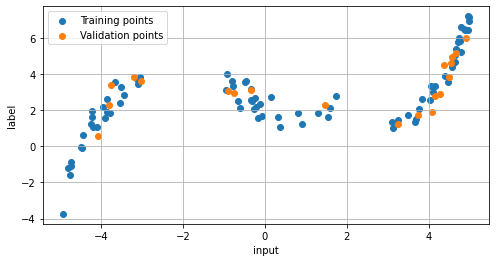

FOLD 5
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 8.85288143157959
AVERAGE VAL LOSS: 6.050297737121582
# EPOCH 2
AVERAGE TRAIN LOSS: 6.453204154968262
AVERAGE VAL LOSS: 4.199582099914551
# EPOCH 3
AVERAGE TRAIN LOSS: 4.999385833740234
AVERAGE VAL LOSS: 3.1303136348724365
# EPOCH 4
AVERAGE TRAIN LOSS: 4.166614055633545
AVERAGE VAL LOSS: 2.7356162071228027
# EPOCH 5
AVERAGE TRAIN LOSS: 3.572429656982422
AVERAGE VAL LOSS: 2.751896858215332
# EPOCH 6
AVERAGE TRAIN LOSS: 3.944988965988159
AVERAGE VAL LOSS: 2.924590826034546
# EPOCH 7
AVERAGE TRAIN LOSS: 4.048941612243652
AVERAGE VAL LOSS: 3.0556323528289795
# EPOCH 8
AVERAGE TRAIN LOSS: 3.4655280113220215
AVERAGE VAL LOSS: 3.0853118896484375
# EPOCH 9
AVERAGE TRAIN LOSS: 3.1687171459198
AVERAGE VAL LOSS: 3.023319959640503
# EPOCH 10
AVERAGE TRAIN LOSS: 3.596733331680298
AVERAGE VAL LOSS: 2.9068896770477295
# EPOCH 11
AVERAGE TRAIN LOSS: 3.3393478393554688
AVERAGE VAL LOSS: 2.750462770462036
# EP

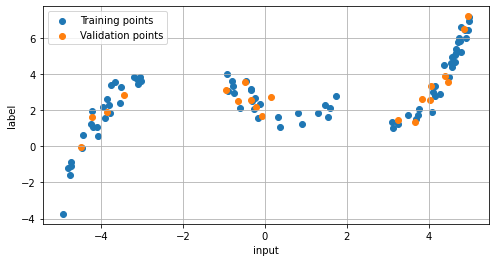

[I 2022-01-10 20:13:29,234] Trial 11 pruned. 


FOLD 1
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 8.849123001098633
AVERAGE VAL LOSS: 10.26432991027832
# EPOCH 2
AVERAGE TRAIN LOSS: 6.768766403198242
AVERAGE VAL LOSS: 7.754605770111084
# EPOCH 3
AVERAGE TRAIN LOSS: 4.1791276931762695
AVERAGE VAL LOSS: 6.050489902496338
# EPOCH 4
AVERAGE TRAIN LOSS: 3.38218355178833
AVERAGE VAL LOSS: 4.796968936920166
# EPOCH 5
AVERAGE TRAIN LOSS: 3.374016046524048
AVERAGE VAL LOSS: 3.996721029281616
# EPOCH 6
AVERAGE TRAIN LOSS: 2.950976610183716
AVERAGE VAL LOSS: 3.4404842853546143
# EPOCH 7
AVERAGE TRAIN LOSS: 3.382894992828369
AVERAGE VAL LOSS: 3.1086480617523193
# EPOCH 8
AVERAGE TRAIN LOSS: 3.465087890625
AVERAGE VAL LOSS: 2.9007530212402344
# EPOCH 9
AVERAGE TRAIN LOSS: 3.03955340385437
AVERAGE VAL LOSS: 2.8302078247070312
# EPOCH 10
AVERAGE TRAIN LOSS: 2.8293728828430176
AVERAGE VAL LOSS: 2.9478647708892822
# EPOCH 11
AVERAGE TRAIN LOSS: 2.409996509552002
AVERAGE VAL LOSS: 3.174192190170288
# EPOCH 12
AVERAGE TRAIN LOSS: 2.7802793979644775
AVERAGE VAL LOSS: 3.464356660842

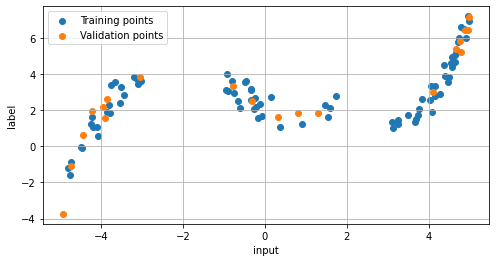

FOLD 2
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 9.676651954650879
AVERAGE VAL LOSS: 9.316837310791016
# EPOCH 2
AVERAGE TRAIN LOSS: 7.644947528839111
AVERAGE VAL LOSS: 6.555392742156982
# EPOCH 3
AVERAGE TRAIN LOSS: 6.125925064086914
AVERAGE VAL LOSS: 4.723842620849609
# EPOCH 4
AVERAGE TRAIN LOSS: 4.374383449554443
AVERAGE VAL LOSS: 3.4718384742736816
# EPOCH 5
AVERAGE TRAIN LOSS: 3.6560988426208496
AVERAGE VAL LOSS: 2.759618043899536
# EPOCH 6
AVERAGE TRAIN LOSS: 3.1215925216674805
AVERAGE VAL LOSS: 2.558431625366211
# EPOCH 7
AVERAGE TRAIN LOSS: 3.2794976234436035
AVERAGE VAL LOSS: 2.6670141220092773
# EPOCH 8
AVERAGE TRAIN LOSS: 3.173600912094116
AVERAGE VAL LOSS: 2.818493366241455
# EPOCH 9
AVERAGE TRAIN LOSS: 3.196068286895752
AVERAGE VAL LOSS: 2.8605964183807373
# EPOCH 10
AVERAGE TRAIN LOSS: 3.1730215549468994
AVERAGE VAL LOSS: 2.759023427963257
# EPOCH 11
AVERAGE TRAIN LOSS: 2.8408608436584473
AVERAGE VAL LOSS: 2.540426015853882


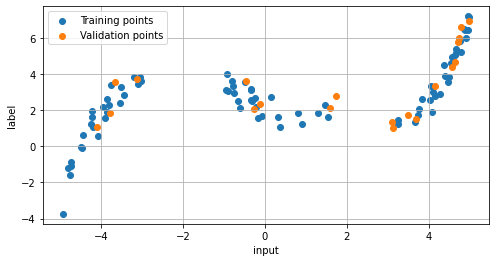

FOLD 3
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 11.044107437133789
AVERAGE VAL LOSS: 4.813687801361084
# EPOCH 2
AVERAGE TRAIN LOSS: 7.669230937957764
AVERAGE VAL LOSS: 4.352347373962402
# EPOCH 3
AVERAGE TRAIN LOSS: 5.079675197601318
AVERAGE VAL LOSS: 4.368640899658203
# EPOCH 4
AVERAGE TRAIN LOSS: 3.844618320465088
AVERAGE VAL LOSS: 4.597781658172607
# EPOCH 5
AVERAGE TRAIN LOSS: 3.3609812259674072
AVERAGE VAL LOSS: 4.891724586486816
# EPOCH 6
AVERAGE TRAIN LOSS: 3.7401764392852783
AVERAGE VAL LOSS: 4.801599025726318
# EPOCH 7
AVERAGE TRAIN LOSS: 3.3976011276245117
AVERAGE VAL LOSS: 4.562887191772461
# EPOCH 8
AVERAGE TRAIN LOSS: 3.772800922393799
AVERAGE VAL LOSS: 4.212679862976074
# EPOCH 9
AVERAGE TRAIN LOSS: 3.87764835357666
AVERAGE VAL LOSS: 3.890456438064575
# EPOCH 10
AVERAGE TRAIN LOSS: 2.9871578216552734
AVERAGE VAL LOSS: 3.5545144081115723
# EPOCH 11
AVERAGE TRAIN LOSS: 3.123687744140625
AVERAGE VAL LOSS: 3.3400654792785645
# 

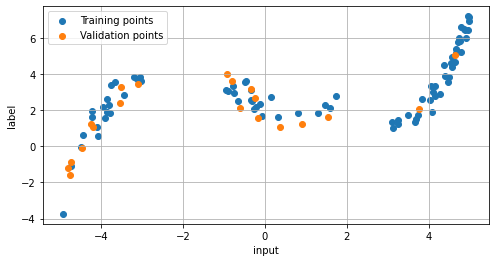

FOLD 4
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 9.881604194641113
AVERAGE VAL LOSS: 7.717998504638672
# EPOCH 2
AVERAGE TRAIN LOSS: 8.005620002746582
AVERAGE VAL LOSS: 5.438838481903076
# EPOCH 3
AVERAGE TRAIN LOSS: 6.8460893630981445
AVERAGE VAL LOSS: 3.8509347438812256
# EPOCH 4
AVERAGE TRAIN LOSS: 5.386831283569336
AVERAGE VAL LOSS: 2.9066712856292725
# EPOCH 5
AVERAGE TRAIN LOSS: 4.459841728210449
AVERAGE VAL LOSS: 2.516749143600464
# EPOCH 6
AVERAGE TRAIN LOSS: 3.4925432205200195
AVERAGE VAL LOSS: 2.654942512512207
# EPOCH 7
AVERAGE TRAIN LOSS: 3.85688853263855
AVERAGE VAL LOSS: 3.106431245803833
# EPOCH 8
AVERAGE TRAIN LOSS: 3.7219510078430176
AVERAGE VAL LOSS: 3.6752266883850098
# EPOCH 9
AVERAGE TRAIN LOSS: 3.527782440185547
AVERAGE VAL LOSS: 3.958289861679077
# EPOCH 10
AVERAGE TRAIN LOSS: 3.3362698554992676
AVERAGE VAL LOSS: 3.9240825176239014
# EPOCH 11
AVERAGE TRAIN LOSS: 3.2634739875793457
AVERAGE VAL LOSS: 3.6771113872528076

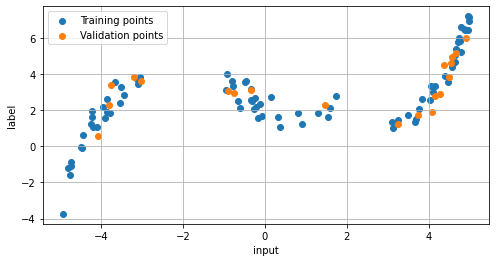

FOLD 5
Trail with dropout:0.5, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 9.068387031555176
AVERAGE VAL LOSS: 5.817615032196045
# EPOCH 2
AVERAGE TRAIN LOSS: 6.322237968444824
AVERAGE VAL LOSS: 4.0805182456970215
# EPOCH 3
AVERAGE TRAIN LOSS: 5.067828178405762
AVERAGE VAL LOSS: 3.1171650886535645
# EPOCH 4
AVERAGE TRAIN LOSS: 4.011358737945557
AVERAGE VAL LOSS: 2.7538299560546875
# EPOCH 5
AVERAGE TRAIN LOSS: 4.380785942077637
AVERAGE VAL LOSS: 2.8058278560638428
# EPOCH 6
AVERAGE TRAIN LOSS: 3.348906993865967
AVERAGE VAL LOSS: 3.095168352127075
# EPOCH 7
AVERAGE TRAIN LOSS: 3.7060136795043945
AVERAGE VAL LOSS: 3.3273627758026123
# EPOCH 8
AVERAGE TRAIN LOSS: 4.031648635864258
AVERAGE VAL LOSS: 3.3441498279571533
# EPOCH 9
AVERAGE TRAIN LOSS: 3.5048742294311523
AVERAGE VAL LOSS: 3.183337926864624
# EPOCH 10
AVERAGE TRAIN LOSS: 3.2367074489593506
AVERAGE VAL LOSS: 2.8933334350585938
# EPOCH 11
AVERAGE TRAIN LOSS: 3.5427184104919434
AVERAGE VAL LOSS: 2.5683834552764

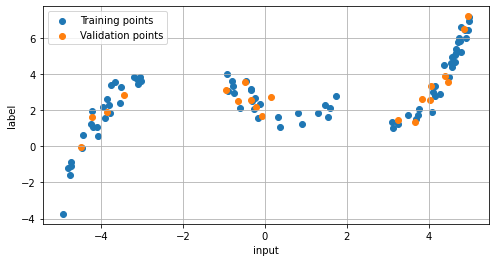

[I 2022-01-10 20:24:10,750] Trial 12 pruned. 


FOLD 1
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 10.04035758972168
AVERAGE VAL LOSS: 11.537264823913574
# EPOCH 2
AVERAGE TRAIN LOSS: 7.346122741699219
AVERAGE VAL LOSS: 8.9324951171875
# EPOCH 3
AVERAGE TRAIN LOSS: 5.34675407409668
AVERAGE VAL LOSS: 7.136296272277832
# EPOCH 4
AVERAGE TRAIN LOSS: 4.120917797088623
AVERAGE VAL LOSS: 6.00008487701416
# EPOCH 5
AVERAGE TRAIN LOSS: 3.395404815673828
AVERAGE VAL LOSS: 5.281466484069824
# EPOCH 6
AVERAGE TRAIN LOSS: 3.1849284172058105
AVERAGE VAL LOSS: 4.749334812164307
# EPOCH 7
AVERAGE TRAIN LOSS: 3.063375949859619
AVERAGE VAL LOSS: 4.3031907081604
# EPOCH 8
AVERAGE TRAIN LOSS: 3.242954730987549
AVERAGE VAL LOSS: 3.9023025035858154
# EPOCH 9
AVERAGE TRAIN LOSS: 3.338202476501465
AVERAGE VAL LOSS: 3.5604405403137207
# EPOCH 10
AVERAGE TRAIN LOSS: 3.188929557800293
AVERAGE VAL LOSS: 3.300333023071289
# EPOCH 11
AVERAGE TRAIN LOSS: 3.011270046234131
AVERAGE VAL LOSS: 3.1579134464263916
# EPOCH 12
AVERAGE TRAIN LOSS: 2.839653968811035
AVERAGE VAL LOSS: 3.123105764389038


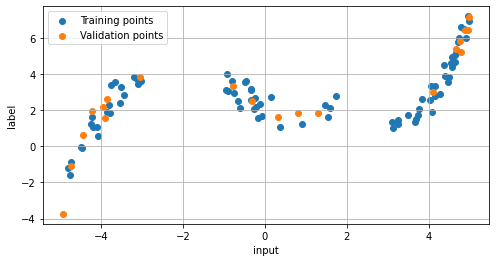

FOLD 2
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 12.421897888183594
AVERAGE VAL LOSS: 12.399864196777344
# EPOCH 2
AVERAGE TRAIN LOSS: 9.033292770385742
AVERAGE VAL LOSS: 8.901564598083496
# EPOCH 3
AVERAGE TRAIN LOSS: 6.647625923156738
AVERAGE VAL LOSS: 6.2173752784729
# EPOCH 4
AVERAGE TRAIN LOSS: 5.168830871582031
AVERAGE VAL LOSS: 4.2608137130737305
# EPOCH 5
AVERAGE TRAIN LOSS: 4.151514053344727
AVERAGE VAL LOSS: 2.989015579223633
# EPOCH 6
AVERAGE TRAIN LOSS: 3.491279125213623
AVERAGE VAL LOSS: 2.3380393981933594
# EPOCH 7
AVERAGE TRAIN LOSS: 3.047719955444336
AVERAGE VAL LOSS: 2.218670129776001
# EPOCH 8
AVERAGE TRAIN LOSS: 2.951289653778076
AVERAGE VAL LOSS: 2.441023349761963
# EPOCH 9
AVERAGE TRAIN LOSS: 3.11401629447937
AVERAGE VAL LOSS: 2.750023603439331
# EPOCH 10
AVERAGE TRAIN LOSS: 3.015685558319092
AVERAGE VAL LOSS: 2.9290895462036133
# EPOCH 11
AVERAGE TRAIN LOSS: 3.146867036819458
AVERAGE VAL LOSS: 2.9507219791412354
# EPO

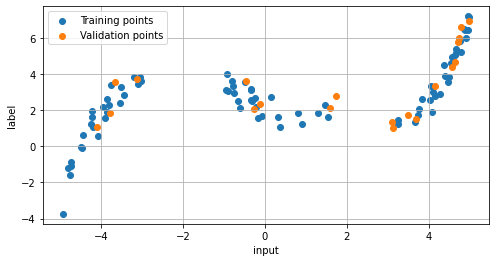

FOLD 3
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 15.153446197509766
AVERAGE VAL LOSS: 5.838797092437744
# EPOCH 2
AVERAGE TRAIN LOSS: 12.259424209594727
AVERAGE VAL LOSS: 5.20314884185791
# EPOCH 3
AVERAGE TRAIN LOSS: 9.79956340789795
AVERAGE VAL LOSS: 4.983169078826904
# EPOCH 4
AVERAGE TRAIN LOSS: 7.714766025543213
AVERAGE VAL LOSS: 5.02792501449585
# EPOCH 5
AVERAGE TRAIN LOSS: 6.448671817779541
AVERAGE VAL LOSS: 5.221075534820557
# EPOCH 6
AVERAGE TRAIN LOSS: 5.144198894500732
AVERAGE VAL LOSS: 5.269664287567139
# EPOCH 7
AVERAGE TRAIN LOSS: 4.074832916259766
AVERAGE VAL LOSS: 5.108281135559082
# EPOCH 8
AVERAGE TRAIN LOSS: 3.352433681488037
AVERAGE VAL LOSS: 4.753225326538086
# EPOCH 9
AVERAGE TRAIN LOSS: 2.7865254878997803
AVERAGE VAL LOSS: 4.350196361541748
# EPOCH 10
AVERAGE TRAIN LOSS: 2.7251205444335938
AVERAGE VAL LOSS: 4.015811920166016
# EPOCH 11
AVERAGE TRAIN LOSS: 2.7291462421417236
AVERAGE VAL LOSS: 3.6751060485839844
# EPO

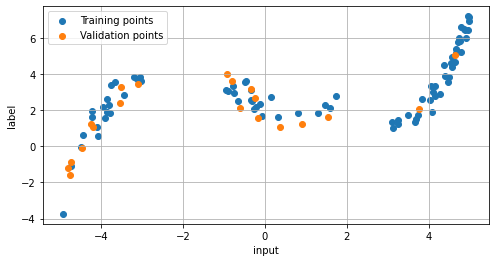

FOLD 4
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 10.120748519897461
AVERAGE VAL LOSS: 7.48126220703125
# EPOCH 2
AVERAGE TRAIN LOSS: 7.395780563354492
AVERAGE VAL LOSS: 4.890763282775879
# EPOCH 3
AVERAGE TRAIN LOSS: 5.3955535888671875
AVERAGE VAL LOSS: 3.3339619636535645
# EPOCH 4
AVERAGE TRAIN LOSS: 4.182023525238037
AVERAGE VAL LOSS: 2.676828145980835
# EPOCH 5
AVERAGE TRAIN LOSS: 3.503974437713623
AVERAGE VAL LOSS: 2.8203489780426025
# EPOCH 6
AVERAGE TRAIN LOSS: 3.32484769821167
AVERAGE VAL LOSS: 3.431623935699463
# EPOCH 7
AVERAGE TRAIN LOSS: 3.344226121902466
AVERAGE VAL LOSS: 4.033885478973389
# EPOCH 8
AVERAGE TRAIN LOSS: 3.4999096393585205
AVERAGE VAL LOSS: 4.267335891723633
# EPOCH 9
AVERAGE TRAIN LOSS: 3.4862303733825684
AVERAGE VAL LOSS: 4.275054931640625
# EPOCH 10
AVERAGE TRAIN LOSS: 3.416081666946411
AVERAGE VAL LOSS: 4.02766752243042
# EPOCH 11
AVERAGE TRAIN LOSS: 3.1659770011901855
AVERAGE VAL LOSS: 3.6177010536193848
# E

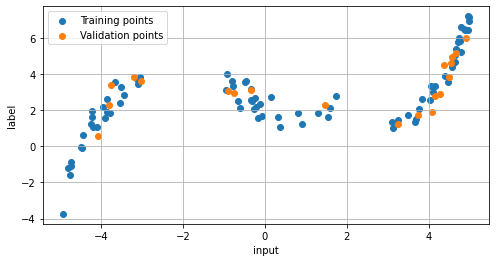

FOLD 5
Trail with dropout:0.1, adam_lr:0.001, weight_decay:0.0001
# EPOCH 1
AVERAGE TRAIN LOSS: 11.390789031982422
AVERAGE VAL LOSS: 7.5254082679748535
# EPOCH 2
AVERAGE TRAIN LOSS: 7.973113059997559
AVERAGE VAL LOSS: 5.184486389160156
# EPOCH 3
AVERAGE TRAIN LOSS: 5.568428993225098
AVERAGE VAL LOSS: 3.698986053466797
# EPOCH 4
AVERAGE TRAIN LOSS: 4.408400535583496
AVERAGE VAL LOSS: 2.968062162399292
# EPOCH 5
AVERAGE TRAIN LOSS: 3.5967743396759033
AVERAGE VAL LOSS: 2.857872486114502
# EPOCH 6
AVERAGE TRAIN LOSS: 3.2389135360717773
AVERAGE VAL LOSS: 3.096830368041992
# EPOCH 7
AVERAGE TRAIN LOSS: 3.6240642070770264
AVERAGE VAL LOSS: 3.4080722332000732
# EPOCH 8
AVERAGE TRAIN LOSS: 3.507246971130371
AVERAGE VAL LOSS: 3.573678731918335
# EPOCH 9
AVERAGE TRAIN LOSS: 3.8108181953430176
AVERAGE VAL LOSS: 3.52119517326355
# EPOCH 10
AVERAGE TRAIN LOSS: 3.4745378494262695
AVERAGE VAL LOSS: 3.308490514755249
# EPOCH 11
AVERAGE TRAIN LOSS: 3.4385061264038086
AVERAGE VAL LOSS: 3.016245126724243


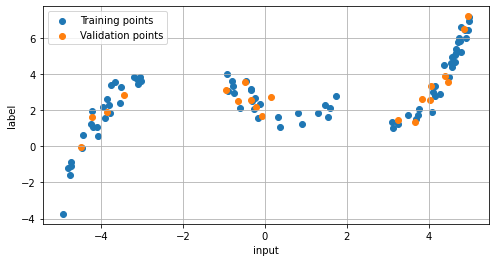

[I 2022-01-10 20:35:15,006] Trial 13 pruned. 


FOLD 1
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 10.641475677490234
AVERAGE VAL LOSS: 12.5747652053833
# EPOCH 2
AVERAGE TRAIN LOSS: 7.629173278808594
AVERAGE VAL LOSS: 10.10721492767334
# EPOCH 3
AVERAGE TRAIN LOSS: 5.995538234710693
AVERAGE VAL LOSS: 8.673914909362793
# EPOCH 4
AVERAGE TRAIN LOSS: 4.546842575073242
AVERAGE VAL LOSS: 7.540538311004639
# EPOCH 5
AVERAGE TRAIN LOSS: 3.839357852935791
AVERAGE VAL LOSS: 6.354130268096924
# EPOCH 6
AVERAGE TRAIN LOSS: 3.2393243312835693
AVERAGE VAL LOSS: 5.285375118255615
# EPOCH 7
AVERAGE TRAIN LOSS: 2.7886219024658203
AVERAGE VAL LOSS: 4.3212151527404785
# EPOCH 8
AVERAGE TRAIN LOSS: 2.7125985622406006
AVERAGE VAL LOSS: 3.6647942066192627
# EPOCH 9
AVERAGE TRAIN LOSS: 2.6997156143188477
AVERAGE VAL LOSS: 3.2688004970550537
# EPOCH 10
AVERAGE TRAIN LOSS: 2.783163070678711
AVERAGE VAL LOSS: 3.025089979171753
# EPOCH 11
AVERAGE TRAIN LOSS: 2.8550233840942383
AVERAGE VAL LOSS: 2.877537488937378
# EPOCH 12
AVERAGE TRAIN LOSS: 2.6562180519104004
AVERAGE VAL LOSS: 2.879334

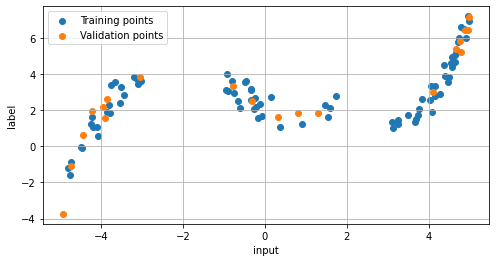

FOLD 2
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 13.184839248657227
AVERAGE VAL LOSS: 13.593765258789062
# EPOCH 2
AVERAGE TRAIN LOSS: 9.855030059814453
AVERAGE VAL LOSS: 9.529605865478516
# EPOCH 3
AVERAGE TRAIN LOSS: 7.470709800720215
AVERAGE VAL LOSS: 6.63057279586792
# EPOCH 4
AVERAGE TRAIN LOSS: 5.806055068969727
AVERAGE VAL LOSS: 4.592593669891357
# EPOCH 5
AVERAGE TRAIN LOSS: 4.72758150100708
AVERAGE VAL LOSS: 3.2509734630584717
# EPOCH 6
AVERAGE TRAIN LOSS: 3.8945376873016357
AVERAGE VAL LOSS: 2.600736379623413
# EPOCH 7
AVERAGE TRAIN LOSS: 3.4437363147735596
AVERAGE VAL LOSS: 2.5056703090667725
# EPOCH 8
AVERAGE TRAIN LOSS: 3.1800429821014404
AVERAGE VAL LOSS: 2.744290828704834
# EPOCH 9
AVERAGE TRAIN LOSS: 3.244722604751587
AVERAGE VAL LOSS: 3.043835163116455
# EPOCH 10
AVERAGE TRAIN LOSS: 3.3813958168029785
AVERAGE VAL LOSS: 3.220790147781372
# EPOCH 11
AVERAGE TRAIN LOSS: 3.372997760772705
AVERAGE VAL LOSS: 3.171950101852417
# E

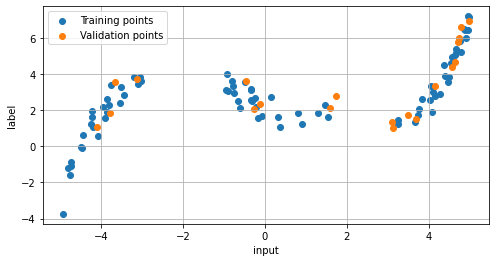

FOLD 3
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 13.952122688293457
AVERAGE VAL LOSS: 5.3505706787109375
# EPOCH 2
AVERAGE TRAIN LOSS: 10.013626098632812
AVERAGE VAL LOSS: 4.3528337478637695
# EPOCH 3
AVERAGE TRAIN LOSS: 7.06040096282959
AVERAGE VAL LOSS: 4.399097919464111
# EPOCH 4
AVERAGE TRAIN LOSS: 5.321474552154541
AVERAGE VAL LOSS: 4.861880779266357
# EPOCH 5
AVERAGE TRAIN LOSS: 4.285050868988037
AVERAGE VAL LOSS: 5.311713695526123
# EPOCH 6
AVERAGE TRAIN LOSS: 3.6551363468170166
AVERAGE VAL LOSS: 5.4967942237854
# EPOCH 7
AVERAGE TRAIN LOSS: 3.282921552658081
AVERAGE VAL LOSS: 5.244891166687012
# EPOCH 8
AVERAGE TRAIN LOSS: 2.835277557373047
AVERAGE VAL LOSS: 4.74406099319458
# EPOCH 9
AVERAGE TRAIN LOSS: 2.976067066192627
AVERAGE VAL LOSS: 4.2744622230529785
# EPOCH 10
AVERAGE TRAIN LOSS: 2.86715030670166
AVERAGE VAL LOSS: 3.8256378173828125
# EPOCH 11
AVERAGE TRAIN LOSS: 2.7797937393188477
AVERAGE VAL LOSS: 3.4718551635742188
# EPO

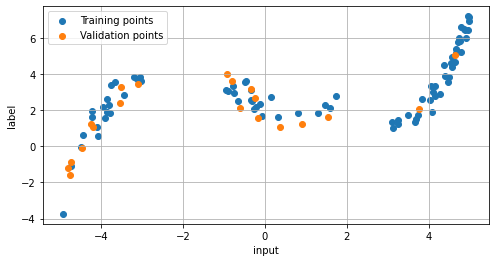

FOLD 4
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.684514999389648
AVERAGE VAL LOSS: 6.421483516693115
# EPOCH 2
AVERAGE TRAIN LOSS: 6.434384346008301
AVERAGE VAL LOSS: 3.7216758728027344
# EPOCH 3
AVERAGE TRAIN LOSS: 4.560500144958496
AVERAGE VAL LOSS: 2.485642910003662
# EPOCH 4
AVERAGE TRAIN LOSS: 3.364236831665039
AVERAGE VAL LOSS: 2.398284912109375
# EPOCH 5
AVERAGE TRAIN LOSS: 3.072258234024048
AVERAGE VAL LOSS: 2.941239595413208
# EPOCH 6
AVERAGE TRAIN LOSS: 3.1455612182617188
AVERAGE VAL LOSS: 3.6048362255096436
# EPOCH 7
AVERAGE TRAIN LOSS: 3.231410026550293
AVERAGE VAL LOSS: 4.040112495422363
# EPOCH 8
AVERAGE TRAIN LOSS: 3.25791072845459
AVERAGE VAL LOSS: 4.038568019866943
# EPOCH 9
AVERAGE TRAIN LOSS: 3.176470994949341
AVERAGE VAL LOSS: 3.820568084716797
# EPOCH 10
AVERAGE TRAIN LOSS: 3.186305046081543
AVERAGE VAL LOSS: 3.4222934246063232
# EPOCH 11
AVERAGE TRAIN LOSS: 2.7871267795562744
AVERAGE VAL LOSS: 3.062950372695923
# EPO

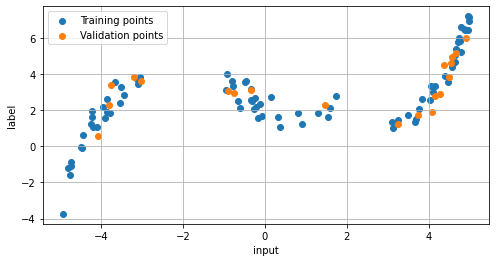

FOLD 5
Trail with dropout:0.1, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 15.837090492248535
AVERAGE VAL LOSS: 10.372283935546875
# EPOCH 2
AVERAGE TRAIN LOSS: 10.823312759399414
AVERAGE VAL LOSS: 7.132578372955322
# EPOCH 3
AVERAGE TRAIN LOSS: 7.563850402832031
AVERAGE VAL LOSS: 4.8944878578186035
# EPOCH 4
AVERAGE TRAIN LOSS: 5.674363136291504
AVERAGE VAL LOSS: 3.4989840984344482
# EPOCH 5
AVERAGE TRAIN LOSS: 4.370163440704346
AVERAGE VAL LOSS: 2.7955901622772217
# EPOCH 6
AVERAGE TRAIN LOSS: 3.693600654602051
AVERAGE VAL LOSS: 2.6268484592437744
# EPOCH 7
AVERAGE TRAIN LOSS: 3.2984025478363037
AVERAGE VAL LOSS: 2.8258473873138428
# EPOCH 8
AVERAGE TRAIN LOSS: 3.2945127487182617
AVERAGE VAL LOSS: 3.141408681869507
# EPOCH 9
AVERAGE TRAIN LOSS: 3.468153953552246
AVERAGE VAL LOSS: 3.305406332015991
# EPOCH 10
AVERAGE TRAIN LOSS: 3.5371265411376953
AVERAGE VAL LOSS: 3.267484426498413
# EPOCH 11
AVERAGE TRAIN LOSS: 3.428938865661621
AVERAGE VAL LOSS: 3.10057187080383

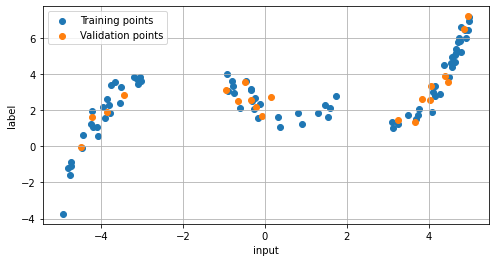

[I 2022-01-10 20:46:42,530] Trial 14 finished with value: 0.2600863575935364 and parameters: {'n_units_l0': 128, 'n_units_l1': 128, 'dropout': 0.1, 'weight_decay': 1e-05}. Best is trial 4 with value: 0.2103552371263504.


FOLD 1
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1


/usr/local/lib/python3.7/dist-packages/optuna/distributions.py:364: FutureWarning:

Samplers and other components in Optuna will assume that `step` is 1. `step` argument is deprecated and will be removed in the future. The removal of this feature is currently scheduled for v4.0.0, but this schedule is subject to change.



AVERAGE TRAIN LOSS: 10.687748908996582
AVERAGE VAL LOSS: 14.473236083984375
# EPOCH 2
AVERAGE TRAIN LOSS: 9.534087181091309
AVERAGE VAL LOSS: 12.678884506225586
# EPOCH 3
AVERAGE TRAIN LOSS: 8.033198356628418
AVERAGE VAL LOSS: 11.148375511169434
# EPOCH 4
AVERAGE TRAIN LOSS: 6.450963973999023
AVERAGE VAL LOSS: 9.77939510345459
# EPOCH 5
AVERAGE TRAIN LOSS: 5.709397315979004
AVERAGE VAL LOSS: 8.535832405090332
# EPOCH 6
AVERAGE TRAIN LOSS: 5.110650062561035
AVERAGE VAL LOSS: 7.456982612609863
# EPOCH 7
AVERAGE TRAIN LOSS: 4.332501411437988
AVERAGE VAL LOSS: 6.466928958892822
# EPOCH 8
AVERAGE TRAIN LOSS: 3.293079376220703
AVERAGE VAL LOSS: 5.644507884979248
# EPOCH 9
AVERAGE TRAIN LOSS: 3.0913453102111816
AVERAGE VAL LOSS: 4.920958042144775
# EPOCH 10
AVERAGE TRAIN LOSS: 3.004195213317871
AVERAGE VAL LOSS: 4.32634973526001
# EPOCH 11
AVERAGE TRAIN LOSS: 3.054018974304199
AVERAGE VAL LOSS: 3.84940767288208
# EPOCH 12
AVERAGE TRAIN LOSS: 2.8184585571289062
AVERAGE VAL LOSS: 3.488647937774

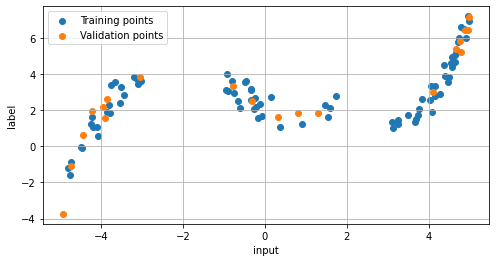

FOLD 2
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 11.139323234558105
AVERAGE VAL LOSS: 12.787653923034668
# EPOCH 2
AVERAGE TRAIN LOSS: 9.327499389648438
AVERAGE VAL LOSS: 10.0933256149292
# EPOCH 3
AVERAGE TRAIN LOSS: 7.839837551116943
AVERAGE VAL LOSS: 7.909411907196045
# EPOCH 4
AVERAGE TRAIN LOSS: 7.034999847412109
AVERAGE VAL LOSS: 6.121519565582275
# EPOCH 5
AVERAGE TRAIN LOSS: 5.479387283325195
AVERAGE VAL LOSS: 4.730973243713379
# EPOCH 6
AVERAGE TRAIN LOSS: 4.580333709716797
AVERAGE VAL LOSS: 3.7093162536621094
# EPOCH 7
AVERAGE TRAIN LOSS: 3.9216678142547607
AVERAGE VAL LOSS: 3.029134750366211
# EPOCH 8
AVERAGE TRAIN LOSS: 3.866361618041992
AVERAGE VAL LOSS: 2.6631364822387695
# EPOCH 9
AVERAGE TRAIN LOSS: 3.642573356628418
AVERAGE VAL LOSS: 2.5701282024383545
# EPOCH 10
AVERAGE TRAIN LOSS: 3.2361340522766113
AVERAGE VAL LOSS: 2.6439788341522217
# EPOCH 11
AVERAGE TRAIN LOSS: 3.019193649291992
AVERAGE VAL LOSS: 2.760836124420166
# 

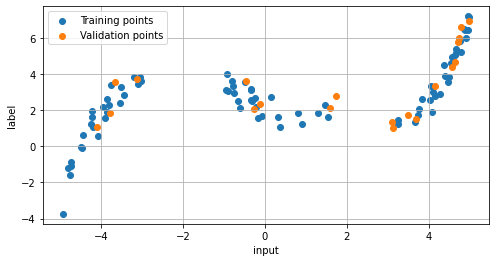

FOLD 3
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 12.04643440246582
AVERAGE VAL LOSS: 5.360093593597412
# EPOCH 2
AVERAGE TRAIN LOSS: 9.084068298339844
AVERAGE VAL LOSS: 4.859691143035889
# EPOCH 3
AVERAGE TRAIN LOSS: 7.868703365325928
AVERAGE VAL LOSS: 4.578080177307129
# EPOCH 4
AVERAGE TRAIN LOSS: 6.7884979248046875
AVERAGE VAL LOSS: 4.481911659240723
# EPOCH 5
AVERAGE TRAIN LOSS: 5.288447380065918
AVERAGE VAL LOSS: 4.512429714202881
# EPOCH 6
AVERAGE TRAIN LOSS: 4.310235977172852
AVERAGE VAL LOSS: 4.628452301025391
# EPOCH 7
AVERAGE TRAIN LOSS: 3.804060459136963
AVERAGE VAL LOSS: 4.683909893035889
# EPOCH 8
AVERAGE TRAIN LOSS: 3.8061232566833496
AVERAGE VAL LOSS: 4.622344970703125
# EPOCH 9
AVERAGE TRAIN LOSS: 3.422851085662842
AVERAGE VAL LOSS: 4.547726631164551
# EPOCH 10
AVERAGE TRAIN LOSS: 3.6804356575012207
AVERAGE VAL LOSS: 4.3943305015563965
# EPOCH 11
AVERAGE TRAIN LOSS: 2.9662656784057617
AVERAGE VAL LOSS: 4.197502136230469
# EP

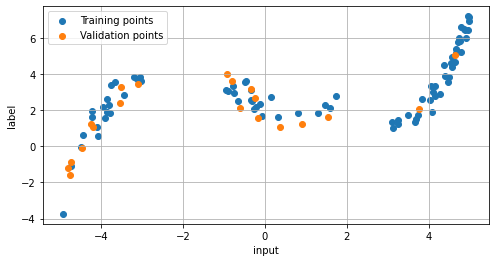

FOLD 4
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 11.626216888427734
AVERAGE VAL LOSS: 10.443620681762695
# EPOCH 2
AVERAGE TRAIN LOSS: 10.048651695251465
AVERAGE VAL LOSS: 8.675095558166504
# EPOCH 3
AVERAGE TRAIN LOSS: 8.869363784790039
AVERAGE VAL LOSS: 7.19134521484375
# EPOCH 4
AVERAGE TRAIN LOSS: 7.654134750366211
AVERAGE VAL LOSS: 5.94656229019165
# EPOCH 5
AVERAGE TRAIN LOSS: 6.831526756286621
AVERAGE VAL LOSS: 4.916577339172363
# EPOCH 6
AVERAGE TRAIN LOSS: 6.150136947631836
AVERAGE VAL LOSS: 4.086795330047607
# EPOCH 7
AVERAGE TRAIN LOSS: 5.280749797821045
AVERAGE VAL LOSS: 3.4309566020965576
# EPOCH 8
AVERAGE TRAIN LOSS: 4.93907356262207
AVERAGE VAL LOSS: 2.9561657905578613
# EPOCH 9
AVERAGE TRAIN LOSS: 4.592661380767822
AVERAGE VAL LOSS: 2.625870943069458
# EPOCH 10
AVERAGE TRAIN LOSS: 4.090734481811523
AVERAGE VAL LOSS: 2.4247560501098633
# EPOCH 11
AVERAGE TRAIN LOSS: 3.7064361572265625
AVERAGE VAL LOSS: 2.354591131210327
# EPO

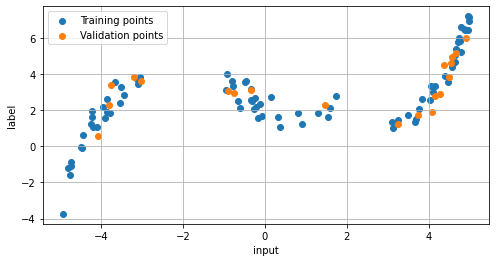

FOLD 5
Trail with dropout:0.5, adam_lr:0.001, weight_decay:1e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 11.376388549804688
AVERAGE VAL LOSS: 8.755393028259277
# EPOCH 2
AVERAGE TRAIN LOSS: 9.572407722473145
AVERAGE VAL LOSS: 7.11501407623291
# EPOCH 3
AVERAGE TRAIN LOSS: 8.429303169250488
AVERAGE VAL LOSS: 5.775915622711182
# EPOCH 4
AVERAGE TRAIN LOSS: 6.322629928588867
AVERAGE VAL LOSS: 4.705857753753662
# EPOCH 5
AVERAGE TRAIN LOSS: 5.562201023101807
AVERAGE VAL LOSS: 3.8641374111175537
# EPOCH 6
AVERAGE TRAIN LOSS: 5.092700004577637
AVERAGE VAL LOSS: 3.2157561779022217
# EPOCH 7
AVERAGE TRAIN LOSS: 4.410890579223633
AVERAGE VAL LOSS: 2.759037971496582
# EPOCH 8
AVERAGE TRAIN LOSS: 3.9618358612060547
AVERAGE VAL LOSS: 2.4700281620025635
# EPOCH 9
AVERAGE TRAIN LOSS: 3.6496763229370117
AVERAGE VAL LOSS: 2.3259165287017822
# EPOCH 10
AVERAGE TRAIN LOSS: 3.261549472808838
AVERAGE VAL LOSS: 2.3049659729003906
# EPOCH 11
AVERAGE TRAIN LOSS: 2.838043212890625
AVERAGE VAL LOSS: 2.3644464015960693
#

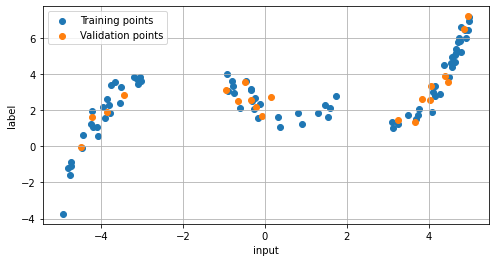

[I 2022-01-10 20:58:42,165] Trial 15 pruned. 


Study statistics: 
  Number of finished trials:  16
  Number of pruned trials:  7
  Number of complete trials:  9
Number of finished trials: 16
Best trial:
  Value: 0.2103552371263504
  Params: 
    n_units_l0: 128
    n_units_l1: 256
    dropout: 0.5
    weight_decay: 1e-05


In [ ]:
import optuna
import torch.nn.functional as F
from optuna.integration import PyTorchLightningPruningCallback
from sklearn.model_selection import KFold
from optuna.trial import TrialState

def objective(trial, train_dataloader, val_dataloader):

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    output_dims = [trial.suggest_int("n_units_l{}".format(i), 50, 300, log=True) for i in range(2)]
    dropout = trial.suggest_float('dropout', 0.01, 0.5) 

    model = Net(Ni, output_dims[0], output_dims[1], No, dropout=dropout).to(device)

    # Define the loss function
    loss_fn =  nn.MSELoss()
    # Define the optimizer
    lr = 1e-3
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-4) 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    print(f'Trail with dropout:{dropout}, adam_lr:{lr}, weight_decay:{weight_decay}')
  
    num_epochs = 100
    for epoch_num in range(num_epochs):
      print(f'# EPOCH {epoch_num+1}')

      train_loss_batches = train_epoch(model, device, train_dataloader, loss_fn, optimizer)
      train_loss = np.mean(train_loss_batches)   # average over the loss_batches --> #batches losses
      print(f"AVERAGE TRAIN LOSS: {train_loss}")

      val_loss_batches = val_epoch(model, device, val_dataloader, loss_fn)
      val_loss = np.mean(val_loss_batches)
      print(f"AVERAGE VAL LOSS: {val_loss}")

    Gen_error = np.abs(val_loss-train_loss)
    return Gen_error

def objective_cv(trial):

    fold = KFold(n_splits=5, shuffle=True, random_state=0) #provides train/test indices to split data in train/val sets
    gen_errors = []
    k = 0
    for fold_idx, (train_idx, val_idx) in enumerate(fold.split(range(len(train_dataset)))):
        train_data = torch.utils.data.Subset(train_dataset, train_idx)
        x_train = [train_data[i][0] for i in range(len(train_data))]   
        y_train = [train_data[i][1] for i in range(len(train_data))] 
        val_data = torch.utils.data.Subset(train_dataset, val_idx)
        x_val = [val_data[i][0] for i in range(len(val_data))]   
        y_val = [val_data[i][1] for i in range(len(val_data))] 

        train_dataloader = DataLoader(train_data, batch_size=int(len(train_data)/2), shuffle=True, num_workers=2)
        val_dataloader = DataLoader(val_data, batch_size=len(val_data), shuffle=False, num_workers=2)

        k += 1
        print(f'FOLD {k}')
        gen_error = objective(trial, train_dataloader, val_dataloader)
        gen_errors.append(gen_error)

        #Plot Train-Val points
        fig = plt.figure(figsize=(8,4))
        plt.scatter(x_train, y_train, label='Training points')
        plt.scatter(x_val, y_val, label='Validation points')
        plt.xlabel('input')
        plt.ylabel('label')
        plt.legend()
        plt.grid()
        plt.show()

    mean_gen_error = np.mean(gen_errors)
    trial.report(mean_gen_error, k)
  # Handle pruning based on the intermediate value.
    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_gen_error

# Study initialization
# direction = 'minimize' : since the goal is to minimize the Generalized error
# sampler = 'TPEsampler' : default paramter for single-objective optimization
# pruner = 'MedianPruner' : default paramter for pruning useless configurations

#study = optuna.create_study(study_name="myfirstoptimizationstudy", direction="minimize", pruner=pruner)
search_space = {"n_units_l0": [64, 128], "n_units_l1": [128, 256], "dropout": [0.1, 0.5], "weight_decay":[1e-5, 1e-4]}
study = optuna.create_study(study_name="Regression", direction="minimize", sampler=optuna.samplers.GridSampler(search_space))

# Opimization
# Recevies the function to be optimized and the number of trials
study.optimize(objective_cv, n_trials=16)
pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

print("Study statistics: ")
print("  Number of finished trials: ", len(study.trials))
print("  Number of pruned trials: ", len(pruned_trials))
print("  Number of complete trials: ", len(complete_trials))

print("Number of finished trials: {}".format(len(study.trials)))

print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))
    

#At the end it will tell us the best set of parameters after n_trails

### Analyze the trials

In [ ]:
complete_trials = study.get_trials()
for i in range(16):
  print(complete_trials[i].params)
  print(complete_trials[i].values[0])

{'n_units_l0': 128, 'n_units_l1': 128, 'dropout': 0.1, 'weight_decay': 0.0001}
0.35290277004241943
{'n_units_l0': 64, 'n_units_l1': 128, 'dropout': 0.5, 'weight_decay': 0.0001}
0.42244940996170044
{'n_units_l0': 64, 'n_units_l1': 128, 'dropout': 0.1, 'weight_decay': 0.0001}
0.27152448892593384
{'n_units_l0': 64, 'n_units_l1': 128, 'dropout': 0.1, 'weight_decay': 1e-05}
0.3094708323478699
{'n_units_l0': 128, 'n_units_l1': 256, 'dropout': 0.5, 'weight_decay': 1e-05}
0.2103552371263504
{'n_units_l0': 128, 'n_units_l1': 128, 'dropout': 0.5, 'weight_decay': 1e-05}
0.5415619015693665
{'n_units_l0': 64, 'n_units_l1': 256, 'dropout': 0.1, 'weight_decay': 1e-05}
0.29530686140060425
{'n_units_l0': 128, 'n_units_l1': 256, 'dropout': 0.1, 'weight_decay': 0.0001}
0.3099535405635834
{'n_units_l0': 128, 'n_units_l1': 256, 'dropout': 0.5, 'weight_decay': 0.0001}
0.2582131028175354
{'n_units_l0': 128, 'n_units_l1': 256, 'dropout': 0.1, 'weight_decay': 1e-05}
0.25260475277900696
{'n_units_l0': 64, 'n_un

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
labels = []
for i in range(16):
    labels.append(f'Trail {i+1}')

fig = make_subplots(rows=3, cols=2, subplot_titles=("Val loss", "Nh1", "dropout", "Nh2", "weight decay"))
fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].values[0] for i in range(16)],
          text=["%.3f" % complete_trials[i].values[0] for i in range(16)],
          textposition='auto',
      ), 1,1)

fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['dropout'] for i in range(16)],
          text=["%.3f" % complete_trials[i].params['dropout'] for i in range(16)],
          textposition='auto',
      ), 2,1)

fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['weight_decay'] for i in range(16)],
          text=["%.1e" % complete_trials[i].params['weight_decay'] for i in range(16)],
          textposition='auto',
      ), 3,1)



fig.add_trace(go.Bar(
                        x=labels, 
                        y=[complete_trials[i].params['n_units_l0'] for i in range(16)],
                        text=[ complete_trials[i].params['n_units_l0'] for i in range(16)],
                        textposition='auto',
      ), 1, 2)


fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['n_units_l1'] for i in range(16)],
          text=[complete_trials[i].params['n_units_l1'] for i in range(16)],
          textposition='auto',

      ), 2, 2)
fig.show()

### Best Model with the whole Training Dataset

In [ ]:
#BEST MODEL
### Set the random seed for reproducible results
torch.manual_seed(0)

Ni = 1
Nh1 = study.best_trial.params['n_units_l0']
Nh2 = study.best_trial.params['n_units_l1']
No = 1
dropout = study.best_trial.params['dropout']
best_model = Net(Ni, Nh1, Nh2, No, dropout)
best_model.to(device)


Net(
  (ffnn): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [ ]:
torch.manual_seed(0)
best_model = Net(Ni, Nh1, Nh2, No, dropout)
best_model.to(device)

# Define the loss function
loss_fn =  nn.MSELoss() 
# Define the optimizer
weight_decay = study.best_trial.params['weight_decay']
lr = 1e-3
optimizer = torch.optim.Adam(best_model.parameters(), lr=lr, weight_decay=weight_decay)

In [ ]:
### TRAINING LOOP
test_dataloader = DataLoader(test_dataset, batch_size=int(len(test_dataset)/2), shuffle=False, num_workers=2)
train_dataloader = DataLoader(train_dataset, batch_size=int(len(train_dataset)/2), shuffle=True, num_workers=2)
num_epochs = 500     #1epoch=1iter over your data
train_loss_log, test_loss_log = [], []
for epoch_num in range(num_epochs):
    print(f'# EPOCH {epoch_num+1}')

    train_loss_batches = train_epoch(best_model, device, train_dataloader, loss_fn, optimizer)
    train_loss = np.mean(train_loss_batches)   # average over the loss_batches --> #batches losses
    print(f"AVERAGE TRAIN LOSS: {train_loss}")
    train_loss_log.append(train_loss)

    test_loss_batches = val_epoch(best_model, device, test_dataloader, loss_fn)
    test_loss = np.mean(test_loss_batches)
    print(f"AVERAGE VAL LOSS: {test_loss}")
    test_loss_log.append(test_loss)

# EPOCH 1
AVERAGE TRAIN LOSS: 8.98215103149414
AVERAGE VAL LOSS: 5.6990838050842285
# EPOCH 2
AVERAGE TRAIN LOSS: 5.737781524658203
AVERAGE VAL LOSS: 4.485055446624756
# EPOCH 3
AVERAGE TRAIN LOSS: 4.000263214111328
AVERAGE VAL LOSS: 4.054462909698486
# EPOCH 4
AVERAGE TRAIN LOSS: 3.4305737018585205
AVERAGE VAL LOSS: 4.070807933807373
# EPOCH 5
AVERAGE TRAIN LOSS: 3.2416176795959473
AVERAGE VAL LOSS: 4.254177093505859
# EPOCH 6
AVERAGE TRAIN LOSS: 3.7367501258850098
AVERAGE VAL LOSS: 4.3442535400390625
# EPOCH 7
AVERAGE TRAIN LOSS: 4.1366353034973145
AVERAGE VAL LOSS: 4.243627548217773
# EPOCH 8
AVERAGE TRAIN LOSS: 3.8926920890808105
AVERAGE VAL LOSS: 3.9795145988464355
# EPOCH 9
AVERAGE TRAIN LOSS: 2.990086555480957
AVERAGE VAL LOSS: 3.68078351020813
# EPOCH 10
AVERAGE TRAIN LOSS: 2.817852735519409
AVERAGE VAL LOSS: 3.4478509426116943
# EPOCH 11
AVERAGE TRAIN LOSS: 2.5800094604492188
AVERAGE VAL LOSS: 3.299022674560547
# EPOCH 12
AVERAGE TRAIN LOSS: 2.8337535858154297
AVERAGE VAL LOSS

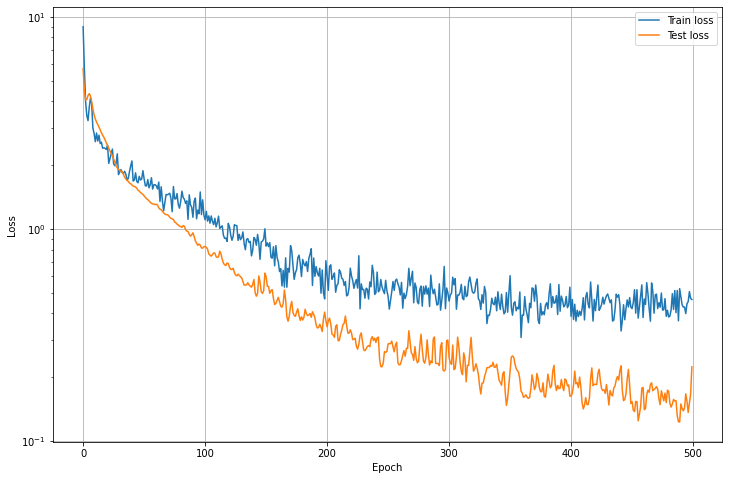

In [ ]:
# Plot losses
plt.figure(figsize=(12,8))
plt.semilogy(train_loss_log, label='Train loss')
plt.semilogy(test_loss_log, label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()

# OPTUNA

In [ ]:
! pip install optuna

     |████████████████████████████████| 308 kB 5.5 MB/s 
     |████████████████████████████████| 209 kB 39.9 MB/s 
     |████████████████████████████████| 80 kB 8.5 MB/s 
     |████████████████████████████████| 75 kB 4.1 MB/s 
     |████████████████████████████████| 49 kB 5.2 MB/s 
     |████████████████████████████████| 112 kB 40.7 MB/s 
     |████████████████████████████████| 149 kB 43.7 MB/s 
  Created wheel for pyperclip: filename=pyperclip-1.8.2-py3-none-any.whl size=11136 sha256=3cde9581a676223f67f2e6b74263e12f8d1e3fb7624e73477410098322d84c31
  Stored in directory: /root/.cache/pip/wheels/9f/18/84/8f69f8b08169c7bae2dde6bd7daf0c19fca8c8e500ee620a28
Successfully built pyperclip


[I 2021-12-31 15:24:25,977] A new study created in memory with name: Regression


FOLD 1
Trail with dropout:0.13403055965755864, adam_lr:0.0054427931347575, weight_decay:1.5029275758738817e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.108433723449707
AVERAGE VAL LOSS: 8.328680992126465
# EPOCH 2
AVERAGE TRAIN LOSS: 3.8005881309509277
AVERAGE VAL LOSS: 4.89312219619751
# EPOCH 3
AVERAGE TRAIN LOSS: 3.473412275314331
AVERAGE VAL LOSS: 3.410250186920166
# EPOCH 4
AVERAGE TRAIN LOSS: 3.931899070739746
AVERAGE VAL LOSS: 2.7788703441619873
# EPOCH 5
AVERAGE TRAIN LOSS: 3.15889310836792
AVERAGE VAL LOSS: 2.930762767791748
# EPOCH 6
AVERAGE TRAIN LOSS: 2.717263698577881
AVERAGE VAL LOSS: 3.844245195388794
# EPOCH 7
AVERAGE TRAIN LOSS: 2.4527182579040527
AVERAGE VAL LOSS: 4.866654872894287
# EPOCH 8
AVERAGE TRAIN LOSS: 2.781132221221924
AVERAGE VAL LOSS: 5.109350204467773
# EPOCH 9
AVERAGE TRAIN LOSS: 2.611506938934326
AVERAGE VAL LOSS: 4.211374759674072
# EPOCH 10
AVERAGE TRAIN LOSS: 2.1287806034088135
AVERAGE VAL LOSS: 3.286597967147827
# EPOCH 11
AVERAGE TRAIN LOSS: 2.2390403747558

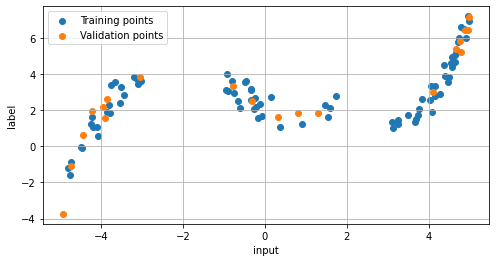

FOLD 2
Trail with dropout:0.13403055965755864, adam_lr:0.0054427931347575, weight_decay:1.5029275758738817e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 7.183263778686523
AVERAGE VAL LOSS: 3.3244118690490723
# EPOCH 2
AVERAGE TRAIN LOSS: 3.4700613021850586
AVERAGE VAL LOSS: 3.2474286556243896
# EPOCH 3
AVERAGE TRAIN LOSS: 3.8363828659057617
AVERAGE VAL LOSS: 3.3974761962890625
# EPOCH 4
AVERAGE TRAIN LOSS: 3.3488144874572754
AVERAGE VAL LOSS: 2.7179577350616455
# EPOCH 5
AVERAGE TRAIN LOSS: 2.766207695007324
AVERAGE VAL LOSS: 2.4950222969055176
# EPOCH 6
AVERAGE TRAIN LOSS: 2.6319971084594727
AVERAGE VAL LOSS: 2.54874324798584
# EPOCH 7
AVERAGE TRAIN LOSS: 2.5656867027282715
AVERAGE VAL LOSS: 2.392705202102661
# EPOCH 8
AVERAGE TRAIN LOSS: 2.405606508255005
AVERAGE VAL LOSS: 2.1288602352142334
# EPOCH 9
AVERAGE TRAIN LOSS: 2.295163154602051
AVERAGE VAL LOSS: 2.0468060970306396
# EPOCH 10
AVERAGE TRAIN LOSS: 2.17555570602417
AVERAGE VAL LOSS: 2.0449841022491455
# EPOCH 11
AVERAGE TRAIN LOSS: 1.9687

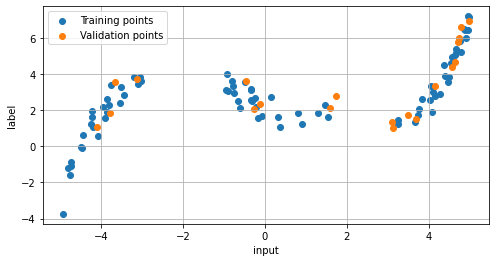

FOLD 3
Trail with dropout:0.13403055965755864, adam_lr:0.0054427931347575, weight_decay:1.5029275758738817e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 12.836139678955078
AVERAGE VAL LOSS: 5.317626476287842
# EPOCH 2
AVERAGE TRAIN LOSS: 5.530968189239502
AVERAGE VAL LOSS: 5.2216715812683105
# EPOCH 3
AVERAGE TRAIN LOSS: 3.102797508239746
AVERAGE VAL LOSS: 4.811528205871582
# EPOCH 4
AVERAGE TRAIN LOSS: 3.581798791885376
AVERAGE VAL LOSS: 4.2932963371276855
# EPOCH 5
AVERAGE TRAIN LOSS: 3.9149699211120605
AVERAGE VAL LOSS: 3.294970750808716
# EPOCH 6
AVERAGE TRAIN LOSS: 3.270275592803955
AVERAGE VAL LOSS: 2.8167741298675537
# EPOCH 7
AVERAGE TRAIN LOSS: 2.991581916809082
AVERAGE VAL LOSS: 2.748558521270752
# EPOCH 8
AVERAGE TRAIN LOSS: 2.8533942699432373
AVERAGE VAL LOSS: 2.8187291622161865
# EPOCH 9
AVERAGE TRAIN LOSS: 2.6103334426879883
AVERAGE VAL LOSS: 3.0782268047332764
# EPOCH 10
AVERAGE TRAIN LOSS: 2.583185911178589
AVERAGE VAL LOSS: 3.4713616371154785
# EPOCH 11
AVERAGE TRAIN LOSS: 2.57422

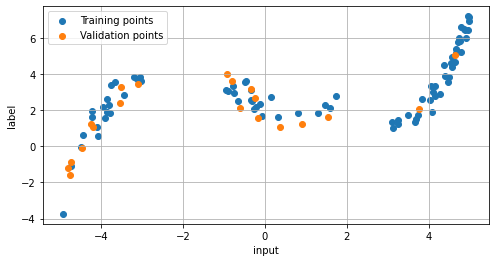

FOLD 4
Trail with dropout:0.13403055965755864, adam_lr:0.0054427931347575, weight_decay:1.5029275758738817e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.480672836303711
AVERAGE VAL LOSS: 4.78755521774292
# EPOCH 2
AVERAGE TRAIN LOSS: 5.433187484741211
AVERAGE VAL LOSS: 2.0129880905151367
# EPOCH 3
AVERAGE TRAIN LOSS: 3.573822498321533
AVERAGE VAL LOSS: 3.022784948348999
# EPOCH 4
AVERAGE TRAIN LOSS: 3.4588825702667236
AVERAGE VAL LOSS: 4.942764759063721
# EPOCH 5
AVERAGE TRAIN LOSS: 3.7065587043762207
AVERAGE VAL LOSS: 4.695807456970215
# EPOCH 6
AVERAGE TRAIN LOSS: 3.1920042037963867
AVERAGE VAL LOSS: 3.7076523303985596
# EPOCH 7
AVERAGE TRAIN LOSS: 2.819587230682373
AVERAGE VAL LOSS: 2.8908259868621826
# EPOCH 8
AVERAGE TRAIN LOSS: 2.515749931335449
AVERAGE VAL LOSS: 2.224141836166382
# EPOCH 9
AVERAGE TRAIN LOSS: 2.5789639949798584
AVERAGE VAL LOSS: 1.8390251398086548
# EPOCH 10
AVERAGE TRAIN LOSS: 2.5180912017822266
AVERAGE VAL LOSS: 1.6661056280136108
# EPOCH 11
AVERAGE TRAIN LOSS: 2.598896

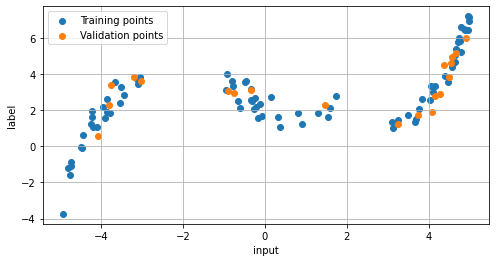

FOLD 5
Trail with dropout:0.13403055965755864, adam_lr:0.0054427931347575, weight_decay:1.5029275758738817e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.312496185302734
AVERAGE VAL LOSS: 3.016310214996338
# EPOCH 2
AVERAGE TRAIN LOSS: 3.673569679260254
AVERAGE VAL LOSS: 2.659001111984253
# EPOCH 3
AVERAGE TRAIN LOSS: 3.342515468597412
AVERAGE VAL LOSS: 3.5339317321777344
# EPOCH 4
AVERAGE TRAIN LOSS: 3.746181011199951
AVERAGE VAL LOSS: 3.125553846359253
# EPOCH 5
AVERAGE TRAIN LOSS: 3.1001601219177246
AVERAGE VAL LOSS: 2.2809531688690186
# EPOCH 6
AVERAGE TRAIN LOSS: 2.5903480052948
AVERAGE VAL LOSS: 1.8125027418136597
# EPOCH 7
AVERAGE TRAIN LOSS: 2.5788521766662598
AVERAGE VAL LOSS: 1.680489182472229
# EPOCH 8
AVERAGE TRAIN LOSS: 2.5771563053131104
AVERAGE VAL LOSS: 1.620263695716858
# EPOCH 9
AVERAGE TRAIN LOSS: 2.6458330154418945
AVERAGE VAL LOSS: 1.5130891799926758
# EPOCH 10
AVERAGE TRAIN LOSS: 2.408949613571167
AVERAGE VAL LOSS: 1.4515663385391235
# EPOCH 11
AVERAGE TRAIN LOSS: 2.19838333

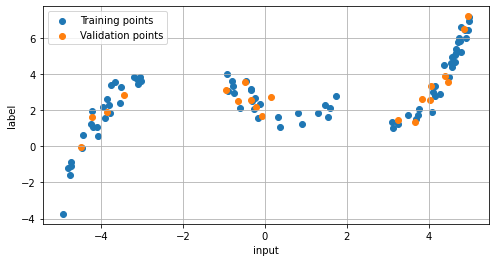

[I 2021-12-31 15:27:07,843] Trial 0 finished with value: 0.07817257195711136 and parameters: {'n_units_l0': 50, 'n_units_l1': 118, 'dropout': 0.13403055965755864, 'lr': 0.0054427931347575, 'weight_decay': 1.5029275758738817e-05}. Best is trial 0 with value: 0.07817257195711136.


FOLD 1
Trail with dropout:0.2299860127874589, adam_lr:0.004965222074369671, weight_decay:5.53928543130121e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 7.525376319885254
AVERAGE VAL LOSS: 5.158693313598633
# EPOCH 2
AVERAGE TRAIN LOSS: 4.351983070373535
AVERAGE VAL LOSS: 3.0079057216644287
# EPOCH 3
AVERAGE TRAIN LOSS: 2.6480722427368164
AVERAGE VAL LOSS: 3.873032331466675
# EPOCH 4
AVERAGE TRAIN LOSS: 2.5577707290649414
AVERAGE VAL LOSS: 4.499644756317139
# EPOCH 5
AVERAGE TRAIN LOSS: 2.3229031562805176
AVERAGE VAL LOSS: 4.417083740234375
# EPOCH 6
AVERAGE TRAIN LOSS: 2.5064311027526855
AVERAGE VAL LOSS: 3.1402008533477783
# EPOCH 7
AVERAGE TRAIN LOSS: 2.0772194862365723
AVERAGE VAL LOSS: 2.677924156188965
# EPOCH 8
AVERAGE TRAIN LOSS: 2.0445241928100586
AVERAGE VAL LOSS: 2.792304754257202
# EPOCH 9
AVERAGE TRAIN LOSS: 1.7701103687286377
AVERAGE VAL LOSS: 3.128488540649414
# EPOCH 10
AVERAGE TRAIN LOSS: 1.9719038009643555
AVERAGE VAL LOSS: 3.362699508666992
# EPOCH 11
AVERAGE TRAIN LOSS: 1.574033

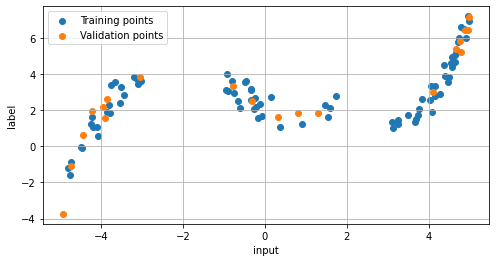

FOLD 2
Trail with dropout:0.2299860127874589, adam_lr:0.004965222074369671, weight_decay:5.53928543130121e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 5.513034343719482
AVERAGE VAL LOSS: 6.763648986816406
# EPOCH 2
AVERAGE TRAIN LOSS: 5.542412281036377
AVERAGE VAL LOSS: 2.5901927947998047
# EPOCH 3
AVERAGE TRAIN LOSS: 2.731640100479126
AVERAGE VAL LOSS: 2.635242462158203
# EPOCH 4
AVERAGE TRAIN LOSS: 3.3210196495056152
AVERAGE VAL LOSS: 2.8980727195739746
# EPOCH 5
AVERAGE TRAIN LOSS: 2.470496654510498
AVERAGE VAL LOSS: 2.2785496711730957
# EPOCH 6
AVERAGE TRAIN LOSS: 2.0762641429901123
AVERAGE VAL LOSS: 2.1158547401428223
# EPOCH 7
AVERAGE TRAIN LOSS: 2.352461099624634
AVERAGE VAL LOSS: 2.0681169033050537
# EPOCH 8
AVERAGE TRAIN LOSS: 2.234365940093994
AVERAGE VAL LOSS: 2.0903213024139404
# EPOCH 9
AVERAGE TRAIN LOSS: 1.7973971366882324
AVERAGE VAL LOSS: 2.1772944927215576
# EPOCH 10
AVERAGE TRAIN LOSS: 2.1592752933502197
AVERAGE VAL LOSS: 1.9219540357589722
# EPOCH 11
AVERAGE TRAIN LOSS: 2.1354

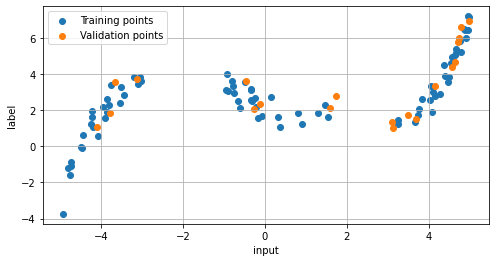

FOLD 3
Trail with dropout:0.2299860127874589, adam_lr:0.004965222074369671, weight_decay:5.53928543130121e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.389822959899902
AVERAGE VAL LOSS: 7.499644756317139
# EPOCH 2
AVERAGE TRAIN LOSS: 5.8596673011779785
AVERAGE VAL LOSS: 3.730828046798706
# EPOCH 3
AVERAGE TRAIN LOSS: 3.1196506023406982
AVERAGE VAL LOSS: 3.3259365558624268
# EPOCH 4
AVERAGE TRAIN LOSS: 3.4582858085632324
AVERAGE VAL LOSS: 3.1822760105133057
# EPOCH 5
AVERAGE TRAIN LOSS: 3.2555885314941406
AVERAGE VAL LOSS: 3.6169300079345703
# EPOCH 6
AVERAGE TRAIN LOSS: 2.5131688117980957
AVERAGE VAL LOSS: 4.009836673736572
# EPOCH 7
AVERAGE TRAIN LOSS: 2.757336139678955
AVERAGE VAL LOSS: 3.2750744819641113
# EPOCH 8
AVERAGE TRAIN LOSS: 2.5994086265563965
AVERAGE VAL LOSS: 2.366133213043213
# EPOCH 9
AVERAGE TRAIN LOSS: 2.187715530395508
AVERAGE VAL LOSS: 2.1231343746185303
# EPOCH 10
AVERAGE TRAIN LOSS: 2.1644909381866455
AVERAGE VAL LOSS: 2.1746714115142822
# EPOCH 11
AVERAGE TRAIN LOSS: 2.359

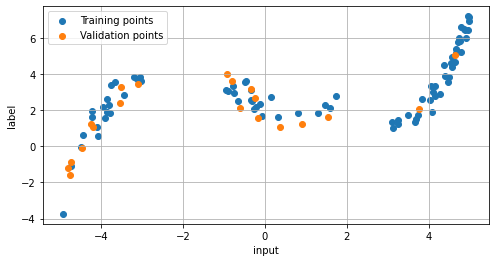

FOLD 4
Trail with dropout:0.2299860127874589, adam_lr:0.004965222074369671, weight_decay:5.53928543130121e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 7.297456741333008
AVERAGE VAL LOSS: 7.298917293548584
# EPOCH 2
AVERAGE TRAIN LOSS: 4.876898765563965
AVERAGE VAL LOSS: 4.507101535797119
# EPOCH 3
AVERAGE TRAIN LOSS: 3.861196994781494
AVERAGE VAL LOSS: 3.0665829181671143
# EPOCH 4
AVERAGE TRAIN LOSS: 3.368767261505127
AVERAGE VAL LOSS: 2.3897509574890137
# EPOCH 5
AVERAGE TRAIN LOSS: 3.3843069076538086
AVERAGE VAL LOSS: 2.1443450450897217
# EPOCH 6
AVERAGE TRAIN LOSS: 2.8386993408203125
AVERAGE VAL LOSS: 2.5767722129821777
# EPOCH 7
AVERAGE TRAIN LOSS: 2.3884048461914062
AVERAGE VAL LOSS: 3.0329220294952393
# EPOCH 8
AVERAGE TRAIN LOSS: 2.834465742111206
AVERAGE VAL LOSS: 2.8351378440856934
# EPOCH 9
AVERAGE TRAIN LOSS: 2.474915027618408
AVERAGE VAL LOSS: 2.0907981395721436
# EPOCH 10
AVERAGE TRAIN LOSS: 2.1734871864318848
AVERAGE VAL LOSS: 1.6598999500274658
# EPOCH 11
AVERAGE TRAIN LOSS: 2.1107

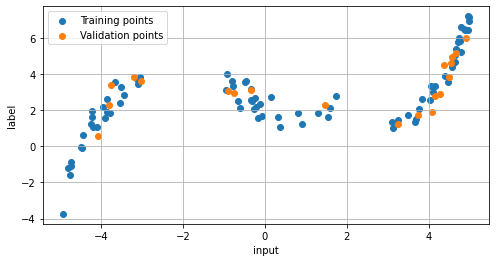

FOLD 5
Trail with dropout:0.2299860127874589, adam_lr:0.004965222074369671, weight_decay:5.53928543130121e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 7.29435920715332
AVERAGE VAL LOSS: 4.879266738891602
# EPOCH 2
AVERAGE TRAIN LOSS: 4.9584150314331055
AVERAGE VAL LOSS: 2.693856954574585
# EPOCH 3
AVERAGE TRAIN LOSS: 3.1976842880249023
AVERAGE VAL LOSS: 2.8201003074645996
# EPOCH 4
AVERAGE TRAIN LOSS: 3.4701900482177734
AVERAGE VAL LOSS: 2.531240940093994
# EPOCH 5
AVERAGE TRAIN LOSS: 3.3347432613372803
AVERAGE VAL LOSS: 2.1907601356506348
# EPOCH 6
AVERAGE TRAIN LOSS: 2.9648356437683105
AVERAGE VAL LOSS: 2.0865676403045654
# EPOCH 7
AVERAGE TRAIN LOSS: 2.480797290802002
AVERAGE VAL LOSS: 1.6530426740646362
# EPOCH 8
AVERAGE TRAIN LOSS: 2.544735908508301
AVERAGE VAL LOSS: 1.5172340869903564
# EPOCH 9
AVERAGE TRAIN LOSS: 2.2121946811676025
AVERAGE VAL LOSS: 1.5015054941177368
# EPOCH 10
AVERAGE TRAIN LOSS: 2.2946529388427734
AVERAGE VAL LOSS: 1.513146162033081
# EPOCH 11
AVERAGE TRAIN LOSS: 2.0486

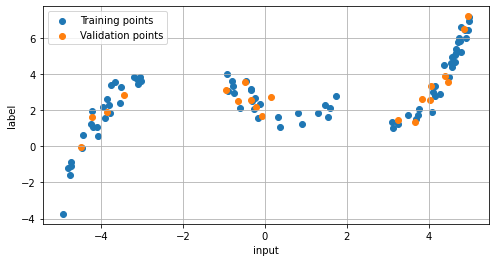

[I 2021-12-31 15:29:54,795] Trial 1 finished with value: 0.1938641369342804 and parameters: {'n_units_l0': 248, 'n_units_l1': 135, 'dropout': 0.2299860127874589, 'lr': 0.004965222074369671, 'weight_decay': 5.53928543130121e-05}. Best is trial 0 with value: 0.07817257195711136.


FOLD 1
Trail with dropout:0.0841429068235593, adam_lr:0.006601055029315029, weight_decay:5.0570278512699826e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.749691009521484
AVERAGE VAL LOSS: 5.5565409660339355
# EPOCH 2
AVERAGE TRAIN LOSS: 3.990945816040039
AVERAGE VAL LOSS: 4.129036903381348
# EPOCH 3
AVERAGE TRAIN LOSS: 3.744260787963867
AVERAGE VAL LOSS: 3.3571248054504395
# EPOCH 4
AVERAGE TRAIN LOSS: 2.774077892303467
AVERAGE VAL LOSS: 4.1681365966796875
# EPOCH 5
AVERAGE TRAIN LOSS: 2.7535061836242676
AVERAGE VAL LOSS: 4.306808948516846
# EPOCH 6
AVERAGE TRAIN LOSS: 2.4892446994781494
AVERAGE VAL LOSS: 4.200179576873779
# EPOCH 7
AVERAGE TRAIN LOSS: 2.1101205348968506
AVERAGE VAL LOSS: 3.3587396144866943
# EPOCH 8
AVERAGE TRAIN LOSS: 1.9133081436157227
AVERAGE VAL LOSS: 2.486023426055908
# EPOCH 9
AVERAGE TRAIN LOSS: 1.9294333457946777
AVERAGE VAL LOSS: 2.3169631958007812
# EPOCH 10
AVERAGE TRAIN LOSS: 1.6620230674743652
AVERAGE VAL LOSS: 2.8037757873535156
# EPOCH 11
AVERAGE TRAIN LOSS: 1.64

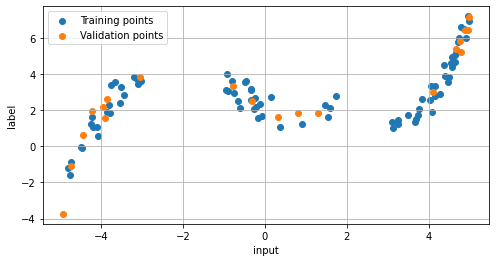

FOLD 2
Trail with dropout:0.0841429068235593, adam_lr:0.006601055029315029, weight_decay:5.0570278512699826e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 7.707756042480469
AVERAGE VAL LOSS: 2.4938950538635254
# EPOCH 2
AVERAGE TRAIN LOSS: 4.016729354858398
AVERAGE VAL LOSS: 4.14321756362915
# EPOCH 3
AVERAGE TRAIN LOSS: 3.8120813369750977
AVERAGE VAL LOSS: 2.7021937370300293
# EPOCH 4
AVERAGE TRAIN LOSS: 2.817077398300171
AVERAGE VAL LOSS: 2.6392529010772705
# EPOCH 5
AVERAGE TRAIN LOSS: 2.6867599487304688
AVERAGE VAL LOSS: 2.590019941329956
# EPOCH 6
AVERAGE TRAIN LOSS: 2.736422061920166
AVERAGE VAL LOSS: 2.2241082191467285
# EPOCH 7
AVERAGE TRAIN LOSS: 2.2586424350738525
AVERAGE VAL LOSS: 2.1775741577148438
# EPOCH 8
AVERAGE TRAIN LOSS: 2.1716456413269043
AVERAGE VAL LOSS: 2.310037612915039
# EPOCH 9
AVERAGE TRAIN LOSS: 2.0803275108337402
AVERAGE VAL LOSS: 1.8294439315795898
# EPOCH 10
AVERAGE TRAIN LOSS: 1.7413158416748047
AVERAGE VAL LOSS: 1.872315764427185
# EPOCH 11
AVERAGE TRAIN LOSS: 1.648

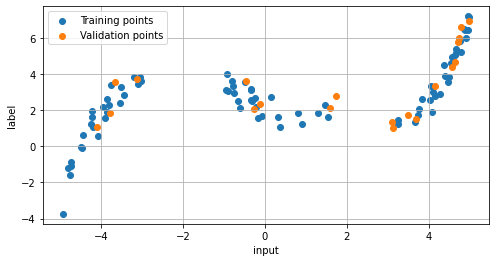

FOLD 3
Trail with dropout:0.0841429068235593, adam_lr:0.006601055029315029, weight_decay:5.0570278512699826e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.213168144226074
AVERAGE VAL LOSS: 11.30640697479248
# EPOCH 2
AVERAGE TRAIN LOSS: 5.270992755889893
AVERAGE VAL LOSS: 5.953231334686279
# EPOCH 3
AVERAGE TRAIN LOSS: 4.5504913330078125
AVERAGE VAL LOSS: 3.364051103591919
# EPOCH 4
AVERAGE TRAIN LOSS: 3.751497745513916
AVERAGE VAL LOSS: 3.193073034286499
# EPOCH 5
AVERAGE TRAIN LOSS: 3.348237991333008
AVERAGE VAL LOSS: 2.9523422718048096
# EPOCH 6
AVERAGE TRAIN LOSS: 3.0773720741271973
AVERAGE VAL LOSS: 3.711979389190674
# EPOCH 7
AVERAGE TRAIN LOSS: 3.1760544776916504
AVERAGE VAL LOSS: 4.94241189956665
# EPOCH 8
AVERAGE TRAIN LOSS: 2.9922900199890137
AVERAGE VAL LOSS: 4.113508701324463
# EPOCH 9
AVERAGE TRAIN LOSS: 2.45172119140625
AVERAGE VAL LOSS: 2.9915003776550293
# EPOCH 10
AVERAGE TRAIN LOSS: 2.161677122116089
AVERAGE VAL LOSS: 2.350555181503296
# EPOCH 11
AVERAGE TRAIN LOSS: 2.342061996

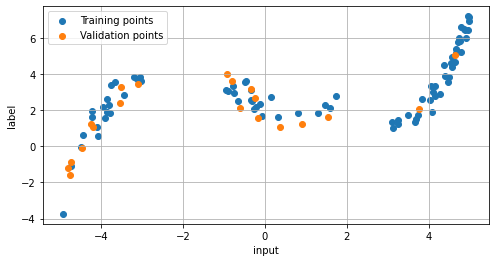

FOLD 4
Trail with dropout:0.0841429068235593, adam_lr:0.006601055029315029, weight_decay:5.0570278512699826e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.2076416015625
AVERAGE VAL LOSS: 2.620488405227661
# EPOCH 2
AVERAGE TRAIN LOSS: 3.2545974254608154
AVERAGE VAL LOSS: 5.877651214599609
# EPOCH 3
AVERAGE TRAIN LOSS: 3.826953411102295
AVERAGE VAL LOSS: 3.8566157817840576
# EPOCH 4
AVERAGE TRAIN LOSS: 2.7046573162078857
AVERAGE VAL LOSS: 2.4222841262817383
# EPOCH 5
AVERAGE TRAIN LOSS: 2.435573101043701
AVERAGE VAL LOSS: 1.7904027700424194
# EPOCH 6
AVERAGE TRAIN LOSS: 2.545607089996338
AVERAGE VAL LOSS: 1.5354899168014526
# EPOCH 7
AVERAGE TRAIN LOSS: 2.3105950355529785
AVERAGE VAL LOSS: 1.5206748247146606
# EPOCH 8
AVERAGE TRAIN LOSS: 1.868903636932373
AVERAGE VAL LOSS: 2.198127508163452
# EPOCH 9
AVERAGE TRAIN LOSS: 2.0851995944976807
AVERAGE VAL LOSS: 2.4997801780700684
# EPOCH 10
AVERAGE TRAIN LOSS: 1.965838074684143
AVERAGE VAL LOSS: 1.8854798078536987
# EPOCH 11
AVERAGE TRAIN LOSS: 1.74395

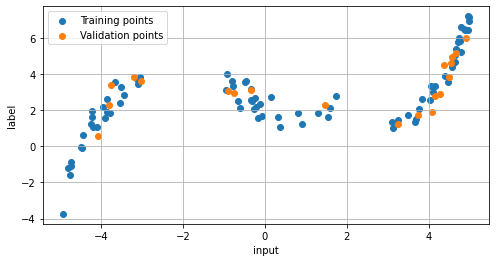

FOLD 5
Trail with dropout:0.0841429068235593, adam_lr:0.006601055029315029, weight_decay:5.0570278512699826e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.322608947753906
AVERAGE VAL LOSS: 3.1226775646209717
# EPOCH 2
AVERAGE TRAIN LOSS: 4.375494956970215
AVERAGE VAL LOSS: 3.516951322555542
# EPOCH 3
AVERAGE TRAIN LOSS: 3.345034599304199
AVERAGE VAL LOSS: 2.314892292022705
# EPOCH 4
AVERAGE TRAIN LOSS: 3.025930404663086
AVERAGE VAL LOSS: 2.3086845874786377
# EPOCH 5
AVERAGE TRAIN LOSS: 3.188011884689331
AVERAGE VAL LOSS: 1.86602783203125
# EPOCH 6
AVERAGE TRAIN LOSS: 2.5780832767486572
AVERAGE VAL LOSS: 1.6129932403564453
# EPOCH 7
AVERAGE TRAIN LOSS: 2.4379560947418213
AVERAGE VAL LOSS: 1.7479857206344604
# EPOCH 8
AVERAGE TRAIN LOSS: 2.333230972290039
AVERAGE VAL LOSS: 1.7440569400787354
# EPOCH 9
AVERAGE TRAIN LOSS: 2.163689374923706
AVERAGE VAL LOSS: 1.4448028802871704
# EPOCH 10
AVERAGE TRAIN LOSS: 1.935765027999878
AVERAGE VAL LOSS: 1.2772128582000732
# EPOCH 11
AVERAGE TRAIN LOSS: 1.868291

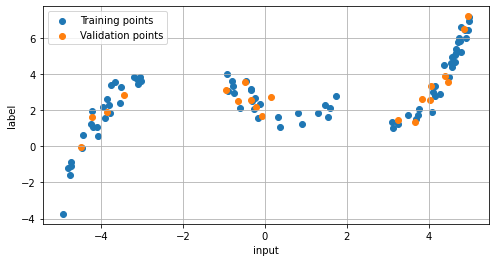

[I 2021-12-31 15:32:53,760] Trial 2 finished with value: 0.10564915835857391 and parameters: {'n_units_l0': 57, 'n_units_l1': 292, 'dropout': 0.0841429068235593, 'lr': 0.006601055029315029, 'weight_decay': 5.0570278512699826e-05}. Best is trial 0 with value: 0.07817257195711136.


FOLD 1
Trail with dropout:0.21755906897029054, adam_lr:0.007835439192829717, weight_decay:8.150828165753842e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.542020797729492
AVERAGE VAL LOSS: 6.348969459533691
# EPOCH 2
AVERAGE TRAIN LOSS: 4.937488079071045
AVERAGE VAL LOSS: 4.91369104385376
# EPOCH 3
AVERAGE TRAIN LOSS: 4.182562351226807
AVERAGE VAL LOSS: 5.716421604156494
# EPOCH 4
AVERAGE TRAIN LOSS: 3.721200704574585
AVERAGE VAL LOSS: 3.5522918701171875
# EPOCH 5
AVERAGE TRAIN LOSS: 3.4017550945281982
AVERAGE VAL LOSS: 3.127919912338257
# EPOCH 6
AVERAGE TRAIN LOSS: 3.09598445892334
AVERAGE VAL LOSS: 4.265563011169434
# EPOCH 7
AVERAGE TRAIN LOSS: 2.9298667907714844
AVERAGE VAL LOSS: 5.342423439025879
# EPOCH 8
AVERAGE TRAIN LOSS: 2.7051570415496826
AVERAGE VAL LOSS: 5.0293498039245605
# EPOCH 9
AVERAGE TRAIN LOSS: 2.6662087440490723
AVERAGE VAL LOSS: 3.613396167755127
# EPOCH 10
AVERAGE TRAIN LOSS: 2.4971542358398438
AVERAGE VAL LOSS: 3.0475990772247314
# EPOCH 11
AVERAGE TRAIN LOSS: 2.4506626

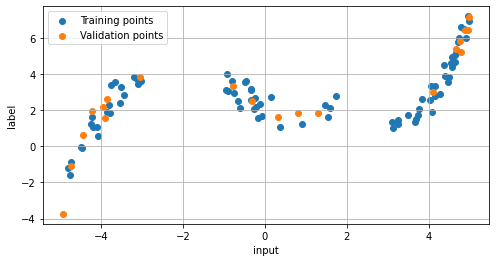

FOLD 2
Trail with dropout:0.21755906897029054, adam_lr:0.007835439192829717, weight_decay:8.150828165753842e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.176910400390625
AVERAGE VAL LOSS: 5.984460830688477
# EPOCH 2
AVERAGE TRAIN LOSS: 5.502982139587402
AVERAGE VAL LOSS: 3.240520477294922
# EPOCH 3
AVERAGE TRAIN LOSS: 3.9543848037719727
AVERAGE VAL LOSS: 4.1493120193481445
# EPOCH 4
AVERAGE TRAIN LOSS: 4.046873092651367
AVERAGE VAL LOSS: 2.8252198696136475
# EPOCH 5
AVERAGE TRAIN LOSS: 3.1338045597076416
AVERAGE VAL LOSS: 2.2373058795928955
# EPOCH 6
AVERAGE TRAIN LOSS: 3.155243396759033
AVERAGE VAL LOSS: 2.257012128829956
# EPOCH 7
AVERAGE TRAIN LOSS: 2.6645865440368652
AVERAGE VAL LOSS: 2.2626287937164307
# EPOCH 8
AVERAGE TRAIN LOSS: 2.340150833129883
AVERAGE VAL LOSS: 2.4503018856048584
# EPOCH 9
AVERAGE TRAIN LOSS: 2.6104660034179688
AVERAGE VAL LOSS: 2.3775532245635986
# EPOCH 10
AVERAGE TRAIN LOSS: 2.4433794021606445
AVERAGE VAL LOSS: 1.9228849411010742
# EPOCH 11
AVERAGE TRAIN LOSS: 2.6

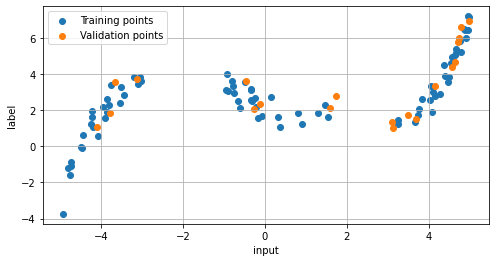

FOLD 3
Trail with dropout:0.21755906897029054, adam_lr:0.007835439192829717, weight_decay:8.150828165753842e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 12.802692413330078
AVERAGE VAL LOSS: 7.679446697235107
# EPOCH 2
AVERAGE TRAIN LOSS: 5.161509037017822
AVERAGE VAL LOSS: 4.050775051116943
# EPOCH 3
AVERAGE TRAIN LOSS: 4.071016311645508
AVERAGE VAL LOSS: 3.934131622314453
# EPOCH 4
AVERAGE TRAIN LOSS: 3.614452362060547
AVERAGE VAL LOSS: 4.396214485168457
# EPOCH 5
AVERAGE TRAIN LOSS: 4.036872386932373
AVERAGE VAL LOSS: 5.099272727966309
# EPOCH 6
AVERAGE TRAIN LOSS: 3.3828680515289307
AVERAGE VAL LOSS: 4.159545421600342
# EPOCH 7
AVERAGE TRAIN LOSS: 3.099090099334717
AVERAGE VAL LOSS: 3.497166395187378
# EPOCH 8
AVERAGE TRAIN LOSS: 3.063584804534912
AVERAGE VAL LOSS: 3.1093692779541016
# EPOCH 9
AVERAGE TRAIN LOSS: 2.8302502632141113
AVERAGE VAL LOSS: 2.854034423828125
# EPOCH 10
AVERAGE TRAIN LOSS: 2.7842929363250732
AVERAGE VAL LOSS: 2.8126142024993896
# EPOCH 11
AVERAGE TRAIN LOSS: 2.73640465

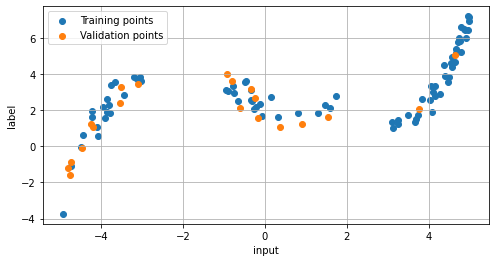

FOLD 4
Trail with dropout:0.21755906897029054, adam_lr:0.007835439192829717, weight_decay:8.150828165753842e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.56884765625
AVERAGE VAL LOSS: 5.224208831787109
# EPOCH 2
AVERAGE TRAIN LOSS: 4.825343132019043
AVERAGE VAL LOSS: 4.690441608428955
# EPOCH 3
AVERAGE TRAIN LOSS: 4.195342063903809
AVERAGE VAL LOSS: 3.9527747631073
# EPOCH 4
AVERAGE TRAIN LOSS: 4.057387828826904
AVERAGE VAL LOSS: 2.4318456649780273
# EPOCH 5
AVERAGE TRAIN LOSS: 3.5927581787109375
AVERAGE VAL LOSS: 2.4597887992858887
# EPOCH 6
AVERAGE TRAIN LOSS: 3.3730671405792236
AVERAGE VAL LOSS: 2.8656904697418213
# EPOCH 7
AVERAGE TRAIN LOSS: 2.969715118408203
AVERAGE VAL LOSS: 2.9312820434570312
# EPOCH 8
AVERAGE TRAIN LOSS: 3.091050863265991
AVERAGE VAL LOSS: 2.7905781269073486
# EPOCH 9
AVERAGE TRAIN LOSS: 2.8942389488220215
AVERAGE VAL LOSS: 2.41581654548645
# EPOCH 10
AVERAGE TRAIN LOSS: 2.3755578994750977
AVERAGE VAL LOSS: 1.9753865003585815
# EPOCH 11
AVERAGE TRAIN LOSS: 2.5068268775

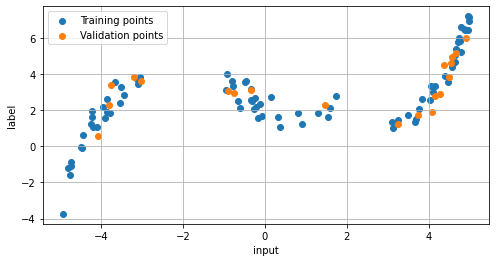

FOLD 5
Trail with dropout:0.21755906897029054, adam_lr:0.007835439192829717, weight_decay:8.150828165753842e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 13.730226516723633
AVERAGE VAL LOSS: 4.713069438934326
# EPOCH 2
AVERAGE TRAIN LOSS: 5.4840803146362305
AVERAGE VAL LOSS: 3.9472005367279053
# EPOCH 3
AVERAGE TRAIN LOSS: 4.421773910522461
AVERAGE VAL LOSS: 4.041278839111328
# EPOCH 4
AVERAGE TRAIN LOSS: 4.155516624450684
AVERAGE VAL LOSS: 3.4145333766937256
# EPOCH 5
AVERAGE TRAIN LOSS: 3.976548671722412
AVERAGE VAL LOSS: 3.968747854232788
# EPOCH 6
AVERAGE TRAIN LOSS: 4.225652694702148
AVERAGE VAL LOSS: 3.074277877807617
# EPOCH 7
AVERAGE TRAIN LOSS: 3.499516487121582
AVERAGE VAL LOSS: 3.0361342430114746
# EPOCH 8
AVERAGE TRAIN LOSS: 3.4144508838653564
AVERAGE VAL LOSS: 2.9884302616119385
# EPOCH 9
AVERAGE TRAIN LOSS: 3.618366241455078
AVERAGE VAL LOSS: 2.77423095703125
# EPOCH 10
AVERAGE TRAIN LOSS: 3.1767964363098145
AVERAGE VAL LOSS: 2.9841785430908203
# EPOCH 11
AVERAGE TRAIN LOSS: 3.633443

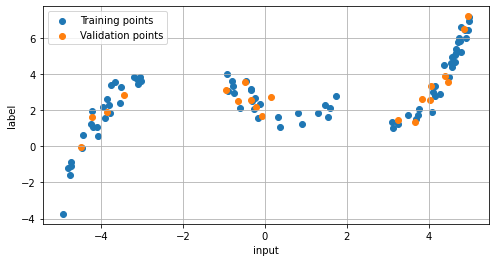

[I 2021-12-31 15:36:02,513] Trial 3 finished with value: 0.3272657096385956 and parameters: {'n_units_l0': 289, 'n_units_l1': 99, 'dropout': 0.21755906897029054, 'lr': 0.007835439192829717, 'weight_decay': 8.150828165753842e-05}. Best is trial 0 with value: 0.07817257195711136.


FOLD 1
Trail with dropout:0.0231830376279673, adam_lr:0.002229585169001085, weight_decay:2.1313202178234238e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.97456169128418
AVERAGE VAL LOSS: 8.739922523498535
# EPOCH 2
AVERAGE TRAIN LOSS: 4.52903413772583
AVERAGE VAL LOSS: 5.311059474945068
# EPOCH 3
AVERAGE TRAIN LOSS: 3.2737410068511963
AVERAGE VAL LOSS: 4.180368900299072
# EPOCH 4
AVERAGE TRAIN LOSS: 3.6291985511779785
AVERAGE VAL LOSS: 3.8310539722442627
# EPOCH 5
AVERAGE TRAIN LOSS: 3.7368979454040527
AVERAGE VAL LOSS: 3.188035011291504
# EPOCH 6
AVERAGE TRAIN LOSS: 3.172346830368042
AVERAGE VAL LOSS: 2.9120757579803467
# EPOCH 7
AVERAGE TRAIN LOSS: 2.5819034576416016
AVERAGE VAL LOSS: 3.1236801147460938
# EPOCH 8
AVERAGE TRAIN LOSS: 2.4272916316986084
AVERAGE VAL LOSS: 3.6489853858947754
# EPOCH 9
AVERAGE TRAIN LOSS: 2.2780020236968994
AVERAGE VAL LOSS: 4.058346271514893
# EPOCH 10
AVERAGE TRAIN LOSS: 2.229351043701172
AVERAGE VAL LOSS: 4.289381504058838
# EPOCH 11
AVERAGE TRAIN LOSS: 2.164319

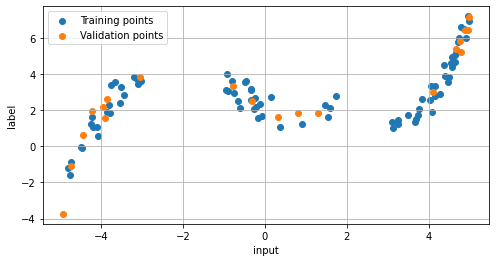

FOLD 2
Trail with dropout:0.0231830376279673, adam_lr:0.002229585169001085, weight_decay:2.1313202178234238e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.62004280090332
AVERAGE VAL LOSS: 6.838540554046631
# EPOCH 2
AVERAGE TRAIN LOSS: 5.162087917327881
AVERAGE VAL LOSS: 2.732459783554077
# EPOCH 3
AVERAGE TRAIN LOSS: 3.3209640979766846
AVERAGE VAL LOSS: 2.795827627182007
# EPOCH 4
AVERAGE TRAIN LOSS: 3.604649066925049
AVERAGE VAL LOSS: 3.8243539333343506
# EPOCH 5
AVERAGE TRAIN LOSS: 4.019768238067627
AVERAGE VAL LOSS: 3.649510622024536
# EPOCH 6
AVERAGE TRAIN LOSS: 3.453268527984619
AVERAGE VAL LOSS: 3.033414602279663
# EPOCH 7
AVERAGE TRAIN LOSS: 2.8666269779205322
AVERAGE VAL LOSS: 2.596263885498047
# EPOCH 8
AVERAGE TRAIN LOSS: 2.5588858127593994
AVERAGE VAL LOSS: 2.439439058303833
# EPOCH 9
AVERAGE TRAIN LOSS: 2.5771608352661133
AVERAGE VAL LOSS: 2.489132881164551
# EPOCH 10
AVERAGE TRAIN LOSS: 2.4551360607147217
AVERAGE VAL LOSS: 2.4877781867980957
# EPOCH 11
AVERAGE TRAIN LOSS: 2.4017879

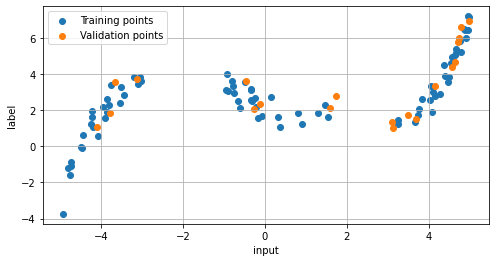

FOLD 3
Trail with dropout:0.0231830376279673, adam_lr:0.002229585169001085, weight_decay:2.1313202178234238e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 13.804338455200195
AVERAGE VAL LOSS: 4.60498046875
# EPOCH 2
AVERAGE TRAIN LOSS: 5.901930809020996
AVERAGE VAL LOSS: 4.755890846252441
# EPOCH 3
AVERAGE TRAIN LOSS: 3.1984875202178955
AVERAGE VAL LOSS: 6.0471343994140625
# EPOCH 4
AVERAGE TRAIN LOSS: 3.4241456985473633
AVERAGE VAL LOSS: 6.11020565032959
# EPOCH 5
AVERAGE TRAIN LOSS: 4.109386444091797
AVERAGE VAL LOSS: 4.931750774383545
# EPOCH 6
AVERAGE TRAIN LOSS: 3.8568601608276367
AVERAGE VAL LOSS: 3.7933239936828613
# EPOCH 7
AVERAGE TRAIN LOSS: 3.0873594284057617
AVERAGE VAL LOSS: 3.1653149127960205
# EPOCH 8
AVERAGE TRAIN LOSS: 2.731295108795166
AVERAGE VAL LOSS: 2.8392837047576904
# EPOCH 9
AVERAGE TRAIN LOSS: 2.617990493774414
AVERAGE VAL LOSS: 2.693265676498413
# EPOCH 10
AVERAGE TRAIN LOSS: 2.6003851890563965
AVERAGE VAL LOSS: 2.6740329265594482
# EPOCH 11
AVERAGE TRAIN LOSS: 2.47908163

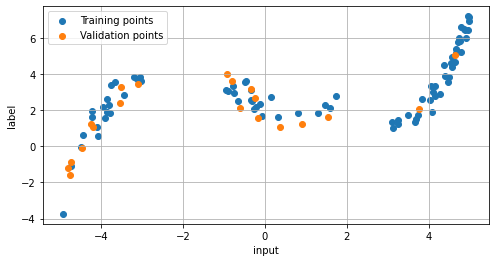

FOLD 4
Trail with dropout:0.0231830376279673, adam_lr:0.002229585169001085, weight_decay:2.1313202178234238e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.79125690460205
AVERAGE VAL LOSS: 3.5031182765960693
# EPOCH 2
AVERAGE TRAIN LOSS: 4.104040145874023
AVERAGE VAL LOSS: 2.2214484214782715
# EPOCH 3
AVERAGE TRAIN LOSS: 3.2709546089172363
AVERAGE VAL LOSS: 4.086452484130859
# EPOCH 4
AVERAGE TRAIN LOSS: 3.4481241703033447
AVERAGE VAL LOSS: 5.287293910980225
# EPOCH 5
AVERAGE TRAIN LOSS: 3.708251476287842
AVERAGE VAL LOSS: 4.941261291503906
# EPOCH 6
AVERAGE TRAIN LOSS: 3.197065591812134
AVERAGE VAL LOSS: 3.699207305908203
# EPOCH 7
AVERAGE TRAIN LOSS: 2.721064567565918
AVERAGE VAL LOSS: 2.6251895427703857
# EPOCH 8
AVERAGE TRAIN LOSS: 2.427056074142456
AVERAGE VAL LOSS: 2.0038464069366455
# EPOCH 9
AVERAGE TRAIN LOSS: 2.451124429702759
AVERAGE VAL LOSS: 1.7805709838867188
# EPOCH 10
AVERAGE TRAIN LOSS: 2.5479767322540283
AVERAGE VAL LOSS: 1.7229961156845093
# EPOCH 11
AVERAGE TRAIN LOSS: 2.435200

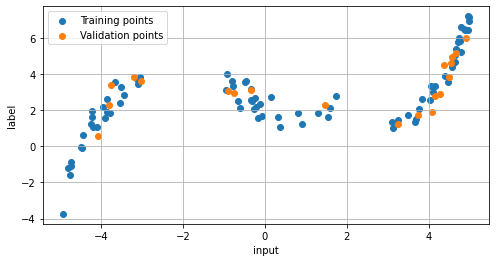

FOLD 5
Trail with dropout:0.0231830376279673, adam_lr:0.002229585169001085, weight_decay:2.1313202178234238e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.54470157623291
AVERAGE VAL LOSS: 3.799255847930908
# EPOCH 2
AVERAGE TRAIN LOSS: 4.110734939575195
AVERAGE VAL LOSS: 3.0369415283203125
# EPOCH 3
AVERAGE TRAIN LOSS: 3.617448091506958
AVERAGE VAL LOSS: 4.105896949768066
# EPOCH 4
AVERAGE TRAIN LOSS: 4.341770648956299
AVERAGE VAL LOSS: 3.9723145961761475
# EPOCH 5
AVERAGE TRAIN LOSS: 3.867255449295044
AVERAGE VAL LOSS: 3.091305732727051
# EPOCH 6
AVERAGE TRAIN LOSS: 3.151017665863037
AVERAGE VAL LOSS: 2.5019378662109375
# EPOCH 7
AVERAGE TRAIN LOSS: 2.809803009033203
AVERAGE VAL LOSS: 2.268296241760254
# EPOCH 8
AVERAGE TRAIN LOSS: 2.8289730548858643
AVERAGE VAL LOSS: 2.1876308917999268
# EPOCH 9
AVERAGE TRAIN LOSS: 2.8549814224243164
AVERAGE VAL LOSS: 2.067068338394165
# EPOCH 10
AVERAGE TRAIN LOSS: 2.8003082275390625
AVERAGE VAL LOSS: 1.894274115562439
# EPOCH 11
AVERAGE TRAIN LOSS: 2.58010506

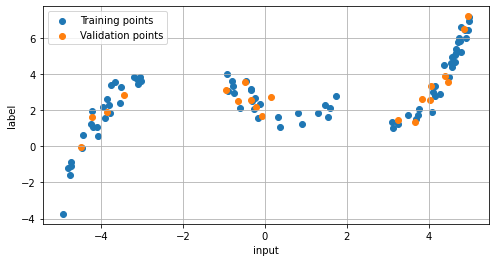

[I 2021-12-31 15:39:25,679] Trial 4 finished with value: 0.13104791939258575 and parameters: {'n_units_l0': 69, 'n_units_l1': 264, 'dropout': 0.0231830376279673, 'lr': 0.002229585169001085, 'weight_decay': 2.1313202178234238e-05}. Best is trial 0 with value: 0.07817257195711136.


FOLD 1
Trail with dropout:0.2606847549036372, adam_lr:0.007538643716065459, weight_decay:4.7696192203271005e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.03547191619873
AVERAGE VAL LOSS: 6.981828212738037
# EPOCH 2
AVERAGE TRAIN LOSS: 3.661578893661499
AVERAGE VAL LOSS: 3.263798475265503
# EPOCH 3
AVERAGE TRAIN LOSS: 3.1668097972869873
AVERAGE VAL LOSS: 4.471262454986572
# EPOCH 4
AVERAGE TRAIN LOSS: 3.4768145084381104
AVERAGE VAL LOSS: 4.1100897789001465
# EPOCH 5
AVERAGE TRAIN LOSS: 2.703948974609375
AVERAGE VAL LOSS: 3.2662174701690674
# EPOCH 6
AVERAGE TRAIN LOSS: 2.732138156890869
AVERAGE VAL LOSS: 3.8726024627685547
# EPOCH 7
AVERAGE TRAIN LOSS: 2.699951171875
AVERAGE VAL LOSS: 3.629474401473999
# EPOCH 8
AVERAGE TRAIN LOSS: 2.092984676361084
AVERAGE VAL LOSS: 4.0224761962890625
# EPOCH 9
AVERAGE TRAIN LOSS: 2.43019962310791
AVERAGE VAL LOSS: 3.982767105102539
# EPOCH 10
AVERAGE TRAIN LOSS: 1.9951196908950806
AVERAGE VAL LOSS: 3.2450006008148193
# EPOCH 11
AVERAGE TRAIN LOSS: 1.81372046470

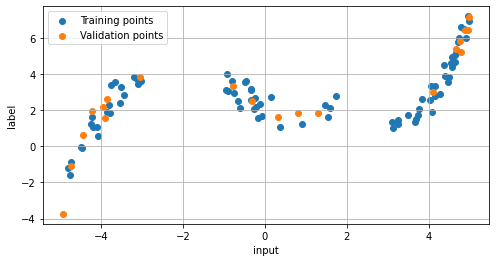

FOLD 2
Trail with dropout:0.2606847549036372, adam_lr:0.007538643716065459, weight_decay:4.7696192203271005e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.849994659423828
AVERAGE VAL LOSS: 9.729620933532715
# EPOCH 2
AVERAGE TRAIN LOSS: 10.879453659057617
AVERAGE VAL LOSS: 2.3349220752716064
# EPOCH 3
AVERAGE TRAIN LOSS: 3.2917661666870117
AVERAGE VAL LOSS: 3.9871270656585693
# EPOCH 4
AVERAGE TRAIN LOSS: 4.256109237670898
AVERAGE VAL LOSS: 4.3185014724731445
# EPOCH 5
AVERAGE TRAIN LOSS: 3.951608419418335
AVERAGE VAL LOSS: 3.162083148956299
# EPOCH 6
AVERAGE TRAIN LOSS: 3.2391717433929443
AVERAGE VAL LOSS: 2.5807480812072754
# EPOCH 7
AVERAGE TRAIN LOSS: 3.053673267364502
AVERAGE VAL LOSS: 2.4071929454803467
# EPOCH 8
AVERAGE TRAIN LOSS: 3.3495469093322754
AVERAGE VAL LOSS: 2.1736128330230713
# EPOCH 9
AVERAGE TRAIN LOSS: 2.8648338317871094
AVERAGE VAL LOSS: 2.3550593852996826
# EPOCH 10
AVERAGE TRAIN LOSS: 3.0391907691955566
AVERAGE VAL LOSS: 2.7523446083068848
# EPOCH 11
AVERAGE TRAIN LOSS: 2.

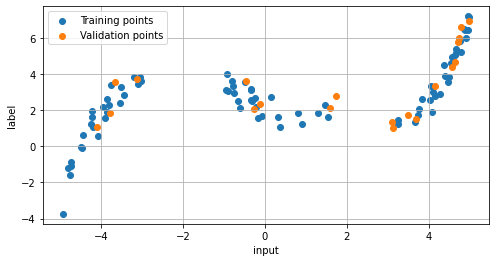

FOLD 3
Trail with dropout:0.2606847549036372, adam_lr:0.007538643716065459, weight_decay:4.7696192203271005e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.261777877807617
AVERAGE VAL LOSS: 10.983499526977539
# EPOCH 2
AVERAGE TRAIN LOSS: 6.010351181030273
AVERAGE VAL LOSS: 3.4346091747283936
# EPOCH 3
AVERAGE TRAIN LOSS: 3.215092182159424
AVERAGE VAL LOSS: 3.6064414978027344
# EPOCH 4
AVERAGE TRAIN LOSS: 3.9588208198547363
AVERAGE VAL LOSS: 3.2916696071624756
# EPOCH 5
AVERAGE TRAIN LOSS: 3.000863552093506
AVERAGE VAL LOSS: 3.530966281890869
# EPOCH 6
AVERAGE TRAIN LOSS: 3.1998541355133057
AVERAGE VAL LOSS: 4.118371963500977
# EPOCH 7
AVERAGE TRAIN LOSS: 2.793765068054199
AVERAGE VAL LOSS: 3.9707131385803223
# EPOCH 8
AVERAGE TRAIN LOSS: 2.5081188678741455
AVERAGE VAL LOSS: 3.285493850708008
# EPOCH 9
AVERAGE TRAIN LOSS: 2.539881944656372
AVERAGE VAL LOSS: 2.6086485385894775
# EPOCH 10
AVERAGE TRAIN LOSS: 2.304837226867676
AVERAGE VAL LOSS: 2.2634854316711426
# EPOCH 11
AVERAGE TRAIN LOSS: 2.0578

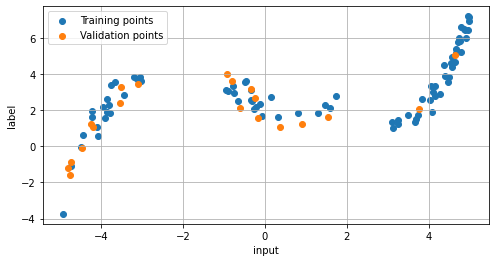

FOLD 4
Trail with dropout:0.2606847549036372, adam_lr:0.007538643716065459, weight_decay:4.7696192203271005e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.840873718261719
AVERAGE VAL LOSS: 7.689866065979004
# EPOCH 2
AVERAGE TRAIN LOSS: 4.423403739929199
AVERAGE VAL LOSS: 4.382943630218506
# EPOCH 3
AVERAGE TRAIN LOSS: 3.891550064086914
AVERAGE VAL LOSS: 3.9804985523223877
# EPOCH 4
AVERAGE TRAIN LOSS: 3.9361939430236816
AVERAGE VAL LOSS: 2.7813644409179688
# EPOCH 5
AVERAGE TRAIN LOSS: 3.205444812774658
AVERAGE VAL LOSS: 2.4236631393432617
# EPOCH 6
AVERAGE TRAIN LOSS: 3.0686540603637695
AVERAGE VAL LOSS: 2.2411913871765137
# EPOCH 7
AVERAGE TRAIN LOSS: 2.7642035484313965
AVERAGE VAL LOSS: 2.317014694213867
# EPOCH 8
AVERAGE TRAIN LOSS: 3.1237659454345703
AVERAGE VAL LOSS: 2.5372474193573
# EPOCH 9
AVERAGE TRAIN LOSS: 2.403470993041992
AVERAGE VAL LOSS: 2.309019088745117
# EPOCH 10
AVERAGE TRAIN LOSS: 2.502689838409424
AVERAGE VAL LOSS: 1.8423200845718384
# EPOCH 11
AVERAGE TRAIN LOSS: 2.182590

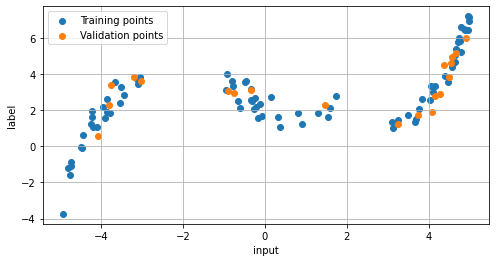

FOLD 5
Trail with dropout:0.2606847549036372, adam_lr:0.007538643716065459, weight_decay:4.7696192203271005e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.75854778289795
AVERAGE VAL LOSS: 7.346052646636963
# EPOCH 2
AVERAGE TRAIN LOSS: 5.880781173706055
AVERAGE VAL LOSS: 3.10203218460083
# EPOCH 3
AVERAGE TRAIN LOSS: 3.8739418983459473
AVERAGE VAL LOSS: 3.7665016651153564
# EPOCH 4
AVERAGE TRAIN LOSS: 4.396797180175781
AVERAGE VAL LOSS: 3.138925313949585
# EPOCH 5
AVERAGE TRAIN LOSS: 3.403296947479248
AVERAGE VAL LOSS: 2.6785502433776855
# EPOCH 6
AVERAGE TRAIN LOSS: 3.429161548614502
AVERAGE VAL LOSS: 2.774080753326416
# EPOCH 7
AVERAGE TRAIN LOSS: 3.674985885620117
AVERAGE VAL LOSS: 2.25885272026062
# EPOCH 8
AVERAGE TRAIN LOSS: 2.8700242042541504
AVERAGE VAL LOSS: 2.257037401199341
# EPOCH 9
AVERAGE TRAIN LOSS: 2.959047794342041
AVERAGE VAL LOSS: 2.2353591918945312
# EPOCH 10
AVERAGE TRAIN LOSS: 2.8209633827209473
AVERAGE VAL LOSS: 2.0851190090179443
# EPOCH 11
AVERAGE TRAIN LOSS: 2.666728734

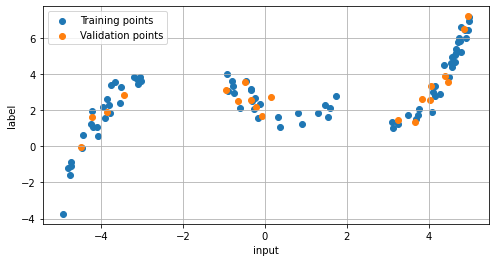

[I 2021-12-31 15:43:04,901] Trial 5 pruned. 


FOLD 1
Trail with dropout:0.48691691607791204, adam_lr:0.0038758182145124565, weight_decay:4.264365308303603e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 7.263848304748535
AVERAGE VAL LOSS: 6.054065227508545
# EPOCH 2
AVERAGE TRAIN LOSS: 4.881587028503418
AVERAGE VAL LOSS: 4.811015605926514
# EPOCH 3
AVERAGE TRAIN LOSS: 4.3702073097229
AVERAGE VAL LOSS: 3.3429150581359863
# EPOCH 4
AVERAGE TRAIN LOSS: 3.07051420211792
AVERAGE VAL LOSS: 4.40054178237915
# EPOCH 5
AVERAGE TRAIN LOSS: 3.295689582824707
AVERAGE VAL LOSS: 4.874468803405762
# EPOCH 6
AVERAGE TRAIN LOSS: 3.260169267654419
AVERAGE VAL LOSS: 4.446418762207031
# EPOCH 7
AVERAGE TRAIN LOSS: 2.4462151527404785
AVERAGE VAL LOSS: 3.896143674850464
# EPOCH 8
AVERAGE TRAIN LOSS: 3.038646936416626
AVERAGE VAL LOSS: 3.3988711833953857
# EPOCH 9
AVERAGE TRAIN LOSS: 2.621018409729004
AVERAGE VAL LOSS: 3.263221025466919
# EPOCH 10
AVERAGE TRAIN LOSS: 2.2703609466552734
AVERAGE VAL LOSS: 3.350238084793091
# EPOCH 11
AVERAGE TRAIN LOSS: 2.3987865447998

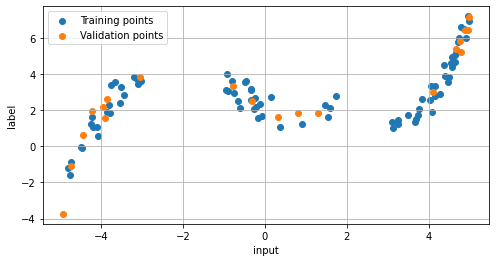

FOLD 2
Trail with dropout:0.48691691607791204, adam_lr:0.0038758182145124565, weight_decay:4.264365308303603e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.766403198242188
AVERAGE VAL LOSS: 2.4081037044525146
# EPOCH 2
AVERAGE TRAIN LOSS: 3.146535873413086
AVERAGE VAL LOSS: 3.8783481121063232
# EPOCH 3
AVERAGE TRAIN LOSS: 4.295901298522949
AVERAGE VAL LOSS: 3.1580371856689453
# EPOCH 4
AVERAGE TRAIN LOSS: 3.3502347469329834
AVERAGE VAL LOSS: 2.2288105487823486
# EPOCH 5
AVERAGE TRAIN LOSS: 2.60573148727417
AVERAGE VAL LOSS: 2.250990629196167
# EPOCH 6
AVERAGE TRAIN LOSS: 3.0124034881591797
AVERAGE VAL LOSS: 2.288637638092041
# EPOCH 7
AVERAGE TRAIN LOSS: 2.627685785293579
AVERAGE VAL LOSS: 2.501756429672241
# EPOCH 8
AVERAGE TRAIN LOSS: 2.6639482975006104
AVERAGE VAL LOSS: 2.2899577617645264
# EPOCH 9
AVERAGE TRAIN LOSS: 2.444179058074951
AVERAGE VAL LOSS: 1.918788194656372
# EPOCH 10
AVERAGE TRAIN LOSS: 2.3527674674987793
AVERAGE VAL LOSS: 1.9460890293121338
# EPOCH 11
AVERAGE TRAIN LOSS: 1.9581

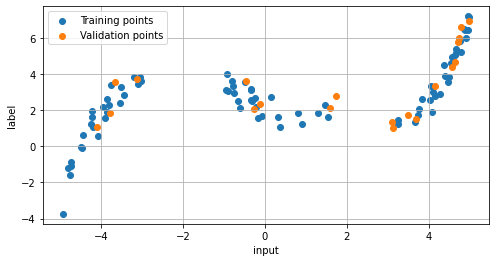

FOLD 3
Trail with dropout:0.48691691607791204, adam_lr:0.0038758182145124565, weight_decay:4.264365308303603e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.989980697631836
AVERAGE VAL LOSS: 6.026608943939209
# EPOCH 2
AVERAGE TRAIN LOSS: 3.9139316082000732
AVERAGE VAL LOSS: 5.088710308074951
# EPOCH 3
AVERAGE TRAIN LOSS: 4.83681583404541
AVERAGE VAL LOSS: 3.598949909210205
# EPOCH 4
AVERAGE TRAIN LOSS: 3.7875075340270996
AVERAGE VAL LOSS: 3.008587121963501
# EPOCH 5
AVERAGE TRAIN LOSS: 3.426860809326172
AVERAGE VAL LOSS: 2.8666722774505615
# EPOCH 6
AVERAGE TRAIN LOSS: 3.098219871520996
AVERAGE VAL LOSS: 3.1164023876190186
# EPOCH 7
AVERAGE TRAIN LOSS: 2.664595127105713
AVERAGE VAL LOSS: 3.461345672607422
# EPOCH 8
AVERAGE TRAIN LOSS: 3.0689218044281006
AVERAGE VAL LOSS: 3.1091349124908447
# EPOCH 9
AVERAGE TRAIN LOSS: 2.5261313915252686
AVERAGE VAL LOSS: 2.380086898803711
# EPOCH 10
AVERAGE TRAIN LOSS: 2.373122215270996
AVERAGE VAL LOSS: 2.0158145427703857
# EPOCH 11
AVERAGE TRAIN LOSS: 2.412070

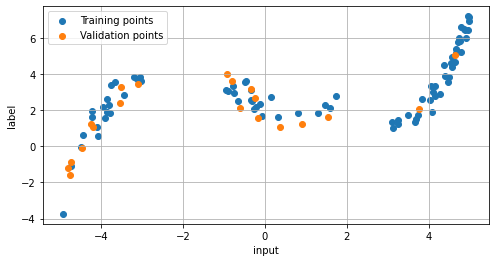

FOLD 4
Trail with dropout:0.48691691607791204, adam_lr:0.0038758182145124565, weight_decay:4.264365308303603e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 7.204231262207031
AVERAGE VAL LOSS: 2.3619706630706787
# EPOCH 2
AVERAGE TRAIN LOSS: 4.872071266174316
AVERAGE VAL LOSS: 5.134589672088623
# EPOCH 3
AVERAGE TRAIN LOSS: 4.025859355926514
AVERAGE VAL LOSS: 3.286003828048706
# EPOCH 4
AVERAGE TRAIN LOSS: 3.522965908050537
AVERAGE VAL LOSS: 2.9804294109344482
# EPOCH 5
AVERAGE TRAIN LOSS: 3.6702609062194824
AVERAGE VAL LOSS: 2.887753486633301
# EPOCH 6
AVERAGE TRAIN LOSS: 2.9705114364624023
AVERAGE VAL LOSS: 2.316133499145508
# EPOCH 7
AVERAGE TRAIN LOSS: 3.1680209636688232
AVERAGE VAL LOSS: 2.0962913036346436
# EPOCH 8
AVERAGE TRAIN LOSS: 3.4296789169311523
AVERAGE VAL LOSS: 2.2007369995117188
# EPOCH 9
AVERAGE TRAIN LOSS: 2.55487322807312
AVERAGE VAL LOSS: 2.1483891010284424
# EPOCH 10
AVERAGE TRAIN LOSS: 2.5668115615844727
AVERAGE VAL LOSS: 2.0510976314544678
# EPOCH 11
AVERAGE TRAIN LOSS: 2.329

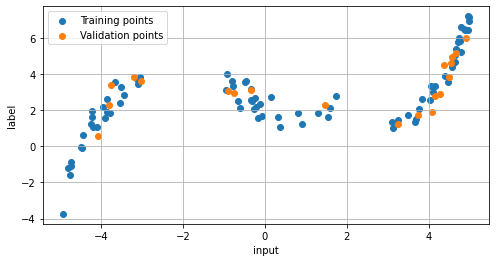

FOLD 5
Trail with dropout:0.48691691607791204, adam_lr:0.0038758182145124565, weight_decay:4.264365308303603e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.36595630645752
AVERAGE VAL LOSS: 2.753667116165161
# EPOCH 2
AVERAGE TRAIN LOSS: 4.564581394195557
AVERAGE VAL LOSS: 4.575852870941162
# EPOCH 3
AVERAGE TRAIN LOSS: 5.211801528930664
AVERAGE VAL LOSS: 3.445863723754883
# EPOCH 4
AVERAGE TRAIN LOSS: 3.6646018028259277
AVERAGE VAL LOSS: 2.551938056945801
# EPOCH 5
AVERAGE TRAIN LOSS: 3.265381336212158
AVERAGE VAL LOSS: 2.0532710552215576
# EPOCH 6
AVERAGE TRAIN LOSS: 2.7168562412261963
AVERAGE VAL LOSS: 1.932413935661316
# EPOCH 7
AVERAGE TRAIN LOSS: 3.3895556926727295
AVERAGE VAL LOSS: 1.8208051919937134
# EPOCH 8
AVERAGE TRAIN LOSS: 3.256869316101074
AVERAGE VAL LOSS: 1.6225708723068237
# EPOCH 9
AVERAGE TRAIN LOSS: 3.2330431938171387
AVERAGE VAL LOSS: 1.678629755973816
# EPOCH 10
AVERAGE TRAIN LOSS: 2.8552603721618652
AVERAGE VAL LOSS: 1.8016365766525269
# EPOCH 11
AVERAGE TRAIN LOSS: 2.4182

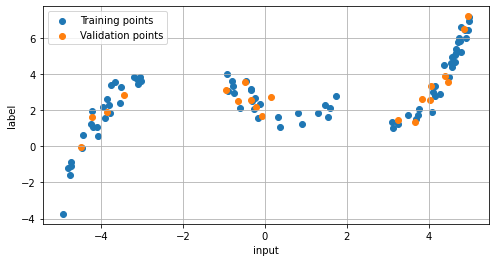

[I 2021-12-31 15:46:53,503] Trial 6 pruned. 


FOLD 1
Trail with dropout:0.010251667507518616, adam_lr:0.002666011313828695, weight_decay:2.73988853925064e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 7.381099700927734
AVERAGE VAL LOSS: 8.045443534851074
# EPOCH 2
AVERAGE TRAIN LOSS: 4.167032241821289
AVERAGE VAL LOSS: 5.118791103363037
# EPOCH 3
AVERAGE TRAIN LOSS: 4.252385139465332
AVERAGE VAL LOSS: 3.181180953979492
# EPOCH 4
AVERAGE TRAIN LOSS: 3.5382204055786133
AVERAGE VAL LOSS: 2.9467532634735107
# EPOCH 5
AVERAGE TRAIN LOSS: 2.9996018409729004
AVERAGE VAL LOSS: 3.609787702560425
# EPOCH 6
AVERAGE TRAIN LOSS: 2.7895617485046387
AVERAGE VAL LOSS: 4.471538543701172
# EPOCH 7
AVERAGE TRAIN LOSS: 2.603989601135254
AVERAGE VAL LOSS: 4.764033794403076
# EPOCH 8
AVERAGE TRAIN LOSS: 2.615722179412842
AVERAGE VAL LOSS: 4.754533290863037
# EPOCH 9
AVERAGE TRAIN LOSS: 2.3271563053131104
AVERAGE VAL LOSS: 3.9926822185516357
# EPOCH 10
AVERAGE TRAIN LOSS: 2.118100166320801
AVERAGE VAL LOSS: 3.06256365776062
# EPOCH 11
AVERAGE TRAIN LOSS: 1.951067328

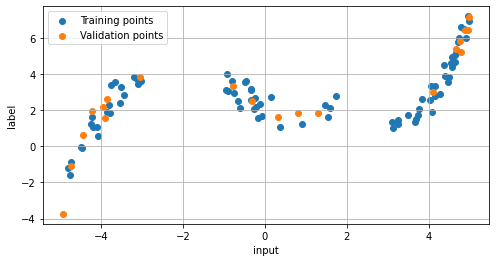

FOLD 2
Trail with dropout:0.010251667507518616, adam_lr:0.002666011313828695, weight_decay:2.73988853925064e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.641395568847656
AVERAGE VAL LOSS: 3.279423475265503
# EPOCH 2
AVERAGE TRAIN LOSS: 3.9458932876586914
AVERAGE VAL LOSS: 2.767270803451538
# EPOCH 3
AVERAGE TRAIN LOSS: 3.9263696670532227
AVERAGE VAL LOSS: 4.123351573944092
# EPOCH 4
AVERAGE TRAIN LOSS: 4.097618579864502
AVERAGE VAL LOSS: 3.489556074142456
# EPOCH 5
AVERAGE TRAIN LOSS: 3.236306667327881
AVERAGE VAL LOSS: 2.509690523147583
# EPOCH 6
AVERAGE TRAIN LOSS: 2.60239839553833
AVERAGE VAL LOSS: 2.30257248878479
# EPOCH 7
AVERAGE TRAIN LOSS: 2.757713794708252
AVERAGE VAL LOSS: 2.3981404304504395
# EPOCH 8
AVERAGE TRAIN LOSS: 2.783017635345459
AVERAGE VAL LOSS: 2.520883083343506
# EPOCH 9
AVERAGE TRAIN LOSS: 2.392756700515747
AVERAGE VAL LOSS: 2.3577592372894287
# EPOCH 10
AVERAGE TRAIN LOSS: 2.1420562267303467
AVERAGE VAL LOSS: 2.1748921871185303
# EPOCH 11
AVERAGE TRAIN LOSS: 1.9911246299

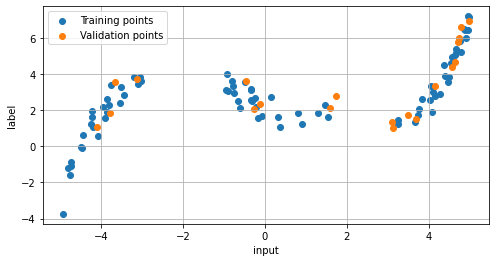

FOLD 3
Trail with dropout:0.010251667507518616, adam_lr:0.002666011313828695, weight_decay:2.73988853925064e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.274206161499023
AVERAGE VAL LOSS: 5.058497905731201
# EPOCH 2
AVERAGE TRAIN LOSS: 3.312870502471924
AVERAGE VAL LOSS: 4.81567907333374
# EPOCH 3
AVERAGE TRAIN LOSS: 3.9064111709594727
AVERAGE VAL LOSS: 3.6760120391845703
# EPOCH 4
AVERAGE TRAIN LOSS: 3.2221527099609375
AVERAGE VAL LOSS: 2.887556791305542
# EPOCH 5
AVERAGE TRAIN LOSS: 2.602543592453003
AVERAGE VAL LOSS: 2.62378191947937
# EPOCH 6
AVERAGE TRAIN LOSS: 2.603163480758667
AVERAGE VAL LOSS: 2.9512317180633545
# EPOCH 7
AVERAGE TRAIN LOSS: 2.572364568710327
AVERAGE VAL LOSS: 3.173701047897339
# EPOCH 8
AVERAGE TRAIN LOSS: 2.4333183765411377
AVERAGE VAL LOSS: 2.5394561290740967
# EPOCH 9
AVERAGE TRAIN LOSS: 2.097926616668701
AVERAGE VAL LOSS: 2.095552682876587
# EPOCH 10
AVERAGE TRAIN LOSS: 2.094674587249756
AVERAGE VAL LOSS: 1.8725881576538086
# EPOCH 11
AVERAGE TRAIN LOSS: 1.982264757

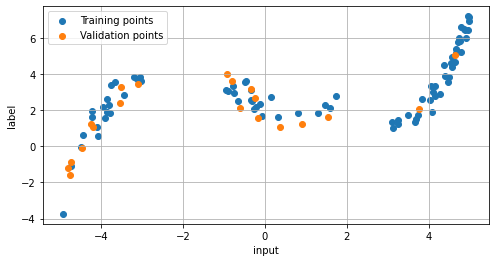

FOLD 4
Trail with dropout:0.010251667507518616, adam_lr:0.002666011313828695, weight_decay:2.73988853925064e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.719976425170898
AVERAGE VAL LOSS: 2.157163381576538
# EPOCH 2
AVERAGE TRAIN LOSS: 3.337428331375122
AVERAGE VAL LOSS: 4.081407070159912
# EPOCH 3
AVERAGE TRAIN LOSS: 3.8566622734069824
AVERAGE VAL LOSS: 6.053060054779053
# EPOCH 4
AVERAGE TRAIN LOSS: 3.7071523666381836
AVERAGE VAL LOSS: 4.242924690246582
# EPOCH 5
AVERAGE TRAIN LOSS: 2.7797534465789795
AVERAGE VAL LOSS: 2.3594446182250977
# EPOCH 6
AVERAGE TRAIN LOSS: 2.4580867290496826
AVERAGE VAL LOSS: 1.8797248601913452
# EPOCH 7
AVERAGE TRAIN LOSS: 2.494354724884033
AVERAGE VAL LOSS: 1.7505050897598267
# EPOCH 8
AVERAGE TRAIN LOSS: 2.477769374847412
AVERAGE VAL LOSS: 1.7601349353790283
# EPOCH 9
AVERAGE TRAIN LOSS: 2.1841282844543457
AVERAGE VAL LOSS: 2.0549604892730713
# EPOCH 10
AVERAGE TRAIN LOSS: 2.0422282218933105
AVERAGE VAL LOSS: 2.1882896423339844
# EPOCH 11
AVERAGE TRAIN LOSS: 1.89

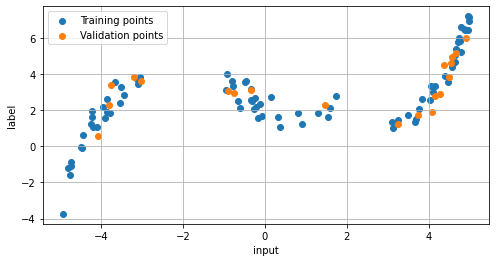

FOLD 5
Trail with dropout:0.010251667507518616, adam_lr:0.002666011313828695, weight_decay:2.73988853925064e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.565511703491211
AVERAGE VAL LOSS: 2.7456777095794678
# EPOCH 2
AVERAGE TRAIN LOSS: 3.5966200828552246
AVERAGE VAL LOSS: 3.7127740383148193
# EPOCH 3
AVERAGE TRAIN LOSS: 3.9377102851867676
AVERAGE VAL LOSS: 3.716313123703003
# EPOCH 4
AVERAGE TRAIN LOSS: 3.5584402084350586
AVERAGE VAL LOSS: 2.607887029647827
# EPOCH 5
AVERAGE TRAIN LOSS: 2.8547182083129883
AVERAGE VAL LOSS: 2.0249860286712646
# EPOCH 6
AVERAGE TRAIN LOSS: 2.685800552368164
AVERAGE VAL LOSS: 1.892860770225525
# EPOCH 7
AVERAGE TRAIN LOSS: 2.7750093936920166
AVERAGE VAL LOSS: 1.7436045408248901
# EPOCH 8
AVERAGE TRAIN LOSS: 2.6291818618774414
AVERAGE VAL LOSS: 1.5846929550170898
# EPOCH 9
AVERAGE TRAIN LOSS: 2.2869443893432617
AVERAGE VAL LOSS: 1.6832789182662964
# EPOCH 10
AVERAGE TRAIN LOSS: 2.1561999320983887
AVERAGE VAL LOSS: 1.8277634382247925
# EPOCH 11
AVERAGE TRAIN LOSS: 2

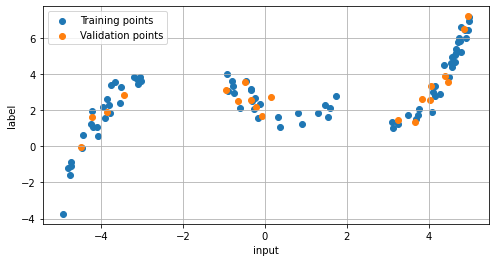

[I 2021-12-31 15:50:56,693] Trial 7 finished with value: 0.12146443128585815 and parameters: {'n_units_l0': 207, 'n_units_l1': 128, 'dropout': 0.010251667507518616, 'lr': 0.002666011313828695, 'weight_decay': 2.73988853925064e-05}. Best is trial 0 with value: 0.07817257195711136.


FOLD 1
Trail with dropout:0.2458287613515885, adam_lr:0.0054956988653972125, weight_decay:9.239041744876257e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 7.207403182983398
AVERAGE VAL LOSS: 4.7414469718933105
# EPOCH 2
AVERAGE TRAIN LOSS: 3.6435742378234863
AVERAGE VAL LOSS: 3.065552234649658
# EPOCH 3
AVERAGE TRAIN LOSS: 3.3233625888824463
AVERAGE VAL LOSS: 3.2974777221679688
# EPOCH 4
AVERAGE TRAIN LOSS: 2.2751047611236572
AVERAGE VAL LOSS: 4.1472978591918945
# EPOCH 5
AVERAGE TRAIN LOSS: 2.304126262664795
AVERAGE VAL LOSS: 4.443953990936279
# EPOCH 6
AVERAGE TRAIN LOSS: 2.2177681922912598
AVERAGE VAL LOSS: 3.963243246078491
# EPOCH 7
AVERAGE TRAIN LOSS: 2.208794116973877
AVERAGE VAL LOSS: 2.785914421081543
# EPOCH 8
AVERAGE TRAIN LOSS: 1.7044965028762817
AVERAGE VAL LOSS: 2.41829776763916
# EPOCH 9
AVERAGE TRAIN LOSS: 1.8551404476165771
AVERAGE VAL LOSS: 2.6893866062164307
# EPOCH 10
AVERAGE TRAIN LOSS: 1.6477851867675781
AVERAGE VAL LOSS: 3.1348416805267334
# EPOCH 11
AVERAGE TRAIN LOSS: 1.840

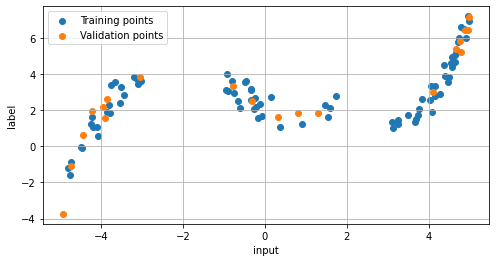

FOLD 2
Trail with dropout:0.2458287613515885, adam_lr:0.0054956988653972125, weight_decay:9.239041744876257e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.328882217407227
AVERAGE VAL LOSS: 2.561697483062744
# EPOCH 2
AVERAGE TRAIN LOSS: 4.503103733062744
AVERAGE VAL LOSS: 4.179476261138916
# EPOCH 3
AVERAGE TRAIN LOSS: 5.04924201965332
AVERAGE VAL LOSS: 3.1821460723876953
# EPOCH 4
AVERAGE TRAIN LOSS: 3.295259952545166
AVERAGE VAL LOSS: 2.7650649547576904
# EPOCH 5
AVERAGE TRAIN LOSS: 3.2284047603607178
AVERAGE VAL LOSS: 3.1993017196655273
# EPOCH 6
AVERAGE TRAIN LOSS: 3.6111440658569336
AVERAGE VAL LOSS: 3.13135027885437
# EPOCH 7
AVERAGE TRAIN LOSS: 3.2144603729248047
AVERAGE VAL LOSS: 2.4724645614624023
# EPOCH 8
AVERAGE TRAIN LOSS: 2.9482603073120117
AVERAGE VAL LOSS: 2.080768346786499
# EPOCH 9
AVERAGE TRAIN LOSS: 2.784198522567749
AVERAGE VAL LOSS: 2.1955573558807373
# EPOCH 10
AVERAGE TRAIN LOSS: 2.583189010620117
AVERAGE VAL LOSS: 2.0441129207611084
# EPOCH 11
AVERAGE TRAIN LOSS: 2.24859

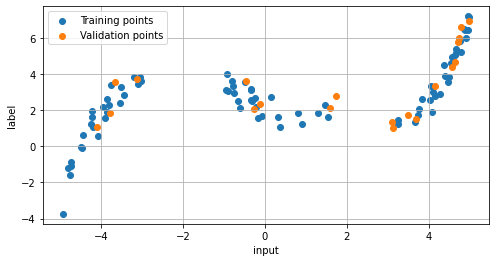

FOLD 3
Trail with dropout:0.2458287613515885, adam_lr:0.0054956988653972125, weight_decay:9.239041744876257e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.892330169677734
AVERAGE VAL LOSS: 5.774081707000732
# EPOCH 2
AVERAGE TRAIN LOSS: 5.426164627075195
AVERAGE VAL LOSS: 3.832688093185425
# EPOCH 3
AVERAGE TRAIN LOSS: 4.44461727142334
AVERAGE VAL LOSS: 3.153498649597168
# EPOCH 4
AVERAGE TRAIN LOSS: 2.864564895629883
AVERAGE VAL LOSS: 3.2984626293182373
# EPOCH 5
AVERAGE TRAIN LOSS: 2.841935157775879
AVERAGE VAL LOSS: 3.3481318950653076
# EPOCH 6
AVERAGE TRAIN LOSS: 3.2510266304016113
AVERAGE VAL LOSS: 2.8178844451904297
# EPOCH 7
AVERAGE TRAIN LOSS: 2.7265586853027344
AVERAGE VAL LOSS: 2.388381242752075
# EPOCH 8
AVERAGE TRAIN LOSS: 2.446603298187256
AVERAGE VAL LOSS: 2.060642957687378
# EPOCH 9
AVERAGE TRAIN LOSS: 2.298571825027466
AVERAGE VAL LOSS: 1.8636797666549683
# EPOCH 10
AVERAGE TRAIN LOSS: 2.236246347427368
AVERAGE VAL LOSS: 1.7227849960327148
# EPOCH 11
AVERAGE TRAIN LOSS: 2.06955575

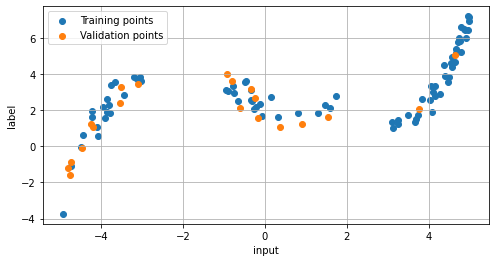

FOLD 4
Trail with dropout:0.2458287613515885, adam_lr:0.0054956988653972125, weight_decay:9.239041744876257e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.587441444396973
AVERAGE VAL LOSS: 1.9407997131347656
# EPOCH 2
AVERAGE TRAIN LOSS: 4.805551052093506
AVERAGE VAL LOSS: 5.31112003326416
# EPOCH 3
AVERAGE TRAIN LOSS: 5.02308464050293
AVERAGE VAL LOSS: 4.870900630950928
# EPOCH 4
AVERAGE TRAIN LOSS: 3.4623255729675293
AVERAGE VAL LOSS: 3.8079986572265625
# EPOCH 5
AVERAGE TRAIN LOSS: 3.339287042617798
AVERAGE VAL LOSS: 3.5273964405059814
# EPOCH 6
AVERAGE TRAIN LOSS: 3.398782968521118
AVERAGE VAL LOSS: 3.0603151321411133
# EPOCH 7
AVERAGE TRAIN LOSS: 3.3513965606689453
AVERAGE VAL LOSS: 2.125770330429077
# EPOCH 8
AVERAGE TRAIN LOSS: 2.7688405513763428
AVERAGE VAL LOSS: 1.920344591140747
# EPOCH 9
AVERAGE TRAIN LOSS: 2.817495107650757
AVERAGE VAL LOSS: 2.249523162841797
# EPOCH 10
AVERAGE TRAIN LOSS: 2.6215803623199463
AVERAGE VAL LOSS: 2.188833713531494
# EPOCH 11
AVERAGE TRAIN LOSS: 2.19653701

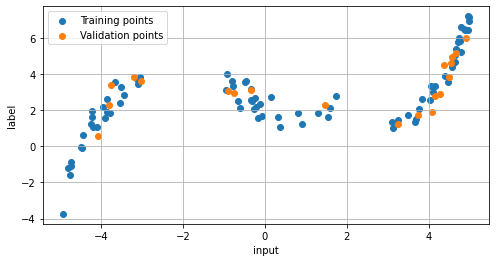

FOLD 5
Trail with dropout:0.2458287613515885, adam_lr:0.0054956988653972125, weight_decay:9.239041744876257e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 9.0422945022583
AVERAGE VAL LOSS: 2.797642230987549
# EPOCH 2
AVERAGE TRAIN LOSS: 4.621586799621582
AVERAGE VAL LOSS: 4.622537612915039
# EPOCH 3
AVERAGE TRAIN LOSS: 4.118391036987305
AVERAGE VAL LOSS: 2.450922966003418
# EPOCH 4
AVERAGE TRAIN LOSS: 2.8026838302612305
AVERAGE VAL LOSS: 2.225736379623413
# EPOCH 5
AVERAGE TRAIN LOSS: 3.720733165740967
AVERAGE VAL LOSS: 2.2090988159179688
# EPOCH 6
AVERAGE TRAIN LOSS: 3.24501895904541
AVERAGE VAL LOSS: 1.791285753250122
# EPOCH 7
AVERAGE TRAIN LOSS: 3.0895543098449707
AVERAGE VAL LOSS: 1.8110418319702148
# EPOCH 8
AVERAGE TRAIN LOSS: 2.5952816009521484
AVERAGE VAL LOSS: 2.0589051246643066
# EPOCH 9
AVERAGE TRAIN LOSS: 2.5009148120880127
AVERAGE VAL LOSS: 1.6421867609024048
# EPOCH 10
AVERAGE TRAIN LOSS: 2.042292356491089
AVERAGE VAL LOSS: 1.348885416984558
# EPOCH 11
AVERAGE TRAIN LOSS: 2.317312002

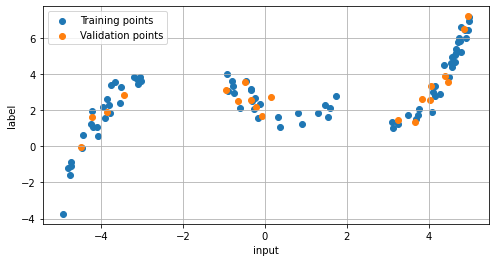

[I 2021-12-31 15:55:22,705] Trial 8 pruned. 


FOLD 1
Trail with dropout:0.06306609202885848, adam_lr:0.0012699405774835811, weight_decay:7.069224839832325e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 10.230918884277344
AVERAGE VAL LOSS: 9.830700874328613
# EPOCH 2
AVERAGE TRAIN LOSS: 5.135941028594971
AVERAGE VAL LOSS: 6.765270233154297
# EPOCH 3
AVERAGE TRAIN LOSS: 3.346928596496582
AVERAGE VAL LOSS: 5.280364036560059
# EPOCH 4
AVERAGE TRAIN LOSS: 3.0387003421783447
AVERAGE VAL LOSS: 4.3473639488220215
# EPOCH 5
AVERAGE TRAIN LOSS: 3.252255916595459
AVERAGE VAL LOSS: 3.5133843421936035
# EPOCH 6
AVERAGE TRAIN LOSS: 3.2225046157836914
AVERAGE VAL LOSS: 2.9974751472473145
# EPOCH 7
AVERAGE TRAIN LOSS: 2.870511054992676
AVERAGE VAL LOSS: 2.839078187942505
# EPOCH 8
AVERAGE TRAIN LOSS: 2.625549793243408
AVERAGE VAL LOSS: 2.945645809173584
# EPOCH 9
AVERAGE TRAIN LOSS: 2.4040801525115967
AVERAGE VAL LOSS: 3.323267698287964
# EPOCH 10
AVERAGE TRAIN LOSS: 2.1613636016845703
AVERAGE VAL LOSS: 3.767866849899292
# EPOCH 11
AVERAGE TRAIN LOSS: 2.22567

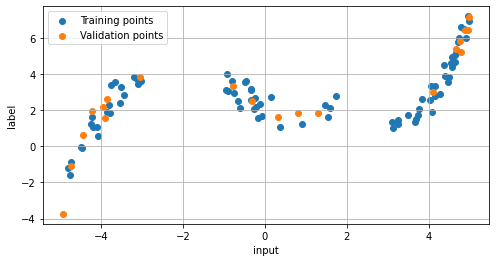

FOLD 2
Trail with dropout:0.06306609202885848, adam_lr:0.0012699405774835811, weight_decay:7.069224839832325e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 13.317867279052734
AVERAGE VAL LOSS: 11.190261840820312
# EPOCH 2
AVERAGE TRAIN LOSS: 8.163858413696289
AVERAGE VAL LOSS: 6.423989772796631
# EPOCH 3
AVERAGE TRAIN LOSS: 5.399024486541748
AVERAGE VAL LOSS: 3.7168586254119873
# EPOCH 4
AVERAGE TRAIN LOSS: 3.832953929901123
AVERAGE VAL LOSS: 2.4179770946502686
# EPOCH 5
AVERAGE TRAIN LOSS: 2.9705100059509277
AVERAGE VAL LOSS: 2.420696258544922
# EPOCH 6
AVERAGE TRAIN LOSS: 2.957070827484131
AVERAGE VAL LOSS: 3.0117080211639404
# EPOCH 7
AVERAGE TRAIN LOSS: 3.256978988647461
AVERAGE VAL LOSS: 3.3206307888031006
# EPOCH 8
AVERAGE TRAIN LOSS: 3.194322109222412
AVERAGE VAL LOSS: 3.1370270252227783
# EPOCH 9
AVERAGE TRAIN LOSS: 3.05922269821167
AVERAGE VAL LOSS: 2.676412582397461
# EPOCH 10
AVERAGE TRAIN LOSS: 2.6819324493408203
AVERAGE VAL LOSS: 2.2728352546691895
# EPOCH 11
AVERAGE TRAIN LOSS: 2.4036

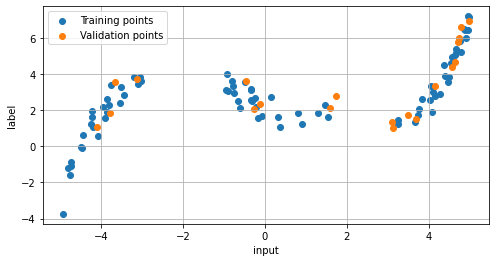

FOLD 3
Trail with dropout:0.06306609202885848, adam_lr:0.0012699405774835811, weight_decay:7.069224839832325e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 11.697867393493652
AVERAGE VAL LOSS: 4.781358242034912
# EPOCH 2
AVERAGE TRAIN LOSS: 5.970883369445801
AVERAGE VAL LOSS: 5.805267810821533
# EPOCH 3
AVERAGE TRAIN LOSS: 3.546830654144287
AVERAGE VAL LOSS: 5.733719348907471
# EPOCH 4
AVERAGE TRAIN LOSS: 2.945106029510498
AVERAGE VAL LOSS: 5.036235809326172
# EPOCH 5
AVERAGE TRAIN LOSS: 3.4321494102478027
AVERAGE VAL LOSS: 4.000017166137695
# EPOCH 6
AVERAGE TRAIN LOSS: 3.551727771759033
AVERAGE VAL LOSS: 3.4166431427001953
# EPOCH 7
AVERAGE TRAIN LOSS: 3.3605713844299316
AVERAGE VAL LOSS: 3.0603249073028564
# EPOCH 8
AVERAGE TRAIN LOSS: 2.849818229675293
AVERAGE VAL LOSS: 2.907654285430908
# EPOCH 9
AVERAGE TRAIN LOSS: 2.466505527496338
AVERAGE VAL LOSS: 3.0321319103240967
# EPOCH 10
AVERAGE TRAIN LOSS: 2.4852936267852783
AVERAGE VAL LOSS: 3.2698419094085693
# EPOCH 11
AVERAGE TRAIN LOSS: 2.36562

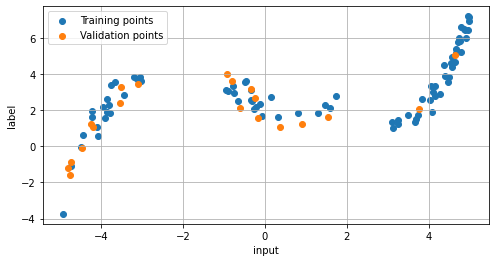

FOLD 4
Trail with dropout:0.06306609202885848, adam_lr:0.0012699405774835811, weight_decay:7.069224839832325e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 8.10161018371582
AVERAGE VAL LOSS: 3.335979461669922
# EPOCH 2
AVERAGE TRAIN LOSS: 4.346353530883789
AVERAGE VAL LOSS: 2.085777759552002
# EPOCH 3
AVERAGE TRAIN LOSS: 3.4706127643585205
AVERAGE VAL LOSS: 3.8761203289031982
# EPOCH 4
AVERAGE TRAIN LOSS: 3.317889928817749
AVERAGE VAL LOSS: 5.014904975891113
# EPOCH 5
AVERAGE TRAIN LOSS: 3.5329248905181885
AVERAGE VAL LOSS: 4.742467403411865
# EPOCH 6
AVERAGE TRAIN LOSS: 3.1717212200164795
AVERAGE VAL LOSS: 3.7012741565704346
# EPOCH 7
AVERAGE TRAIN LOSS: 2.775994300842285
AVERAGE VAL LOSS: 2.7424213886260986
# EPOCH 8
AVERAGE TRAIN LOSS: 2.585442543029785
AVERAGE VAL LOSS: 2.150576591491699
# EPOCH 9
AVERAGE TRAIN LOSS: 2.4943690299987793
AVERAGE VAL LOSS: 1.9332010746002197
# EPOCH 10
AVERAGE TRAIN LOSS: 2.505770683288574
AVERAGE VAL LOSS: 1.8465689420700073
# EPOCH 11
AVERAGE TRAIN LOSS: 2.40028

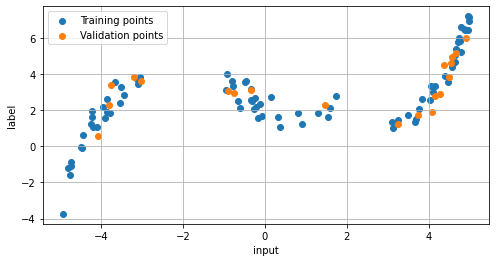

FOLD 5
Trail with dropout:0.06306609202885848, adam_lr:0.0012699405774835811, weight_decay:7.069224839832325e-05
# EPOCH 1
AVERAGE TRAIN LOSS: 11.31895637512207
AVERAGE VAL LOSS: 5.356882572174072
# EPOCH 2
AVERAGE TRAIN LOSS: 5.835771083831787
AVERAGE VAL LOSS: 2.891461133956909
# EPOCH 3
AVERAGE TRAIN LOSS: 3.7750439643859863
AVERAGE VAL LOSS: 2.507136106491089
# EPOCH 4
AVERAGE TRAIN LOSS: 3.377561330795288
AVERAGE VAL LOSS: 3.1079957485198975
# EPOCH 5
AVERAGE TRAIN LOSS: 3.4811034202575684
AVERAGE VAL LOSS: 3.487180471420288
# EPOCH 6
AVERAGE TRAIN LOSS: 3.7006402015686035
AVERAGE VAL LOSS: 3.412651538848877
# EPOCH 7
AVERAGE TRAIN LOSS: 3.4324324131011963
AVERAGE VAL LOSS: 2.9691684246063232
# EPOCH 8
AVERAGE TRAIN LOSS: 3.08561635017395
AVERAGE VAL LOSS: 2.4396393299102783
# EPOCH 9
AVERAGE TRAIN LOSS: 2.5982017517089844
AVERAGE VAL LOSS: 2.046330213546753
# EPOCH 10
AVERAGE TRAIN LOSS: 2.562408447265625
AVERAGE VAL LOSS: 1.8336495161056519
# EPOCH 11
AVERAGE TRAIN LOSS: 2.44065

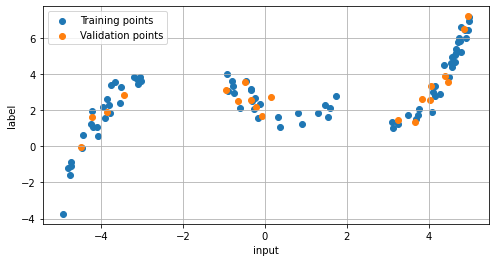

[I 2021-12-31 16:00:49,524] Trial 9 pruned. 


Study statistics: 
  Number of finished trials:  10
  Number of pruned trials:  4
  Number of complete trials:  6
Number of finished trials: 10
Best trial:
  Value: 0.07817257195711136
  Params: 
    n_units_l0: 50
    n_units_l1: 118
    dropout: 0.13403055965755864
    lr: 0.0054427931347575
    weight_decay: 1.5029275758738817e-05


In [ ]:
import optuna
import torch.nn.functional as F
from optuna.integration import PyTorchLightningPruningCallback
from sklearn.model_selection import KFold
from optuna.trial import TrialState

def objective(trial, train_dataloader, val_dataloader):

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    output_dims = [trial.suggest_int("n_units_l{}".format(i), 50, 300, log=True) for i in range(2)]
    dropout = trial.suggest_float('dropout', 0.01, 0.5) 

    model = Net(Ni, output_dims[0], output_dims[1], No, dropout=dropout).to(device)

    # Define the loss function
    loss_fn =  nn.MSELoss()
    # Define the optimizer
    lr = trial.suggest_float('lr', 1e-5, 1e-2) 
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-4) 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    print(f'Trail with dropout:{dropout}, adam_lr:{lr}, weight_decay:{weight_decay}')

    num_epochs = 100
    for epoch_num in range(num_epochs):
      print(f'# EPOCH {epoch_num+1}')

      train_loss_batches = train_epoch(model, device, train_dataloader, loss_fn, optimizer)
      train_loss = np.mean(train_loss_batches)   # average over the loss_batches --> #batches losses
      print(f"AVERAGE TRAIN LOSS: {train_loss}")

      val_loss_batches = val_epoch(model, device, val_dataloader, loss_fn)
      val_loss = np.mean(val_loss_batches)
      print(f"AVERAGE VAL LOSS: {val_loss}")

    Gen_error = np.abs(val_loss-train_loss)
    return Gen_error

def objective_cv(trial):

    fold = KFold(n_splits=5, shuffle=True, random_state=0) #provides train/test indices to split data in train/val sets
    gen_errors = []
    k = 0
    for fold_idx, (train_idx, val_idx) in enumerate(fold.split(range(len(train_dataset)))):
        train_data = torch.utils.data.Subset(train_dataset, train_idx)
        x_train = [train_data[i][0] for i in range(len(train_data))]   
        y_train = [train_data[i][1] for i in range(len(train_data))] 
        val_data = torch.utils.data.Subset(train_dataset, val_idx)
        x_val = [val_data[i][0] for i in range(len(val_data))]   
        y_val = [val_data[i][1] for i in range(len(val_data))] 

        train_dataloader = DataLoader(train_data, batch_size=int(len(train_data)/2), shuffle=True, num_workers=2)
        val_dataloader = DataLoader(val_data, batch_size=len(val_data), shuffle=False, num_workers=2)

        k += 1
        print(f'FOLD {k}')
        gen_error = objective(trial, train_dataloader, val_dataloader)
        gen_errors.append(gen_error)

        #Plot Train-Val points
        fig = plt.figure(figsize=(8,4))
        plt.scatter(x_train, y_train, label='Training points')
        plt.scatter(x_val, y_val, label='Validation points')
        plt.xlabel('input')
        plt.ylabel('label')
        plt.legend()
        plt.grid()
        plt.show()

    mean_gen_error = np.mean(gen_errors)
    trial.report(mean_gen_error, k)
  # Handle pruning based on the intermediate value.
    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_gen_error

# Study initialization
# direction = 'minimize' : since the goal is to minimize the Generalized error
# sampler = 'TPEsampler' : default paramter for single-objective optimization
# pruner = 'MedianPruner' : default paramter for pruning useless configurations

#study = optuna.create_study(study_name="myfirstoptimizationstudy", direction="minimize", pruner=pruner)
study = optuna.create_study(study_name="Regression", direction="minimize")

# Opimization
# Recevies the function to be optimized and the number of trials
study.optimize(objective_cv, n_trials=10)
pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

print("Study statistics: ")
print("  Number of finished trials: ", len(study.trials))
print("  Number of pruned trials: ", len(pruned_trials))
print("  Number of complete trials: ", len(complete_trials))

print("Number of finished trials: {}".format(len(study.trials)))

print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))
    

#At the end it will tell us the best set of parameters after n_trails

In [ ]:
torch.save(study.get_trials(), 'optuna_trials.torch')

### Analyze the trials

In [ ]:
complete_trials = study.get_trials()
for i in range(10):
  print(complete_trials[i].params)
  print(complete_trials[i].values[0])

{'n_units_l0': 50, 'n_units_l1': 118, 'dropout': 0.13403055965755864, 'lr': 0.0054427931347575, 'weight_decay': 1.5029275758738817e-05}
0.07817257195711136
{'n_units_l0': 248, 'n_units_l1': 135, 'dropout': 0.2299860127874589, 'lr': 0.004965222074369671, 'weight_decay': 5.53928543130121e-05}
0.1938641369342804
{'n_units_l0': 57, 'n_units_l1': 292, 'dropout': 0.0841429068235593, 'lr': 0.006601055029315029, 'weight_decay': 5.0570278512699826e-05}
0.10564915835857391
{'n_units_l0': 289, 'n_units_l1': 99, 'dropout': 0.21755906897029054, 'lr': 0.007835439192829717, 'weight_decay': 8.150828165753842e-05}
0.3272657096385956
{'n_units_l0': 69, 'n_units_l1': 264, 'dropout': 0.0231830376279673, 'lr': 0.002229585169001085, 'weight_decay': 2.1313202178234238e-05}
0.13104791939258575
{'n_units_l0': 183, 'n_units_l1': 184, 'dropout': 0.2606847549036372, 'lr': 0.007538643716065459, 'weight_decay': 4.7696192203271005e-05}
0.14605095982551575
{'n_units_l0': 167, 'n_units_l1': 135, 'dropout': 0.486916916

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
labels = []
for i in range(10):
    labels.append(f'Trail {i+1}')

fig = make_subplots(rows=3, cols=2, subplot_titles=("Val loss", "Nh1", "dropout", "Nh2", "weight decay", "lr"))
fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].values[0] for i in range(10)],
          text=["%.3f" % complete_trials[i].values[0] for i in range(10)],
          textposition='auto',
      ), 1,1)

fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['dropout'] for i in range(10)],
          text=["%.3f" % complete_trials[i].params['dropout'] for i in range(10)],
          textposition='auto',
      ), 2,1)

fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['weight_decay'] for i in range(10)],
          text=["%.1e" % complete_trials[i].params['weight_decay'] for i in range(10)],
          textposition='auto',
      ), 3,1)


fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['lr'] for i in range(10)],
          text=["%.1e" % complete_trials[i].params['lr'] for i in range(10)],
          textposition='auto',
      ), 3, 2)


fig.add_trace(go.Bar(
                        x=labels, 
                        y=[complete_trials[i].params['n_units_l0'] for i in range(10)],
                        text=[ complete_trials[i].params['n_units_l0'] for i in range(10)],
                        textposition='auto',
      ), 1, 2)


fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['n_units_l1'] for i in range(10)],
          text=[complete_trials[i].params['n_units_l1'] for i in range(10)],
          textposition='auto',

      ), 2, 2)
fig.show()

### Best Model with the whole Training Dataset

In [ ]:
#BEST MODEL
### Set the random seed for reproducible results
torch.manual_seed(0)

Ni = 1
#Nh1 = study.best_trial.params['n_units_l0']
#Nh2 = study.best_trial.params['n_units_l1']
Nh1 = 50
Nh2 = 118
No = 1
dropout = 0.13403055965755864
lr = 0.0054427931347575
weight_decay = 1.5029275758738817e-05
#dropout = study.best_trial.params['dropout']
best_model = Net(Ni, Nh1, Nh2, No, dropout)
best_model.to(device)


Net(
  (ffnn): Sequential(
    (0): Linear(in_features=1, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=50, out_features=118, bias=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.13403055965755864, inplace=False)
    (5): Linear(in_features=118, out_features=1, bias=True)
  )
)

In [ ]:
torch.manual_seed(0)
#Nh1 = 93
#Nh2 = 226
#dropout = 0.37279488517750775
best_model = Net(Ni, Nh1, Nh2, No, dropout)
best_model.to(device)

#lr = 0.0054200264604371585
#weight_decay = 2.6356391101190953e-05
# Define the loss function
loss_fn =  nn.MSELoss() 
# Define the optimizer
#weight_decay = study.best_trial.params['weight_decay']
#lr = study.best_trial.params['lr']
optimizer = torch.optim.Adam(best_model.parameters(), lr=lr, weight_decay=weight_decay)

In [ ]:
### TRAINING LOOP
test_dataloader = DataLoader(test_dataset, batch_size=int(len(test_dataset)/2), shuffle=False, num_workers=2)
train_dataloader = DataLoader(train_dataset, batch_size=int(len(train_dataset)/2), shuffle=True, num_workers=2)
num_epochs = 500     #1epoch=1iter over your data
train_loss_log, test_loss_log = [], []
for epoch_num in range(num_epochs):
    print(f'# EPOCH {epoch_num+1}')

    train_loss_batches = train_epoch(best_model, device, train_dataloader, loss_fn, optimizer)
    train_loss = np.mean(train_loss_batches)   # average over the loss_batches --> #batches losses
    print(f"AVERAGE TRAIN LOSS: {train_loss}")
    train_loss_log.append(train_loss)

    test_loss_batches = val_epoch(best_model, device, test_dataloader, loss_fn)
    test_loss = np.mean(test_loss_batches)
    print(f"AVERAGE VAL LOSS: {test_loss}")
    test_loss_log.append(test_loss)

# EPOCH 1
AVERAGE TRAIN LOSS: 14.922441482543945
AVERAGE VAL LOSS: 6.44156551361084
# EPOCH 2
AVERAGE TRAIN LOSS: 6.7259039878845215
AVERAGE VAL LOSS: 4.324763774871826
# EPOCH 3
AVERAGE TRAIN LOSS: 3.7506322860717773
AVERAGE VAL LOSS: 3.7650957107543945
# EPOCH 4
AVERAGE TRAIN LOSS: 3.164727210998535
AVERAGE VAL LOSS: 4.208542823791504
# EPOCH 5
AVERAGE TRAIN LOSS: 3.841325283050537
AVERAGE VAL LOSS: 4.3798828125
# EPOCH 6
AVERAGE TRAIN LOSS: 3.7751717567443848
AVERAGE VAL LOSS: 4.084587097167969
# EPOCH 7
AVERAGE TRAIN LOSS: 3.353954315185547
AVERAGE VAL LOSS: 3.6615805625915527
# EPOCH 8
AVERAGE TRAIN LOSS: 2.832947254180908
AVERAGE VAL LOSS: 3.30783748626709
# EPOCH 9
AVERAGE TRAIN LOSS: 2.6270644664764404
AVERAGE VAL LOSS: 3.090062141418457
# EPOCH 10
AVERAGE TRAIN LOSS: 2.5285391807556152
AVERAGE VAL LOSS: 2.9589896202087402
# EPOCH 11
AVERAGE TRAIN LOSS: 2.671494960784912
AVERAGE VAL LOSS: 2.8265411853790283
# EPOCH 12
AVERAGE TRAIN LOSS: 2.660125255584717
AVERAGE VAL LOSS: 2.64

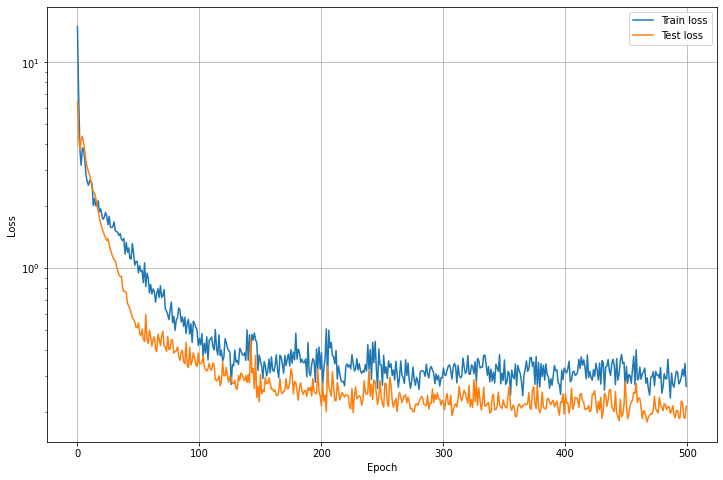

In [ ]:
# Plot losses
plt.figure(figsize=(12,8))
plt.semilogy(train_loss_log, label='Train loss')
plt.semilogy(test_loss_log, label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()

## Simple FF network with NO Regularization

In [ ]:
# Initialize the network
### Set the random seed for reproducible results
torch.manual_seed(0)

not_Reg = Net(Ni, Nh1, Nh2, No)
not_Reg.to(device)


Net(
  (ffnn): Sequential(
    (0): Linear(in_features=1, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=50, out_features=118, bias=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0, inplace=False)
    (5): Linear(in_features=118, out_features=1, bias=True)
  )
)

In [ ]:
# Define the loss function
loss_fn =  nn.MSELoss() 
# Define the optimizer
lr = 1e-3
weight_decay=0
optimizer = torch.optim.Adam(not_Reg.parameters(), lr=lr, weight_decay=weight_decay) 

In [ ]:
### TRAINING LOOP
num_epochs = 500    #1epoch=1iter over your data
train_loss_NOREG = []
val_loss_NOREG = []
for epoch_num in range(num_epochs):
    print('#################')
    print(f'# EPOCH {epoch_num}')
    print('#################')

    train_loss_batches = train_epoch(not_Reg, device, train_dataloader, loss_fn, optimizer)
    train_loss = np.mean(train_loss_batches)   # average over the loss_batches --> #batches losses
    print(f"AVERAGE TRAIN LOSS: {train_loss}")
    train_loss_NOREG.append(train_loss)

    val_loss_batches = val_epoch(not_Reg, device, test_dataloader, loss_fn)
    val_loss = np.mean(val_loss_batches)
    print(f"AVERAGE test LOSS: {val_loss}")
    val_loss_NOREG.append(val_loss)




#################
# EPOCH 0
#################
AVERAGE TRAIN LOSS: 16.775707244873047
AVERAGE test LOSS: 11.234375
#################
# EPOCH 1
#################
AVERAGE TRAIN LOSS: 14.488419532775879
AVERAGE test LOSS: 9.822782516479492
#################
# EPOCH 2
#################
AVERAGE TRAIN LOSS: 12.571212768554688
AVERAGE test LOSS: 8.629781723022461
#################
# EPOCH 3
#################
AVERAGE TRAIN LOSS: 10.81013298034668
AVERAGE test LOSS: 7.6286516189575195
#################
# EPOCH 4
#################
AVERAGE TRAIN LOSS: 9.427632331848145
AVERAGE test LOSS: 6.790525436401367
#################
# EPOCH 5
#################
AVERAGE TRAIN LOSS: 8.142791748046875
AVERAGE test LOSS: 6.115311145782471
#################
# EPOCH 6
#################
AVERAGE TRAIN LOSS: 7.096648216247559
AVERAGE test LOSS: 5.575155735015869
#################
# EPOCH 7
#################
AVERAGE TRAIN LOSS: 6.279325485229492
AVERAGE test LOSS: 5.1188554763793945
#################
# EPOCH 8
#######

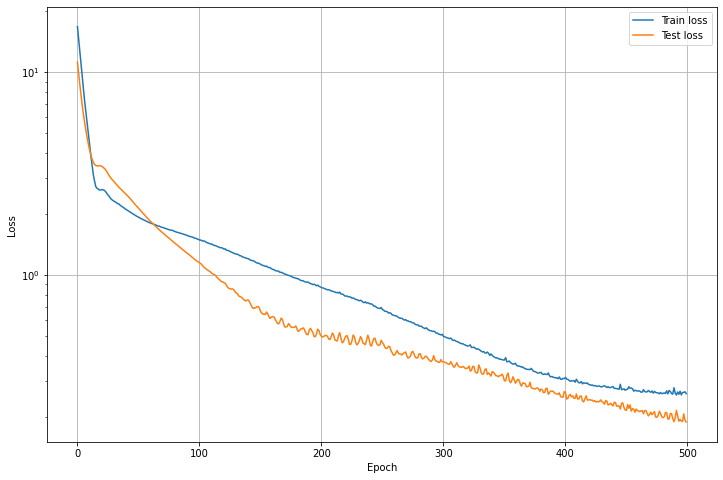

In [ ]:
# Plot losses
plt.figure(figsize=(12,8))
plt.semilogy(train_loss_NOREG, label='Train loss')
plt.semilogy(val_loss_NOREG, label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()

### Comparison best model - NOT Regularized model

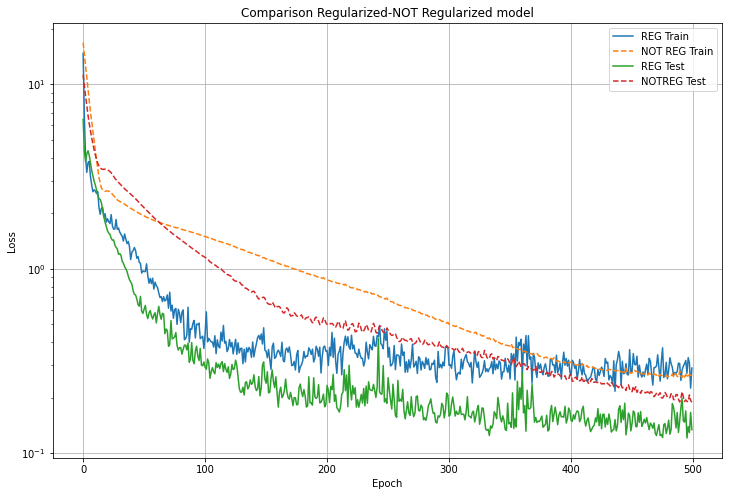

In [ ]:
# Plot losses
plt.figure(figsize=(12,8))
plt.title('Comparison Regularized-NOT Regularized model')
plt.semilogy(train_loss_log, label='REG Train')
plt.semilogy(train_loss_NOREG, label='NOT REG Train', linestyle='--')
plt.semilogy(test_loss_log, label='REG Test')
plt.semilogy(val_loss_NOREG, label='NOTREG Test', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.show()

### Save the network parameters & the optimizer state
Also the optimizer has its internal state!

You need to save both the network and the optimizer states if you want to continue your training.

If you are sure you have finished your training you can just save the network.

In [ ]:
# Save network parameters
torch.save(best_model.state_dict(), 'R_params.torch')

In [ ]:
Ni = 1
Nh1 = study.best_trial.params['n_units_l0']
Nh2 = study.best_trial.params['n_units_l1']
No = 1
dropout = study.best_trial.params['dropout']
best_model = Net(Ni, Nh1, Nh2, No, dropout)
best_model.to(device)
# Load the state dict previously saved
net_state_dict = torch.load('R_params.torch', map_location=torch.device('cpu'))
# Update the network parameters
best_model.load_state_dict(net_state_dict)

<All keys matched successfully>

### Plot

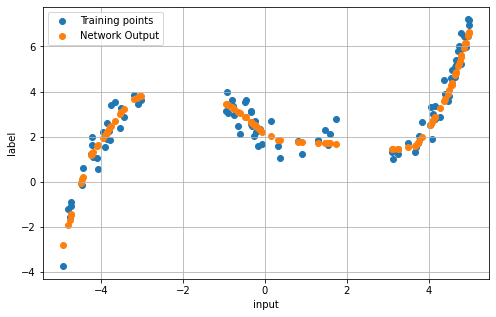

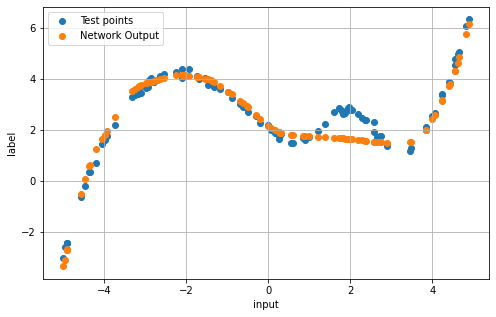

In [ ]:
train_dataset = CsvDataset('regression_dataset/train_data.csv', transform=composed_transform)
test_dataset = CsvDataset('regression_dataset/test_data.csv', transform=composed_transform)

best_model.eval() # Evaluation mode (e.g. disable dropout, batchnorm,...)--> the parameter are frozen since we are only making the Testing
with torch.no_grad(): # Disable gradient tracking since we don't want to update the net during Testing
    y_train, y_test = [], []
    for sample_train in train_dataset:
      # Move data to device
        x_train = sample_train[0].to(device)
      # Encode data
        out_train = best_model(x_train)
        y_train.append(out_train.detach().cpu().numpy())

    for sample_test in test_dataset:
      # Move data to device
        x_test = sample_test[0].to(device)
      # Encode data
        out_test = best_model(x_test)
        y_test.append(out_test.detach().cpu().numpy())

fig = plt.figure(figsize=(8,5))
plt.scatter(train_df.input, train_df.label, label='Training points')
plt.scatter(train_df.input, y_train, label='Network Output')
plt.xlabel('input')
plt.ylabel('label')
plt.legend()
plt.grid()
plt.show()

fig = plt.figure(figsize=(8,5))
plt.scatter(test_df.input, test_df.label, label='Test points')
plt.scatter(test_df.input, y_test, label='Network Output')
plt.xlabel('input')
plt.ylabel('label')
plt.legend()
plt.grid()
plt.show()

Not regularized model

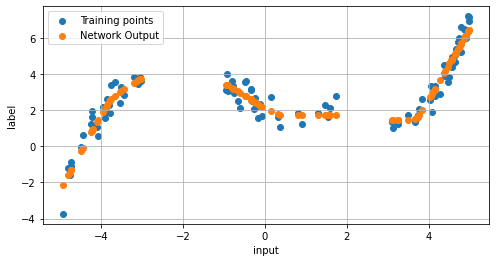

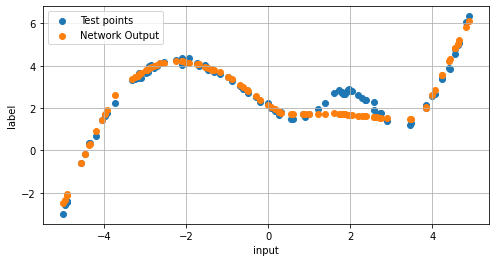

In [ ]:
not_Reg.eval() # Evaluation mode (e.g. disable dropout, batchnorm,...)--> the parameter are frozen since we are only making the Testing
with torch.no_grad(): # Disable gradient tracking since we don't want to update the net during Testing
    y_train, y_test = [], []
    for sample_train in train_dataset:
      # Move data to device
        x_train = sample_train[0].to(device)
      # Encode data
        out_train = not_Reg(x_train)
        y_train.append(out_train.detach().cpu().numpy())

    for sample_test in test_dataset:
      # Move data to device
        x_test = sample_test[0].to(device)
      # Encode data
        out_test = not_Reg(x_test)
        y_test.append(out_test.detach().cpu().numpy())

fig = plt.figure(figsize=(8,4))
plt.scatter(train_df.input, train_df.label, label='Training points')
plt.scatter(train_df.input, y_train, label='Network Output')
plt.xlabel('input')
plt.ylabel('label')
plt.legend()
plt.grid()
plt.show()

fig = plt.figure(figsize=(8,4))
plt.scatter(test_df.input, test_df.label, label='Test points')
plt.scatter(test_df.input, y_test, label='Network Output')
plt.xlabel('input')
plt.ylabel('label')
plt.legend()
plt.grid()
plt.show()

## Access network parameters

In [ ]:
#Comparison between weights of the not trained net & of the trained net
not_trained = Net(Ni, Nh1, Nh2, No, dropout).to(device)
print(not_trained)
trained = best_model
net = trained
#net = not_Reg
# First hidden layer
h1_w = net.ffnn[0].weight.data.cpu().numpy()   #weights of the layer fc1
h1_b = net.ffnn[0].bias.data.cpu().numpy()

# Second hidden layer
h2_w = net.ffnn[2].weight.data.cpu().numpy()
h2_b = net.ffnn[2].bias.data.cpu().numpy()

# Output layer
out_w = net.ffnn[5].weight.data.cpu().numpy()
out_b = net.ffnn[5].bias.data.cpu().numpy()

Net(
  (ffnn): Sequential(
    (0): Linear(in_features=1, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=50, out_features=118, bias=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.13403055965755864, inplace=False)
    (5): Linear(in_features=118, out_features=1, bias=True)
  )
)


## Weights histogram

Compare the histogram before and after the training

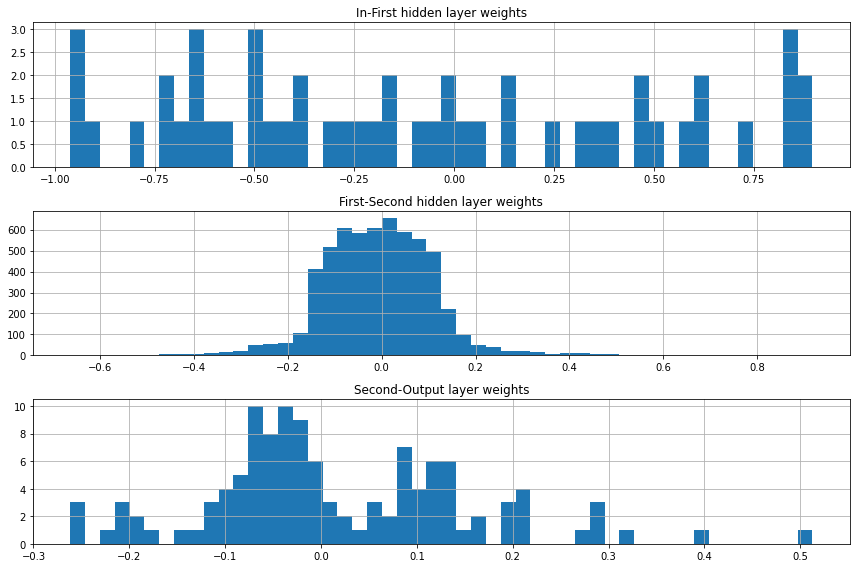

In [ ]:
# Weights histogram
fig, axs = plt.subplots(3, 1, figsize=(12,8))
axs[0].hist(h1_w.flatten(), 50)
axs[0].set_title('In-First hidden layer weights')
axs[1].hist(h2_w.flatten(), 50)
axs[1].set_title('First-Second hidden layer weights')
axs[2].hist(out_w.flatten(), 50)
axs[2].set_title('Second-Output layer weights')
[ax.grid() for ax in axs]
plt.tight_layout()
plt.show()
#we can identify some clusters (before the training was all random)--> Analyze the weights to design a proper regularization for ex
#to understand if we are learning something

## Analyze activations

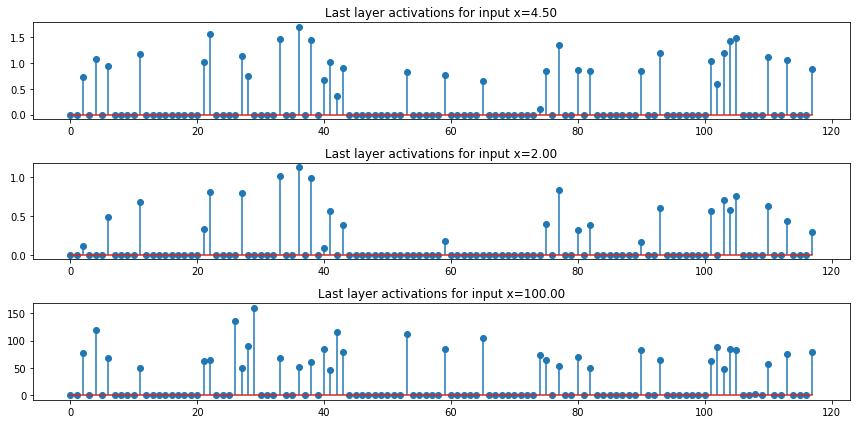

In [ ]:
# First naive way: simply change the network definition to return an additional output

# More advanced strategy: using hooks

def get_activation(layer, input, output):
    global activation
    activation = torch.relu(output)

### Register hook  
hook_handle = net.ffnn[4].register_forward_hook(get_activation)

### Analyze activations
net = net.to(device)
net.eval()
with torch.no_grad():
    x1 = torch.tensor([4.5]).float().to(device)
    y1 = net(x1)
    z1 = activation   #activation of the second hidden layer
    x2 = torch.tensor([2]).float().to(device)
    y2 = net(x2)
    z2 = activation
    x3 = torch.tensor([100]).float().to(device)
    y3 = net(x3)
    z3 = activation

### Remove hook
hook_handle.remove()

### Plot activations
fig, axs = plt.subplots(3, 1, figsize=(12,6))
axs[0].stem(z1.cpu().numpy(), use_line_collection=True)
axs[0].set_title('Last layer activations for input x=%.2f' % x1)
axs[1].stem(z2.cpu().numpy(), use_line_collection=True)
axs[1].set_title('Last layer activations for input x=%.2f' % x2)
axs[2].stem(z3.cpu().numpy(), use_line_collection=True)
axs[2].set_title('Last layer activations for input x=%.2f' % x3)
plt.tight_layout()
plt.show()
#Training in [0,1]
#x=0.1 & x=0.9--> sparse activation
#x=2.5 more confused activation --> more uncertain activation (not 0 or 1 but middle values)
#you want to minimize the entropy

# Trying other optimizers

In [ ]:
test_dataloader = DataLoader(test_dataset, batch_size=int(len(test_dataset)/2), shuffle=False, num_workers=2)
train_dataloader = DataLoader(train_dataset, batch_size=int(len(train_dataset)/2), shuffle=True, num_workers=2)
for i in range(2):

    torch.manual_seed(0)

    #Ni = 1
    #No = 1
    #Nh1 = 93
    #Nh2 = 226
    #dropout = 0.37279488517750775
    #lr = 0.0054200264604371585
    #weight_decay = 2.6356391101190953e-05
    dropout = study.best_trial.params['dropout']
    model_SGD = Net(Ni, Nh1, Nh2, No, dropout)
    model_SGD.to(device)
    # Define the loss function
    loss_fn =  nn.MSELoss() 
    # Define the optimizer
    weight_decay = study.best_trial.params['weight_decay']
    lr = study.best_trial.params['lr']
    if i == 0:
      optimizerSGD = torch.optim.SGD(model_SGD.parameters(), lr=lr, weight_decay=weight_decay, momentum=0)
      train_loss_SGD, test_loss_SGD = [], []

    else :
      optimizerSGD = torch.optim.SGD(model_SGD.parameters(), lr=lr, weight_decay=weight_decay, momentum=0.9)
      train_loss_SGDMom, test_loss_SGDMom = [], []
    
    for epoch_num in range(num_epochs):
      print(f'# EPOCH {epoch_num+1}')

      train_loss_batches = train_epoch(model_SGD, device, train_dataloader, loss_fn, optimizerSGD)
      train_loss = np.mean(train_loss_batches)   # average over the loss_batches --> #batches losses
      print(f"AVERAGE TRAIN LOSS: {train_loss}")
      

      test_loss_batches = val_epoch(model_SGD, device, test_dataloader, loss_fn)
      test_loss = np.mean(test_loss_batches)
      print(f"AVERAGE TEST LOSS: {test_loss}")
      
      if i==0:
        train_loss_SGD.append(train_loss)
        test_loss_SGD.append(test_loss)
      else:
        train_loss_SGDMom.append(train_loss)
        test_loss_SGDMom.append(test_loss)

# EPOCH 1
AVERAGE TRAIN LOSS: 12.448979377746582
AVERAGE TEST LOSS: 4.83458137512207
# EPOCH 2
AVERAGE TRAIN LOSS: 3.7938766479492188
AVERAGE TEST LOSS: 4.007283687591553
# EPOCH 3
AVERAGE TRAIN LOSS: 3.1095855236053467
AVERAGE TEST LOSS: 3.9165802001953125
# EPOCH 4
AVERAGE TRAIN LOSS: 2.908095359802246
AVERAGE TEST LOSS: 3.855544090270996
# EPOCH 5
AVERAGE TRAIN LOSS: 3.0067572593688965
AVERAGE TEST LOSS: 3.7941503524780273
# EPOCH 6
AVERAGE TRAIN LOSS: 3.0906805992126465
AVERAGE TEST LOSS: 3.7453694343566895
# EPOCH 7
AVERAGE TRAIN LOSS: 2.873004198074341
AVERAGE TEST LOSS: 3.7115793228149414
# EPOCH 8
AVERAGE TRAIN LOSS: 2.896949291229248
AVERAGE TEST LOSS: 3.6502444744110107
# EPOCH 9
AVERAGE TRAIN LOSS: 2.9024460315704346
AVERAGE TEST LOSS: 3.6084673404693604
# EPOCH 10
AVERAGE TRAIN LOSS: 2.917353630065918
AVERAGE TEST LOSS: 3.574024200439453
# EPOCH 11
AVERAGE TRAIN LOSS: 2.6672534942626953
AVERAGE TEST LOSS: 3.533412456512451
# EPOCH 12
AVERAGE TRAIN LOSS: 2.7202460765838623
A

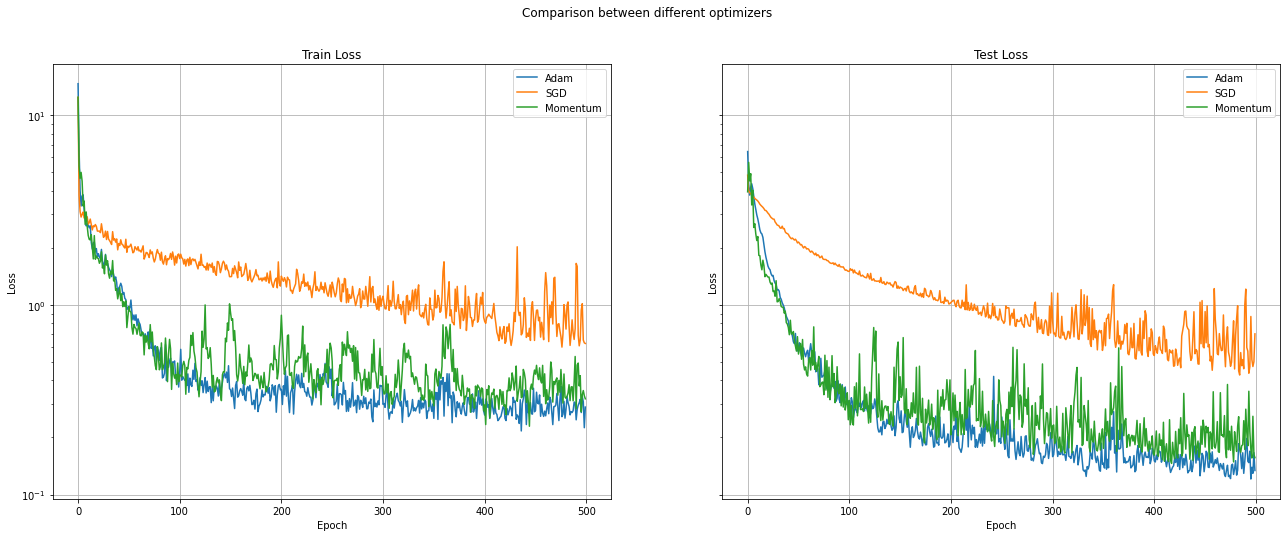

In [ ]:
# Plot losses
fig, (ax1, ax2) = plt.subplots(1,2, sharex=True, sharey=True, figsize=(22, 8))
#fig.figure(figsize=(12,8))
fig.suptitle('Comparison between different optimizers')
ax1.set_title('Train Loss')
ax1.semilogy(train_loss_log, label='Adam')
ax1.semilogy(train_loss_SGD, label='SGD')
ax1.semilogy(train_loss_SGDMom, label='Momentum')
ax1.set(xlabel='Epoch', ylabel='Loss')
ax1.grid()
ax1.legend()

#ax2.figure(figsize=(8,4))
ax2.set_title('Test Loss')
ax2.semilogy(test_loss_log, label='Adam')
ax2.semilogy(test_loss_SGD, label='SGD')
ax2.semilogy(test_loss_SGDMom, label='Momentum')
ax2.set(xlabel='Epoch', ylabel='Loss')
ax2.grid()
ax2.legend()
fig.show()

# Add another hidden layer to improve the performance

In [ ]:
class Net3(nn.Module):
    
    def __init__(self, Ni, Nh1, Nh2, Nh3, No, dropout=0):   #2 hidden layer
        """
        Ni - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        No - Output size
        """
        super().__init__()                        # super() calls the parent class nn.Module
        
        self.ffnn = nn.Sequential(
                    # First linear layer
                    nn.Linear(in_features=Ni, out_features=Nh1),
                    nn.ReLU(True),
                    # Second linear layer
                    nn.Linear(in_features=Nh1, out_features=Nh2),
                    nn.ReLU(True),
                    nn.Dropout(dropout),
                    # third linear layer
                    nn.Linear(in_features=Nh2, out_features=Nh3),
                    nn.ReLU(True),
                    #Output layer
                    nn.Linear(in_features=Nh3, out_features=No)
        )

        
    def forward(self, x, additional_out=False):  # Forward pass of the network, from the input x to the output. 
                            
        x = self.ffnn(x)
        return x

In [ ]:
#BEST MODEL
### Set the random seed for reproducible results
torch.manual_seed(0)

Ni = 1
#Nh1 = study.best_trial.params['n_units_l0']
#Nh2 = study.best_trial.params['n_units_l1']
Nh3 = 170
No = 1
#dropout = study.best_trial.params['dropout']
model3 = Net3(Ni, Nh1, Nh2, Nh3, No, dropout)
model3.to(device)


Net3(
  (ffnn): Sequential(
    (0): Linear(in_features=1, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=50, out_features=118, bias=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.13403055965755864, inplace=False)
    (5): Linear(in_features=118, out_features=170, bias=True)
    (6): ReLU(inplace=True)
    (7): Linear(in_features=170, out_features=1, bias=True)
  )
)

In [ ]:
# Define the loss function
loss_fn =  nn.MSELoss() 
# Define the optimizer
#weight_decay = study.best_trial.params['weight_decay']
#lr = study.best_trial.params['lr']
optimizer = torch.optim.Adam(model3.parameters(), lr=lr, weight_decay=weight_decay)

In [ ]:
### TRAINING LOOP
train_dataloader = DataLoader(train_dataset, batch_size=int(len(train_dataset)/2), shuffle=True, num_workers=2)
num_epochs = 500     #1epoch=1iter over your data
train_loss_3, test_loss_3 = [], []
for epoch_num in range(num_epochs):
    print(f'# EPOCH {epoch_num+1}')

    train_loss_batches = train_epoch(model3, device, train_dataloader, loss_fn, optimizer)
    train_loss = np.mean(train_loss_batches)   # average over the loss_batches --> #batches losses
    print(f"AVERAGE TRAIN LOSS: {train_loss}")
    train_loss_3.append(train_loss)

    test_loss_batches = val_epoch(model3, device, test_dataloader, loss_fn)
    test_loss = np.mean(test_loss_batches)
    print(f"AVERAGE VAL LOSS: {test_loss}")
    test_loss_3.append(test_loss)

# EPOCH 1
AVERAGE TRAIN LOSS: 8.134942054748535
AVERAGE VAL LOSS: 4.0536651611328125
# EPOCH 2
AVERAGE TRAIN LOSS: 3.9189512729644775
AVERAGE VAL LOSS: 4.5060577392578125
# EPOCH 3
AVERAGE TRAIN LOSS: 3.5827460289001465
AVERAGE VAL LOSS: 3.88254451751709
# EPOCH 4
AVERAGE TRAIN LOSS: 2.6848959922790527
AVERAGE VAL LOSS: 3.418468952178955
# EPOCH 5
AVERAGE TRAIN LOSS: 2.8257672786712646
AVERAGE VAL LOSS: 2.7540788650512695
# EPOCH 6
AVERAGE TRAIN LOSS: 2.640394687652588
AVERAGE VAL LOSS: 2.4229023456573486
# EPOCH 7
AVERAGE TRAIN LOSS: 2.478166341781616
AVERAGE VAL LOSS: 2.3564658164978027
# EPOCH 8
AVERAGE TRAIN LOSS: 2.2416584491729736
AVERAGE VAL LOSS: 2.39957332611084
# EPOCH 9
AVERAGE TRAIN LOSS: 2.16279935836792
AVERAGE VAL LOSS: 1.8704023361206055
# EPOCH 10
AVERAGE TRAIN LOSS: 1.7915797233581543
AVERAGE VAL LOSS: 1.730659008026123
# EPOCH 11
AVERAGE TRAIN LOSS: 2.082357883453369
AVERAGE VAL LOSS: 1.6223273277282715
# EPOCH 12
AVERAGE TRAIN LOSS: 1.9043514728546143
AVERAGE VAL LO

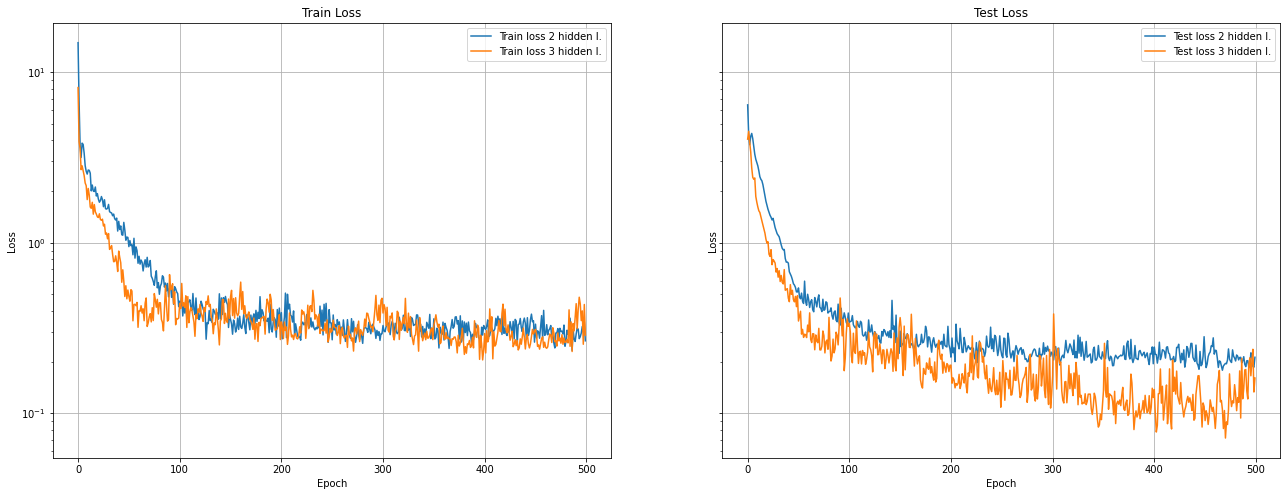

In [ ]:
# Plot losses
fig, (ax1, ax2) = plt.subplots(1,2, sharex=True, sharey=True, figsize=(22, 8))

ax1.set_title('Train Loss')
ax1.semilogy(train_loss_log, label='Train loss 2 hidden l.')
ax1.semilogy(train_loss_3, label='Train loss 3 hidden l.')
ax1.set(xlabel='Epoch', ylabel='Loss')
ax1.grid()
ax1.legend()

ax2.set_title('Test Loss')
ax2.semilogy(test_loss_log, label='Test loss 2 hidden l.')
ax2.semilogy(test_loss_3, label='Test loss 3 hidden l.')
ax2.set(xlabel='Epoch', ylabel='Loss')
ax2.grid()
ax2.legend()
fig.show()

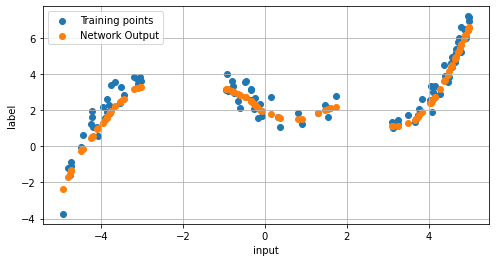

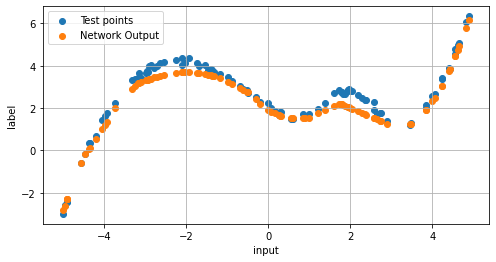

In [ ]:
model3.eval() # Evaluation mode (e.g. disable dropout, batchnorm,...)--> the parameter are frozen since we are only making the Testing
with torch.no_grad(): # Disable gradient tracking since we don't want to update the net during Testing
    y_train, y_test = [], []
    for sample_train in train_dataset:
      # Move data to device
        x_train = sample_train[0].to(device)
      # Encode data
        out_train = model3(x_train)
        y_train.append(out_train.detach().cpu().numpy())

    for sample_test in test_dataset:
      # Move data to device
        x_test = sample_test[0].to(device)
      # Encode data
        out_test = model3(x_test)
        y_test.append(out_test.detach().cpu().numpy())

fig = plt.figure(figsize=(8,4))
plt.scatter(train_df.input, train_df.label, label='Training points')
plt.scatter(train_df.input, y_train, label='Network Output')
plt.xlabel('input')
plt.ylabel('label')
plt.legend()
plt.grid()
plt.show()

fig = plt.figure(figsize=(8,4))
plt.scatter(test_df.input, test_df.label, label='Test points')
plt.scatter(test_df.input, y_test, label='Network Output')
plt.xlabel('input')
plt.ylabel('label')
plt.legend()
plt.grid()
plt.show()